# Network and rheological properties of nanomotif assemblies simulated with ReaDDy CG model

Rheological data extracted with graph-based interpretation of Rouse/Zimm model. Rouse interpretation as discussed in Alshareedah et al. Sequence-specific interactions determine viscoelasticity and ageing dynamics of protein condensates, 2024 and Cohen et al. Direct computations of viscoelastic moduli of biomolecular condensates, 2024


Update to include hydrodynamic interactions with Zimm interpretation

Update to include:

-better visualisation of overall G' and G'' shift under differernt connectivtiy

-test of graph based predictors for overall scaling of G' and G''

-test of graph based predictions for exp. data from Can et al Mechanically Tunable DNA Hydrogels as Prospective Biosensing Modules

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Import

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import readdy
import math
import scipy
import pandas as pd
import sklearn
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
import contextlib
import io
import pickle
import torch
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood
from botorch.acquisition import LogExpectedImprovement
from botorch.acquisition import ExpectedImprovement
from botorch.acquisition import UpperConfidenceBound
from botorch.optim import optimize_acqf
import multiprocessing

from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_percentage_error,mean_squared_log_error,mean_absolute_error
import threading
from concurrent.futures import ThreadPoolExecutor
from scipy.interpolate import interp1d

import sys
import os
import seaborn as sns
#sys.path.append(os.path.abspath(os.path.join('..', 'python_scripts')))

from NCG_readdy_sim_4 import Debye_length, Debye_Hueckel_pot_rep_strength ,Diff_at23C,visc_T,Diff_ES

from NCG_readdy_sim_4 import run_sim_3,tcl_file_gen_3,all_types

from NCG_Bay_opt_readdy_sim_3 import run_p,run_p_dict,gt_1_3,gt_1_1,gt_1_2,gt_1_4, cg_angle_distr_c1_4_ba_aa_oa_la,cg_angle_distr_c1_1_hp,cg_angle_distr_c1_1_bm, eval_sim_c1_1_la,eval_sim_c1_1_hp,eval_sim_c1_1_aa,eval_sim_c1_2_ba_oa, eval_sim_c1_4_ba_aa_oa_la,eval_sim_c1_1_bm,apply_gp, run_gp_11

from NCG_Bay_opt_readdy_sim_3 import gen_all_comb_from_list_of_lists_2

#from NCG_readdy_sim_eval_1 import get_particle_number_from_sims
#from NCG_readdy_sim_eval_3 import get_particle_number_from_sims2,avg_largest_component_size,find_intersection,shift_graphs,get_time_avg_storage_loss_mod_2, get_subgraph_eigenvalues, relax_times, storage_mod, loss_mod_deref,relaxation_mod,get_time_avg_storage_loss_mod_4,get_subgraph_eigenvalues,get_time_avg_storage_loss_mod

from NCG_readdy_sim_eval_4 import *
from NCG_theo_graphs_1 import *

# Load in example simulations

In [64]:

#load saved config
traj_mech=readdy.Trajectory("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_checkpoint_0/x_c_mech_opt_prod_0.h5")

times_mech,types_mech,ids_mech,part_positions_mech=traj_mech.read_observable_particles()
time_pt_mech, counts_pt_mech = traj_mech.read_observable_number_of_particles()
#part_pos_eq=part_positions

time_e_mech, energy_mech=traj_mech.read_observable_energy()

time_obs_top_mech,obs_top_mech=traj_mech.read_observable_topologies()

####################
####################
####################


#load saved config
traj_mech2=readdy.Trajectory("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_0/x_c_mech_opt_prod_cont_2_0.h5")

times_mech2,types_mech2,ids_mech2,part_positions_mech2=traj_mech2.read_observable_particles()
time_pt_mech2, counts_pt_mech2 = traj_mech2.read_observable_number_of_particles()
#part_pos_eq=part_positions

time_e_mech2, energy_mech2=traj_mech2.read_observable_energy()

time_obs_top_mech2,obs_top_mech2=traj_mech2.read_observable_topologies()


####################
####################
####################


#load saved config
traj_mech3=readdy.Trajectory("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_2/prod_checkpoint_0/x_c_mech_opt_prod_0.h5")

times_mech3,types_mech3,ids_mech3,part_positions_mech3=traj_mech3.read_observable_particles()
time_pt_mech3, counts_pt_mech3 = traj_mech3.read_observable_number_of_particles()
#part_pos_eq=part_positions

time_e_mech3, energy_mech3=traj_mech3.read_observable_energy()

time_obs_top_mech3,obs_top_mech3=traj_mech3.read_observable_topologies()

In [12]:
len(part_positions_mech2[:-10][5250::15])

50

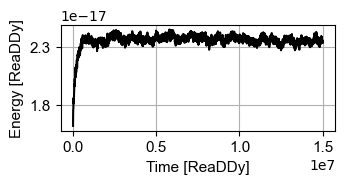

In [11]:
fig=plt.figure(figsize=(9/2.54,3.5/2.54))

plt.errorbar(time_e_mech3, energy_mech3,color="black")


plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks([1.8*10**-17,2.3*10**-17],fontname = "Arial",fontsize=11)
plt.ylabel("Energy [ReaDDy]",fontname = "Arial",fontsize=11)
plt.xlabel("Time [ReaDDy]",fontname = "Arial",fontsize=11)
plt.grid()

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/example_energy_100motifs_readdy_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [ ]:
#generate xyz file for visualisation
radii={}
for i in range(len(all_types)):
    radii[all_types[i]]=1.36

#traj_mech3.convert_to_xyz(particle_radii=radii)

In [ ]:
#save tcl file for visualisation
tcl_file_mech=tcl_file_gen_3(traj_file="x_c_mech_opt_prod_0.h5.xyz",box_dim_s="69.718 69.718 69.718")

#np.savetxt("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_0/tcl_x_c_mech_opt_prod_0.h5.tcl",tcl_file_mech,delimiter=" ", fmt="%s")

# Fraction of bound sticky ends 

In [7]:
# define which simulations to use 

# optimised, r_ub=0.05
#folder_name_ex1=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_8/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.02
folder_name_ex1=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_9/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.005
folder_name_ex2=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.0005
folder_name_ex3=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_4/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.0001
folder_name_ex4=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_6/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.00005
folder_name_ex5=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_7/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.000005
folder_name_ex6=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_5/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0 (part 1)
folder_name_ex7=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0 (part 2)
folder_name_ex8=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_checkpoint_"+str(e)+"/x_c_mech_opt_prod_cont_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0 (part 3)
folder_name_ex9=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_"+str(e)+"/x_c_mech_opt_prod_cont_2_"+str(e)+".h5" for e in [0,1,2,3,4]]

# soft, no angles between two arms optimised, r_ub=0 
folder_name_ex10=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]


#############
#############

#gather all simulation names in one list
folder_names_all_ex=[folder_name_ex1,folder_name_ex2,folder_name_ex3,folder_name_ex4,folder_name_ex5,folder_name_ex6,folder_name_ex7,folder_name_ex8,folder_name_ex9,folder_name_ex10]

In [32]:
%%time

#use parallel execution to calculate the fraction of bound sticky ends in all simulations

# List of input parameter tuples (names, [IDs of sticky end particles in ReaDDy])
inputs_part_num = [(folder_name_ex1, [31,33,35,37]), (folder_name_ex2, [31,33,35,37]), (folder_name_ex3, [31,33,35,37]), (folder_name_ex4, [31,33,35,37]), (folder_name_ex5, [31,33,35,37]),(folder_name_ex6, [31,33,35,37]),(folder_name_ex7, [31,33,35,37]),(folder_name_ex8, [31,33,35,37]),(folder_name_ex9, [31,33,35,37])]

# Run in parallel

with ThreadPoolExecutor(max_workers=12) as executor:
    results_part_num = list(executor.map(lambda args: get_particle_number_from_sims2(*args), inputs_part_num))



CPU times: user 16.9 s, sys: 21.3 s, total: 38.2 s
Wall time: 3min 1s


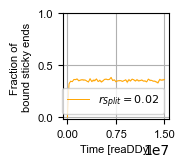

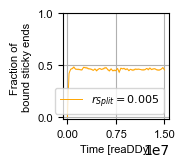

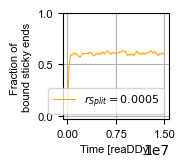

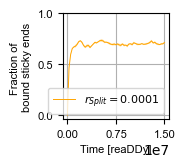

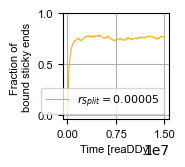

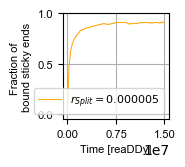

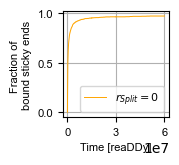

In [6]:
# plot fraction of bound sticky ends as function of time

#all simulations:
fused_linkers_ex_all=[results_part_num[e] for e in [0,1,2,3,4,5,6,7,8] ] #[fused_linkers_ex1,fused_linkers_ex2,fused_linkers_ex3,fused_linkers_ex4,fused_linkers_ex4]

rates_ub_ex_all=[r"$r_{Split}=0.02$",r"$r_{Split}=0.005$",r"$r_{Split}=0.0005$",r"$r_{Split}=0.0001$",r"$r_{Split}=0.00005$",r"$r_{Split}=0.000005$",r"$r_{Split}=0$"]


for i in range(len(fused_linkers_ex_all[:-2])):  
    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    #fig=plt.figure(figsize=(5,5))

    #simulations done in one run
    mean_fused_linkers=np.mean(fused_linkers_ex_all[i],axis=0)/400
    std_e_fused_linkers=np.std(fused_linkers_ex_all[i],axis=0)/(np.sqrt(fused_linkers_ex_all[i].shape[0])*400)
    
    plt.errorbar(time_pt_mech[::50],mean_fused_linkers[::50],label=rates_ub_ex_all[i],color="orange",linewidth=0.7)
    plt.fill_between(time_pt_mech[::50], mean_fused_linkers[::50] + std_e_fused_linkers[::50], mean_fused_linkers[::50] - std_e_fused_linkers[::50], alpha = 0.3 ,facecolor="orange")
    
     #piece together results from split simulation
    if i==6:
        #fused_linkers_ex1_cont=results_part_num[-3]
        #mean_fused_linkers_cont=np.mean(fused_linkers_ex1_cont,axis=0)/400
        #std_e_fused_linkers_cont=np.std(fused_linkers_ex1_cont,axis=0)/(np.sqrt(fused_linkers_ex_all[i].shape[0])*400)
        #plt.errorbar(time_pt_mech[::50],mean_fused_linkers_cont[::50],color="orange",linewidth=0.7)
        #plt.fill_between(time_pt_mech[::50], mean_fused_linkers_cont[::50] + std_e_fused_linkers_cont[::50], mean_fused_linkers_cont[::50] - std_e_fused_linkers_cont[::50], alpha = 0.3 ,facecolor="orange")

        #1st cont. of sim
        fused_linkers_ex1_cont=results_part_num[-2]
        mean_fused_linkers_cont=np.mean(fused_linkers_ex1_cont,axis=0)/400
        std_e_fused_linkers_cont=np.std(fused_linkers_ex1_cont,axis=0)/(np.sqrt(fused_linkers_ex_all[i].shape[0])*400)
        plt.errorbar(time_pt_mech[::50]+time_pt_mech[-1],mean_fused_linkers_cont[::50],color="orange",linewidth=0.7)
        plt.fill_between(time_pt_mech[::50]+time_pt_mech[-1], mean_fused_linkers_cont[::50] + std_e_fused_linkers_cont[::50], mean_fused_linkers_cont[::50] - std_e_fused_linkers_cont[::50], alpha = 0.3 ,facecolor="orange")

        #2nd cont. of sim
        fused_linkers_ex1_cont2=results_part_num[-1]
        mean_fused_linkers_cont2=np.mean(fused_linkers_ex1_cont2,axis=0)/400
        std_e_fused_linkers_cont2=np.std(fused_linkers_ex1_cont2,axis=0)/(np.sqrt(fused_linkers_ex_all[i].shape[0])*400)
        plt.errorbar(time_pt_mech2[::50]+time_pt_mech[-1]*2,mean_fused_linkers_cont2[::50],color="orange",linewidth=0.7)
        plt.fill_between(time_pt_mech2[::50]+time_pt_mech[-1]*2, mean_fused_linkers_cont2[::50] + std_e_fused_linkers_cont2[::50], mean_fused_linkers_cont2[::50] - std_e_fused_linkers_cont2[::50], alpha = 0.3 ,facecolor="orange")
  
        
        fs1=8
        plt.xticks([0,3*10**7,6*10**7],fontname = "Arial",fontsize=fs1)
        plt.yticks([0,0.5,1],fontname = "Arial",fontsize=fs1)
    
    else:
        fs1=8
        plt.xticks([0,0.75*10**7,1.5*10**7],fontname = "Arial",fontsize=fs1)
        plt.yticks([0,0.5,1],fontname = "Arial",fontsize=fs1)
    plt.ylabel("Fraction of \nbound sticky ends",fontname = "Arial",fontsize=fs1)
    plt.xlabel("Time [ReaDDy]",fontname = "Arial",fontsize=fs1)
    plt.grid()
    plt.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
    #if i==0:
        #
    save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/fraction_bound_sticky_ends_"+str(i)+"_1.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
    #plt.show()

In [7]:
#print mean and std of bound fraction

print("Mean fraction of fused SE:",np.mean(np.mean(fused_linkers_ex_all[0],axis=0)[2250:],axis=0)/400 *100)
print("Stde of fraction of fused SE:",np.std(np.mean(fused_linkers_ex_all[0],axis=0)[2250:],axis=0)/(400*np.sqrt(5))*100)


print("Mean fraction of fused SE:",np.mean(np.mean(fused_linkers_ex_all[8],axis=0)[5250:],axis=0)/400)
print("Stde of fraction of fused SE:",np.std(np.mean(fused_linkers_ex_all[8],axis=0)[5250:],axis=0)/(400*np.sqrt(5)))


Mean fraction of fused SE: 35.16191744340879
Stde of fraction of fused SE: 0.399083783867919
Mean fraction of fused SE: 0.97
Stde of fraction of fused SE: 0.0


# Plot components (connected sub-graphs of nanomotifs)

In [41]:
#get particles per component (component size) from the three sims read in before
#divide size by 13 because every nanomotif has 13 particles
particles_per_component_read_in=[]
for i in range(len(obs_top_mech)):
    comp_lens=[]
    for j in range(len(obs_top_mech[i])):
        comp_lens.append(len(obs_top_mech[i][j].particles)/13)
    particles_per_component_read_in.append(comp_lens)


particles_per_component_read_in2=[]
for i in range(len(obs_top_mech2)):
    comp_lens2=[]
    for j in range(len(obs_top_mech2[i])):
        comp_lens2.append(len(obs_top_mech2[i][j].particles)/13)
    particles_per_component_read_in2.append(comp_lens2)

particles_per_component_read_in3=[]
for i in range(len(obs_top_mech3)):
    comp_lens3=[]
    for j in range(len(obs_top_mech3[i])):
        comp_lens3.append(len(obs_top_mech3[i][j].particles)/13)
    particles_per_component_read_in3.append(comp_lens3)

In [5]:
#get average largest component size

comp_size_folder_name_ex1_cont2=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_"+str(e)+"/x_c_mech_opt_prod_cont_2_"+str(e)+".h5" for e in [0,1,2,3,4]]

print(avg_largest_component_size(traj_names=comp_size_folder_name_ex1_cont2,t_skip=5250))

(98.8, 0.17888543819998318)


In [72]:
#get averate largest component size

comp_size_folder_name_ex1=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_9/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

print(avg_largest_component_size(traj_names=comp_size_folder_name_ex1,t_skip=2250))

(27.361118508655125, 0.531923828495203)


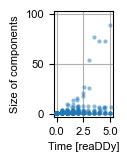

In [43]:
#plot time evolution of components in one exp sim 
start=0#70000       #39100
stop=101 #1001       #40100
step=10           #100
stp_x_l=np.arange(start,stop,step)*5*10**3

##step=25, stop=101, step_x=2
alpha_1=0.5

fig=plt.figure(figsize=(3.5/2.54 *0.55,3.5/2.54))

# stripplot of ortho x
stp_y=particles_per_component_read_in3[start:stop:step]
stp_x=np.arange(0,len(stp_y))
start_x=0
stop_x=len(stp_x)
step_x=5


fs1=8
sns.stripplot(data=stp_y,alpha=alpha_1,size=3,color="tab:blue")
plt.xticks(stp_x[start_x:stop_x:step_x],[0.0,2.5,5.0],fontname = "Arial",fontsize=fs1)

plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks([0,50,100],[0,50,100],fontname = "Arial",fontsize=fs1)

plt.ylabel("Size of components",fontname = "Arial",fontsize=fs1)
plt.xlabel("Time [ReaDDy]",fontname = "Arial",fontsize=fs1)
plt.ylim(-3,103)
plt.grid()
#plt.legend(prop={'family': 'Arial','size': 11},loc="upper right")

#plt.show()

#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/size_of_comp_D_shear_mod_soft_2_x_c_mech_opt_prod_0_V2a.pdf"
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/size_of_comp_D_shear_mod_soft_2_x_c_mech_opt_prod_0_V3a.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")



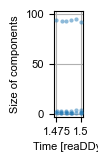

In [44]:
#plot final section of time evolution od components
start=len(time_pt_mech3)-51#70000       #39100
stop=len(time_pt_mech3) #101 #1001       #40100
step=10           #100
stp_x_l=np.arange(start,stop,step)*5*10**3

##step=25, stop=101, step_x=2
alpha_1=0.5

fig=plt.figure(figsize=(3.5/(2.54*2)*0.55,3.5/2.54))

# stripplot of ortho x
#stp_y=particles_per_component_read_in[start:stop:step]
stp_y=particles_per_component_read_in3[start:stop:step]

stp_x=np.arange(0,len(stp_y))
start_x=0
stop_x=len(stp_x)
step_x=5


fs1=8
sns.stripplot(data=stp_y,alpha=alpha_1,size=3,color="tab:blue")
plt.xticks(stp_x[start_x:stop_x:step_x],[1.475,1.5],fontname = "Arial",fontsize=fs1)

plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks([0,50,100],[0,50,100],fontname = "Arial",fontsize=fs1)

plt.ylabel("Size of components",fontname = "Arial",fontsize=fs1)
plt.xlabel("Time [ReaDDy]",fontname = "Arial",fontsize=fs1)
plt.ylim(-3,103)
#plt.xscale("log")
plt.grid()
#plt.legend(prop={'family': 'Arial','size': 11},loc="upper right")

#plt.show()

#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/size_of_comp_D_shear_mod_soft_2_x_c_mech_opt_prod_0_V2b.pdf"
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/size_of_comp_D_shear_mod_soft_2_x_c_mech_opt_prod_0_V3b.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")



# Connectivity and largest component as function of sticky end affinites

Fitted parameters: a=1483.4054528372078,n=-4.553678459097675e-05, b=-1483.6296624963638
R-squared: 0.998480773298693
RMSE: 0.008253041367818983
prediction: 0.351234190863579


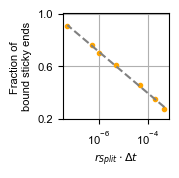

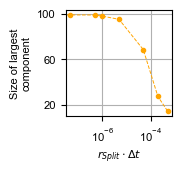

In [73]:
r_sp_list=np.array([5*10**-4,2*10**-4,5*10**-5,5*10**-6,1*10**-6,5*10**-7,5*10**-8,0])

bound_se_list=np.array([27.7,35.2,45.6,60.9,70.2,76.2,90.53,97])/100
bound_se_err_list=np.array([0.4,0.4,0.4,0.5,0.5,0.3,0.13,0])/100

largest_comp_list=np.array([14.59,27.4,68.4,94.93,97.78,98.71,98.80,98.80])
largest_comp_err_list=np.array([0.10,0.5,1.1,0.24,0.14,0.14,0.18,0.18])


fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

#fig=plt.figure(figsize=(5,5))

ax1.errorbar(r_sp_list,bound_se_list,yerr=bound_se_err_list,color="orange",linewidth=0.7,fmt=".")
#ax1.errorbar(r_sp_list,bound_se_list,yerr=bound_se_err_list,color="orange",linewidth=0.7,fmt="--")




def model_s(x, a,n, b):
    return a*x**n +b
x1=r_sp_list[:-1]
y1=bound_se_list[:-1]
params, _ = curve_fit(model_s, x1,y1,p0=[1,-0.5,75],maxfev = 20000)

# Extract fitted parameters
a,n, b = params
print(f"Fitted parameters: a={a},n={n}, b={b}")

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")

#plt.errorbar(rd_elem,19000*rd_elem**-0.66

plt.xscale("log")
#plt.yscale("log")

#ax1.set_yscale('symlog')
#ax1.set_xscale('symlog')
fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks([0.2,0.6,1],fontname = "Arial",fontsize=fs1)
plt.ylabel("Fraction of \nbound sticky ends",fontname = "Arial",fontsize=fs1)
plt.xlabel(r"$r_{Split}\cdot\Delta t$",fontname = "Arial",fontsize=fs1)
plt.grid()


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
print("prediction:",model_s(2*10**-4, *params))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/frac_bound_fct_split_rate_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")



fig2=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax2 = fig2.add_subplot(111)

#fig=plt.figure(figsize=(5,5))

ax2.errorbar(r_sp_list,largest_comp_list,yerr=largest_comp_err_list,color="orange",linewidth=0.7,fmt=".")
ax2.errorbar(r_sp_list,largest_comp_list,yerr=largest_comp_err_list,color="orange",linewidth=0.7,fmt="--")

plt.xscale("log")
#plt.yscale("log")

#ax1.set_yscale('symlog')
#ax1.set_xscale('symlog')
fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks([20,60,100],fontname = "Arial",fontsize=fs1)
plt.ylabel("Size of largest\ncomponent",fontname = "Arial",fontsize=fs1)
plt.xlabel(r"$r_{Split}\cdot\Delta t$",fontname = "Arial",fontsize=fs1)
plt.grid()
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/largest_comp_fct_split_rate_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")


# Storage and loss modulus from simulations

In [8]:
%%time 

#calculate G' and G'' from simulations

omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)

#use skip 5250 for cont 2 read in , use skip 11250 for 6e7 run (soft with r_ub=0)
folder_names_dyn_mod=[folder_names_all_ex[e] for e in [0,1,2,3,4,5,8,9]]
time_skip_dyn_mod=[2250,2250,2250,2250,2250,2250,5250,11250]
#print(folder_names_dyn_mod)
input_dyn_mod=[]
for i in range(len(folder_names_dyn_mod)):
    input_dyn_mod.append((folder_names_dyn_mod[i],omega_t_sim1,t_sim1,1,1,1,1,1,15,time_skip_dyn_mod[i]))


with ThreadPoolExecutor(max_workers=18) as executor:
    results_dyn_mod = list(executor.map(lambda args: avg_moduli_3(*args), input_dyn_mod))



/home/aaron/phd/DNA_Nanomotif_ML_MD/Networking_and_Rheology/NCG_readdy_sim_eval_3.py:491: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  eigv_all_t=np.array(eigv_all_t)
/home/aaron/phd/DNA_Nanomotif_ML_MD/Networking_and_Rheology/NCG_readdy_sim_eval_3.py:492: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  tau_all_t=np.array(tau_all_t)


CPU times: user 19min 45s, sys: 27min 31s, total: 47min 16s
Wall time: 12min 15s


In [9]:
# split results in storage, loss and cross links
storage_mod_all_sims_all=[results_dyn_mod[e][0] for e in range(len(results_dyn_mod))]
loss_mod_all_sims_all=[results_dyn_mod[e][1] for e in range(len(results_dyn_mod))]
cross_links_all_sims_all=[results_dyn_mod[e][2] for e in range(len(results_dyn_mod))]

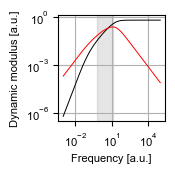

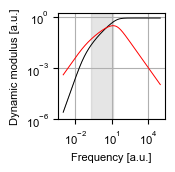

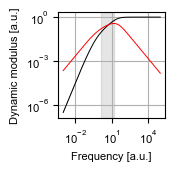

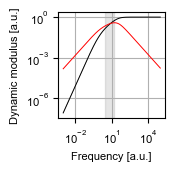

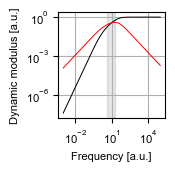

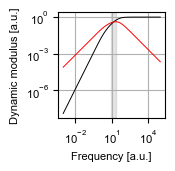

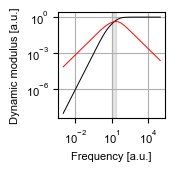

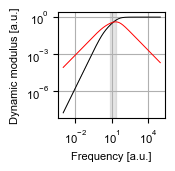

In [10]:
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
for i in range(len(storage_mod_all_sims_all)):
    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig.add_subplot(111)
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))
    
    ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],fmt="-",label=r"$G'$",color="black",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],fmt="-",label=r"$G''-\omega \eta$",color="red",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")

    #determine scaling
    n1=np.gradient(mean_storage_mod_all_sims_ex1,omega_t_sim1)/mean_storage_mod_all_sims_ex1 *omega_t_sim1
    n2=np.gradient(mean_loss_mod_all_sims_ex1,omega_t_sim1)/mean_loss_mod_all_sims_ex1 *omega_t_sim1
    # Condition: 0 < n < 1 for both
    mask = (n1 > 0) & (n1 < 1) & (n2 > 0) & (n2 < 1)
    
    # Find indices where condition holds
    indices = np.where(mask)[0]
    
    start_idx = indices[0]
    end_idx = indices[-1] 

    ax1.axvspan(omega_t_sim1[start_idx], omega_t_sim1[end_idx], color='gray', alpha=0.2)


    
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    #ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    fs1=8
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    #plt.ylim(10**-6,2)
    #plt.xlim(10**-3,10**3)
    plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
    plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
    #plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
    #plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
    ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
    #ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
    #if i ==0:
    save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_ub_rate_"+str(i)+"_1b.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

1000 1000
1000 1000
1000 1000
1000 1000
1000 1000
1000 1000
1000 1000
1000 1000


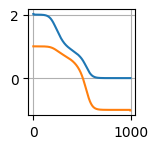

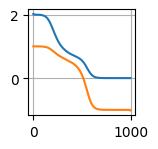

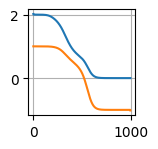

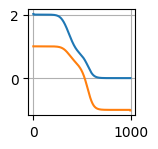

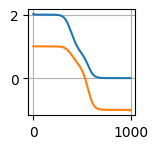

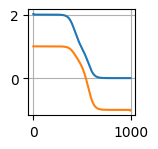

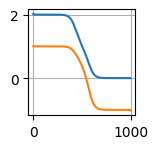

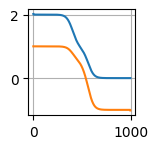

In [7]:
#slopes of G' and G''
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
for i in range(len(storage_mod_all_sims_all)):
    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig.add_subplot(111)
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))
    
    #ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],fmt="-",label=r"$G'$",color="black",linewidth=0.7)
    #ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    #ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],fmt="-",label=r"$G''-\omega \eta$",color="red",linewidth=0.7)
    #ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")


        
    
    
 
    # Compute log differences
    log_x = np.log(np.arange(1, len(mean_storage_mod_all_sims_ex1)+1))  # assuming index as x
    log_y1 = np.log(mean_storage_mod_all_sims_ex1)
    log_y2 = np.log(mean_loss_mod_all_sims_ex1)
    
    # Approximate local scaling exponent n
    #n1 = np.diff(log_y1) / np.diff(log_x)
    #n2 = np.diff(log_y2) / np.diff(log_x)
    n1=np.gradient(mean_storage_mod_all_sims_ex1,omega_t_sim1)/mean_storage_mod_all_sims_ex1 *omega_t_sim1
    n2=np.gradient(mean_loss_mod_all_sims_ex1,omega_t_sim1)/mean_loss_mod_all_sims_ex1 *omega_t_sim1
    print(len(n1),len(mean_storage_mod_all_sims_ex1))
    #mean_slope_storage_mod=np.gradient(np.mean(mean_storage_mod_all_sims_ex1,axis=0),omega_t_sim1) /np.mean(mean_storage_mod_all_sims_ex1,axis=0) *omega_t_sim1
    #mean_slope_loss_mod=np.gradient(np.mean(mean_loss_mod_all_sims_ex1,axis=0),omega_t_sim1)/np.mean(mean_loss_mod_all_sims_ex1,axis=0) *omega_t_sim1
    plt.plot(n1)
    plt.plot(n2)
    # Condition: 0 < n < 1 for both
    mask = (n1 > 0) & (n1 < 1) & (n2 > 0) & (n2 < 1)

    
    # Find indices where condition holds
    indices = np.where(mask)[0]
    
    start_idx = indices[0]
    end_idx = indices[-1] + 1  # +1 because diff reduces length by 1
    #ax1.axvline(log_x[end_idx])
    #ax1.axvline(log_x[start_idx])
   # ax1.axvspan(start_idx, end_idx, color='gray', alpha=0.3)

    
    
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    #ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    fs1=8
    #plt.xscale("log")
    #plt.yscale("log")
    plt.grid()



<Figure size 1000x1000 with 0 Axes>

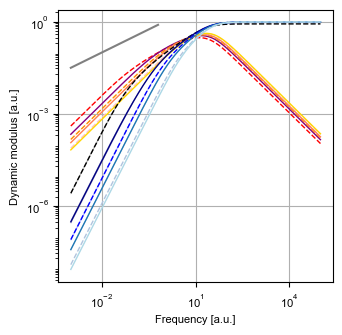

In [8]:
fig=plt.figure(figsize=(10,10))
fig=plt.figure(figsize=(9/2.54,9/2.54))

ax1 = fig.add_subplot(111)
"""
1: ub rate 0.005
2: ub rate 0.0005
7: ub rate 0.0001
8: ub rate 0.00005
5: ub rate 0.000005
0: ub rate 0"""

labels_storage1=[r"$G',~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G',~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'',~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['#D3D3D3', '#A9A9A9', '#696969', '#2F4F4F']
color_loss_list1=['#FF6666', '#FF0000', '#8B0000', '#4B0000']

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']


fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]

#for i in range(len(storage_mod_all_sims_all[:4])):
lii=0
for i in [1,2,3,4,5,6]:
    alpha1=1 -lii/5

    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))

    min_loss_mod_all_sims_ex1=np.min(loss_mod_all_sims_all[i],axis=0)
    max_loss_mod_all_sims_ex1=np.max(loss_mod_all_sims_all[i],axis=0)

    
    line1=ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt=fmt_loss_list1[lii],linewidth=1)
    ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::] ,facecolor=color_loss_list1[lii],alpha=0.3)
    #ax1.fill_between(omega_t_sim1[::], max_loss_mod_all_sims_ex1[::], min_loss_mod_all_sims_ex1[::] ,facecolor=color_loss_list1[lii],alpha=0.3)

    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1

lii=0
for i in [1,2,3,4,5,6]:

    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))
    
    min_storage_mod_all_sims_ex1=np.min(storage_mod_all_sims_all[i],axis=0)
    max_storage_mod_all_sims_ex1=np.max(storage_mod_all_sims_all[i],axis=0)

    line1=ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt=fmt_storage_list1[lii],linewidth=1)
    ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
    #ax1.fill_between(omega_t_sim1[::], max_storage_mod_all_sims_ex1[::], min_storage_mod_all_sims_ex1[::] ,facecolor=color_storage_list1[lii],alpha=0.3)

    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1
ax1.errorbar(omega_t_sim1[:350],omega_t_sim1[:350]**0.5 , label=r"$\omega^{0.5}$",color="grey")
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
#plt.xlim([0.5*10**-2,5*10**2])
#plt.ylim([10**-7,2])
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

<Figure size 1000x1000 with 0 Axes>

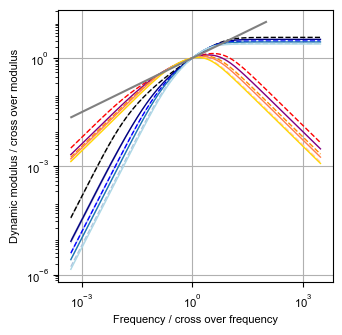

In [11]:
#Plot the curves witht the same cross over point
fig=plt.figure(figsize=(10,10))
fig=plt.figure(figsize=(9/2.54,9/2.54))

ax1 = fig.add_subplot(111)

labels_storage1=[r"$G'/G_{cf},~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"]

fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]

# --- NEW: cutoff option ---
omega_min = 0.5*10**-3   # e.g. 0.1  -- set to None to disable lower cutoff
omega_max = 3*10**3   # e.g. 100 -- set to None to disable upper cutoff

def apply_cutoff(x, *arrays):
    """Return x and each array in `arrays` masked to [omega_min, omega_max]."""
    mask = np.ones_like(x, dtype=bool)
    if omega_min is not None:
        mask &= (x >= omega_min)
    if omega_max is not None:
        mask &= (x <= omega_max)
    return (x[mask],) + tuple(a[mask] for a in arrays)

omega_cf_list=[]
G_cf_list=[]

lii=0
for i in [1,2,3,4,5,6]:
    alpha1=1 -lii/5

    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))

    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))

    # --- find crossover point for this curve pair ---
    omega_cf, G_cf = find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1,
                                        x2=omega_t_sim1, y2=mean_loss_mod_all_sims_ex1)[0]
    omega_cf_list.append(omega_cf)
    G_cf_list.append(G_cf)

    # --- rescale ---
    omega_scaled = omega_t_sim1 / omega_cf

    mean_loss_scaled = mean_loss_mod_all_sims_ex1 / G_cf
    std_e_loss_scaled = std_e_loss_mod_all_sims_ex1 / G_cf

    mean_storage_scaled = mean_storage_mod_all_sims_ex1 / G_cf
    std_e_storage_scaled = std_e_storage_mod_all_sims_ex1 / G_cf

    # --- NEW: apply cutoff, separately for loss and storage (they share omega_scaled) ---
    omega_loss_cut, mean_loss_cut, std_e_loss_cut = apply_cutoff(
        omega_scaled, mean_loss_scaled, std_e_loss_scaled)
    omega_storage_cut, mean_storage_cut, std_e_storage_cut = apply_cutoff(
        omega_scaled, mean_storage_scaled, std_e_storage_scaled)

    # --- plot loss (G'') ---
    line_loss=ax1.errorbar(omega_loss_cut[::], mean_loss_cut[::], label=labels_loss1[lii],
                            color=color_loss_list1[lii], fmt=fmt_loss_list1[lii], linewidth=1)
    ax1.fill_between(omega_loss_cut[::], mean_loss_cut[::] + std_e_loss_cut[::],
                      mean_loss_cut[::] - std_e_loss_cut[::],
                      facecolor=color_loss_list1[lii], alpha=0.3)

    # --- plot storage (G') ---
    line_storage=ax1.errorbar(omega_storage_cut[::], mean_storage_cut[::], label=labels_storage1[lii],
                               color=color_storage_list1[lii], fmt=fmt_storage_list1[lii], linewidth=1)
    ax1.fill_between(omega_storage_cut[::], mean_storage_cut[::] + std_e_storage_cut[::],
                      mean_storage_cut[::] - std_e_storage_cut[::],
                      alpha=0.3, facecolor=color_storage_list1[lii])

    lii=lii+1

# reference slope line (omega^0.5)
#ax1.errorbar(omega_t_sim1[:650],omega_t_sim1[:650]**0.5 , label=r"$\omega^{0.5}$",color="grey")

omega_ref=np.logspace(np.log10(min(omega_t_sim1)/max(omega_cf_list)),
                       np.log10(max(omega_t_sim1)/min(omega_cf_list)), 350)
omega_max_ref_curve=10**2
if omega_min is not None:
    omega_ref = omega_ref[omega_ref >= omega_min]
if omega_max_ref_curve is not None:
    omega_ref = omega_ref[omega_ref <= omega_max_ref_curve]
ax1.errorbar(omega_ref, omega_ref**0.5, label=r"$\omega^{0.5}$", color="grey")

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks([10**-3,10**0,10**3],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
#ax1.set_ylabel(r"$G'/G_{cf},\ G''/G_{cf}$ [-]",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel(r"$\omega/\omega_{cf}$ [-]",fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Dynamic modulus / cross over modulus",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency / cross over frequency",fontname = "Arial",fontsize=fs1)

#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_2.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [12]:
print(omega_cf_list)

print(G_cf_list)

[3.5609838895927544, 5.543221095028583, 7.868905924717284, 9.638344416121251, 14.196150977575329, 15.856913514930753]
[0.22767346831304644, 0.29046546062898165, 0.3295810704566693, 0.3521966311247663, 0.39074820152031997, 0.4019545266298512]


<Figure size 1000x1000 with 0 Axes>

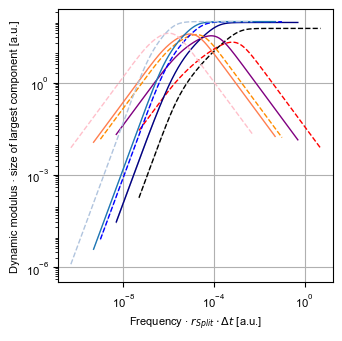

In [10]:
#Plot the curves with rescaling of overall moduli by fraction of SEs/size of largest component
fig=plt.figure(figsize=(10,10))
fig=plt.figure(figsize=(9/2.54,9/2.54))

ax1 = fig.add_subplot(111)

r_sp_list=np.array([5*10**-4,2*10**-4,5*10**-5,5*10**-6,1*10**-6,5*10**-7,5*10**-8,0])
#exlude cases not considered for moduli:
r_sp_list=r_sp_list[2:]
bound_se_list=np.array([27.7,35.2,45.6,60.9,70.2,76.2,90.53,97])/100
#bound_se_err_list=np.array([0.4,0.4,0.4,0.5,0.5,0.3,0.13,0])/100
#exlude cases not considered for moduli:
bound_se_list=bound_se_list[2:]

largest_comp_list=np.array([14.59,27.4,68.4,94.93,97.78,98.71,98.80,98.80])
#largest_comp_err_list=np.array([0.10,0.5,1.1,0.24,0.14,0.14,0.18,0.18])
#exlude cases not considered for moduli:
largest_comp_list=largest_comp_list[2:]


labels_storage1=[r"$G'/G_{cf},~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"]

fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]

# --- NEW: cutoff option ---
omega_min =None# 0.5*10**-3   # e.g. 0.1  -- set to None to disable lower cutoff
omega_max =None# 3*10**3   # e.g. 100 -- set to None to disable upper cutoff

def apply_cutoff(x, *arrays):
    """Return x and each array in `arrays` masked to [omega_min, omega_max]."""
    mask = np.ones_like(x, dtype=bool)
    if omega_min is not None:
        mask &= (x >= omega_min)
    if omega_max is not None:
        mask &= (x <= omega_max)
    return (x[mask],) + tuple(a[mask] for a in arrays)

omega_cf_list=[]
G_cf_list=[]

lii=0
for i in [1,2,3,4,5,6]:
    alpha1=1 -lii/5

    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))

    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))

    #select factor for rescaling:
    G_rs=largest_comp_list[lii] #bound_se_list[lii] #use lii due to ordering in saved arrays for larges comp and r sp
    omega_rs=r_sp_list[lii]

    # --- find crossover point for this curve pair ---
    omega_cf, G_cf = find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1,
                                        x2=omega_t_sim1, y2=mean_loss_mod_all_sims_ex1)[0]
    omega_cf_list.append(omega_cf)
    G_cf_list.append(G_cf)

    # --- rescale ---
    omega_scaled = omega_t_sim1 * omega_rs

    mean_loss_scaled = mean_loss_mod_all_sims_ex1 * G_rs
    std_e_loss_scaled = std_e_loss_mod_all_sims_ex1 * G_rs

    mean_storage_scaled = mean_storage_mod_all_sims_ex1 * G_rs
    std_e_storage_scaled = std_e_storage_mod_all_sims_ex1 * G_rs

    # --- NEW: apply cutoff, separately for loss and storage (they share omega_scaled) ---
    omega_loss_cut, mean_loss_cut, std_e_loss_cut = apply_cutoff(
        omega_scaled, mean_loss_scaled, std_e_loss_scaled)
    omega_storage_cut, mean_storage_cut, std_e_storage_cut = apply_cutoff(
        omega_scaled, mean_storage_scaled, std_e_storage_scaled)

    # --- plot loss (G'') ---
    line_loss=ax1.errorbar(omega_loss_cut[::], mean_loss_cut[::], label=labels_loss1[lii],
                            color=color_loss_list1[lii], fmt=fmt_loss_list1[lii], linewidth=1)
    ax1.fill_between(omega_loss_cut[::], mean_loss_cut[::] + std_e_loss_cut[::],
                      mean_loss_cut[::] - std_e_loss_cut[::],
                      facecolor=color_loss_list1[lii], alpha=0.3)

    # --- plot storage (G') ---
    line_storage=ax1.errorbar(omega_storage_cut[::], mean_storage_cut[::], label=labels_storage1[lii],
                               color=color_storage_list1[lii], fmt=fmt_storage_list1[lii], linewidth=1)
    ax1.fill_between(omega_storage_cut[::], mean_storage_cut[::] + std_e_storage_cut[::],
                      mean_storage_cut[::] - std_e_storage_cut[::],
                      alpha=0.3, facecolor=color_storage_list1[lii])

    lii=lii+1

# reference slope line (omega^0.5)
#ax1.errorbar(omega_t_sim1[:650],omega_t_sim1[:650]**0.5 , label=r"$\omega^{0.5}$",color="grey")

omega_ref=np.logspace(np.log10(min(omega_t_sim1)/max(omega_cf_list)),
                       np.log10(max(omega_t_sim1)/min(omega_cf_list)), 350)
omega_max_ref_curve=10**2
if omega_min is not None:
    omega_ref = omega_ref[omega_ref >= omega_min]
if omega_max_ref_curve is not None:
    omega_ref = omega_ref[omega_ref <= omega_max_ref_curve]
#ax1.errorbar(omega_ref, omega_ref**0.5, label=r"$\omega^{0.5}$", color="grey")

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks([10**-8,10**-4,10**0],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
#ax1.set_ylabel(r"$G'/G_{cf},\ G''/G_{cf}$ [-]",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel(r"$\omega/\omega_{cf}$ [-]",fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Dynamic modulus · fraction of bound sticky ends [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel(r"Frequency · $r_{Split} \cdot \Delta t$ [a.u.]",fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Dynamic modulus · size of largest component [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel(r"Frequency · $r_{Split} \cdot \Delta t$ [a.u.]",fontname = "Arial",fontsize=fs1)

#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_shifted_r_split_size_comp1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [10]:
#Calculate proxy quantities for stress bearing fraction in the material

#https://arxiv.org/pdf/2103.16181


#get graph Laplacians across repeats and time points
def return_graph_Laplacians(folder_names,omega_t_sim1,t_sim1,b_u,zeta_u,k_u,T_u,phi_u,time_step,time_skip):
    L_all_sims=[]
    for p in range(len(folder_names)):
        name_load_in=folder_names[p]
        traj_mech=readdy.Trajectory(name_load_in)

        time_obs_top_mech,obs_top_mech=traj_mech.read_observable_topologies()
    
        storage_mod_avg_t_nc,storage_mod_stde_t_nc,loss_mod_avg_t_nc,loss_mod_stde_t_nc,relaxation_mod_avg_t_nc,relaxation_mod_stde_t_nc,conn_mat_all_t,eigv_all_t,tau_all_t=get_time_avg_storage_loss_mod(obs_top=obs_top_mech,time_step=time_step,time_skip=time_skip,omega_t=omega_t_sim1,t=t_sim1,edges_centre=4,edges_linker=3,cutoff_zero_eigv=10**-9,zeta=zeta_u,b=b_u,k=k_u,T=T_u,phi=phi_u)


        L_all_sims.append(conn_mat_all_t)

    return L_all_sims



import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
from collections import deque

#get adjacency matrix from graph laplacian
def adjacency_from_laplacian(L):
    W = -np.asarray(L).copy()
    np.fill_diagonal(W, 0)
    return W

#get giant component that could be stress bearing
def giant_component_indices(W):
    n_components, labels = connected_components(sp.csr_matrix(W), directed=False)
    giant_label = np.bincount(labels).argmax()
    return np.where(labels == giant_label)[0]

#remove dangling ends, i.e. nanostar only connected with one edge
def k_core_mask(adj, k=2):
    """Pure numpy/scipy k-core peeling (Batagelj-Zaversnik, O(V+E))."""
    adj = sp.csr_matrix(adj)
    n = adj.shape[0]
    neighbors = [adj.indices[adj.indptr[i]:adj.indptr[i+1]] for i in range(n)]
    degree = np.array([len(nb) for nb in neighbors])
    active = np.ones(n, dtype=bool)

    queue = deque(np.where(degree < k)[0])
    in_queue = np.zeros(n, dtype=bool)
    in_queue[list(queue)] = True

    while queue:
        node = queue.popleft()
        if not active[node]:
            continue
        active[node] = False
        for nb in neighbors[node]:
            if active[nb]:
                degree[nb] -= 1
                if degree[nb] < k and not in_queue[nb]:
                    queue.append(nb)
                    in_queue[nb] = True
    return active
#get the stress bearing fraction as giant component, stripped of nanostars only connnected with one edge
def backbone_fraction(L, k=2):
    W_bin = (adjacency_from_laplacian(L) != 0).astype(int)
    giant_idx = giant_component_indices(W_bin)
    W_giant = W_bin[np.ix_(giant_idx, giant_idx)]
    mask = k_core_mask(W_giant, k=k)
    return mask.sum() / L.shape[0]

def cyclomatic_number(L, giant_only=True, normalize=True):
    """
    Cyclomatic number (rank of the cycle space): xi = E - V + C,
    where E = edges, V = nodes, C = number of connected components.
    If normalize=True, returns xi / L.shape[0] -- independent loops
    per nanostar (proxy for loop/stress-bearing density).
    """
    W_bin = (adjacency_from_laplacian(L) != 0).astype(int)

    if giant_only:
        giant_idx = giant_component_indices(W_bin)
        W_bin = W_bin[np.ix_(giant_idx, giant_idx)]
        C = 1
    else:
        n_components, _ = connected_components(sp.csr_matrix(W_bin), directed=False)
        C = n_components

    V = W_bin.shape[0]
    E = sp.triu(sp.csr_matrix(W_bin), k=1).nnz

    xi = E - V + C
    return xi / L.shape[0] if normalize else xi

def measure_of_stress_bearing_from_sim(all_L):
    #all_L[i][j]=grap Laplacian from repeat i, for time point j
    bf_frac=[]
    cyclo_frac=[]
    for i in range(len(all_L)):
        for j in range(len(all_L[i])):
            L=all_L[i][j]
            bf_frac.append(backbone_fraction(L, k=2))
            cyclo_frac.append(cyclomatic_number(L, giant_only=True, normalize=True))
    return bf_frac, cyclo_frac
            

In [11]:
%%time 

#calculate all graph Laplacians from simulations

omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)

#use skip 5250 for cont 2 read in , use skip 11250 for 6e7 run (soft with r_ub=0)
folder_names_dyn_mod=[folder_names_all_ex[e] for e in [0,1,2,3,4,5,8,9]]
time_skip_dyn_mod=[2250,2250,2250,2250,2250,2250,5250,11250]
#print(folder_names_dyn_mod)
input_dyn_mod=[]
for i in range(len(folder_names_dyn_mod)):
    input_dyn_mod.append((folder_names_dyn_mod[i],omega_t_sim1,t_sim1,1,1,1,1,1,15,time_skip_dyn_mod[i]))


with ThreadPoolExecutor(max_workers=18) as executor:
    results_L = list(executor.map(lambda args: return_graph_Laplacians(*args), input_dyn_mod))



CPU times: user 20min 1s, sys: 29min 53s, total: 49min 54s
Wall time: 5min 12s


In [12]:
#bf_frac_test1, cyclo_frac_test1=measure_of_stress_bearing_from_sim(all_L=results_L[0])


bf_frac_sims=[np.mean(measure_of_stress_bearing_from_sim(all_L=results_L[i])[0]) for i in range(len(results_L))   ]
cyclo_frac_sims=[np.mean(measure_of_stress_bearing_from_sim(all_L=results_L[i])[1]) for i in range(len(results_L))   ]




In [16]:
print(bf_frac_sims)
print(cyclo_frac_sims)
print((bf_frac_sims[-2]-bf_frac_sims[-1])/bf_frac_sims[-2] *100)
print((cyclo_frac_sims[-2]-cyclo_frac_sims[-1])/cyclo_frac_sims[-2] *100)

[0.04094117647058824, 0.30854901960784314, 0.7617254901960785, 0.883921568627451, 0.9510196078431372, 0.981764705882353, 0.9880000000000002, 0.982]
[0.006941176470588235, 0.05262745098039216, 0.2526666666666667, 0.41478431372549024, 0.5209411764705882, 0.8053333333333333, 0.9040000000000001, 0.7565490196078432]
0.6072874493927355
16.310949158424442


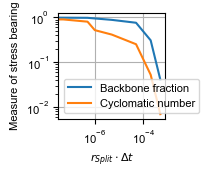

In [14]:
r_sp_list=np.array([5*10**-4,2*10**-4,5*10**-5,5*10**-6,1*10**-6,5*10**-7,5*10**-8,0])

fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)
plt.errorbar(r_sp_list,bf_frac_sims,label="Backbone fraction")
plt.errorbar(r_sp_list,cyclo_frac_sims,label="Cyclomatic number")


fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#ax1.set_ylabel(r"$G'/G_{cf},\ G''/G_{cf}$ [-]",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel(r"$\omega/\omega_{cf}$ [-]",fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Measure of stress bearing",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel(r"$r_{Split} \cdot \Delta t$ ",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower left")


<Figure size 1000x1000 with 0 Axes>

<Figure size 354.331x354.331 with 0 Axes>

<Figure size 137.795x137.795 with 0 Axes>

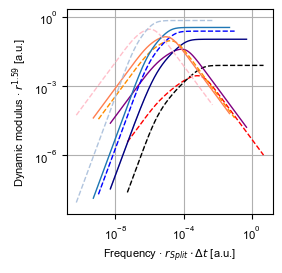

In [178]:
#Plot the curves with rescaling of overall moduli by fraction of SEs/size of largest component
fig=plt.figure(figsize=(10,10))
fig=plt.figure(figsize=(9/2.54,9/2.54))
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
fig=plt.figure(figsize=(9*0.75/2.54,9*0.75/2.54))

ax1 = fig.add_subplot(111)

r_sp_list=np.array([5*10**-4,2*10**-4,5*10**-5,5*10**-6,1*10**-6,5*10**-7,5*10**-8,0])
#exlude cases not considered for moduli:
r_sp_list=r_sp_list[2:]
bound_se_list=np.array([27.7,35.2,45.6,60.9,70.2,76.2,90.53,97])/100
#bound_se_err_list=np.array([0.4,0.4,0.4,0.5,0.5,0.3,0.13,0])/100
#exlude cases not considered for moduli:
bound_se_list=bound_se_list[2:]

largest_comp_list=np.array([14.59,27.4,68.4,94.93,97.78,98.71,98.80,98.80])
#largest_comp_err_list=np.array([0.10,0.5,1.1,0.24,0.14,0.14,0.18,0.18])
#exlude cases not considered for moduli:
largest_comp_list=largest_comp_list[2:]


labels_storage1=[r"$G'/G_{cf},~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"]

fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]

# --- NEW: cutoff option ---
omega_min =None# 0.5*10**-3   # e.g. 0.1  -- set to None to disable lower cutoff
omega_max =None# 3*10**3   # e.g. 100 -- set to None to disable upper cutoff

def apply_cutoff(x, *arrays):
    """Return x and each array in `arrays` masked to [omega_min, omega_max]."""
    mask = np.ones_like(x, dtype=bool)
    if omega_min is not None:
        mask &= (x >= omega_min)
    if omega_max is not None:
        mask &= (x <= omega_max)
    return (x[mask],) + tuple(a[mask] for a in arrays)

omega_cf_list=[]
G_cf_list=[]

lii=0
for i in [1,2,3,4,5,6]:
    alpha1=1 -lii/5

    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))

    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))

    #select factor for rescaling:
    G_rs=cyclo_frac_sims[i]**1.59#cyclo_frac_sims[i]#bf_frac_sims[i] #bound_se_list[lii]
    omega_rs=r_sp_list[lii]

    # --- find crossover point for this curve pair ---
    omega_cf, G_cf = find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1,
                                        x2=omega_t_sim1, y2=mean_loss_mod_all_sims_ex1)[0]
    omega_cf_list.append(omega_cf)
    G_cf_list.append(G_cf)

    # --- rescale ---
    omega_scaled = omega_t_sim1 * omega_rs

    mean_loss_scaled = mean_loss_mod_all_sims_ex1 * G_rs
    std_e_loss_scaled = std_e_loss_mod_all_sims_ex1 * G_rs

    mean_storage_scaled = mean_storage_mod_all_sims_ex1 * G_rs
    std_e_storage_scaled = std_e_storage_mod_all_sims_ex1 * G_rs

    # --- NEW: apply cutoff, separately for loss and storage (they share omega_scaled) ---
    omega_loss_cut, mean_loss_cut, std_e_loss_cut = apply_cutoff(
        omega_scaled, mean_loss_scaled, std_e_loss_scaled)
    omega_storage_cut, mean_storage_cut, std_e_storage_cut = apply_cutoff(
        omega_scaled, mean_storage_scaled, std_e_storage_scaled)

    # --- plot loss (G'') ---
    line_loss=ax1.errorbar(omega_loss_cut[::], mean_loss_cut[::], label=labels_loss1[lii],
                            color=color_loss_list1[lii], fmt=fmt_loss_list1[lii], linewidth=1)
    ax1.fill_between(omega_loss_cut[::], mean_loss_cut[::] + std_e_loss_cut[::],
                      mean_loss_cut[::] - std_e_loss_cut[::],
                      facecolor=color_loss_list1[lii], alpha=0.3)

    # --- plot storage (G') ---
    line_storage=ax1.errorbar(omega_storage_cut[::], mean_storage_cut[::], label=labels_storage1[lii],
                               color=color_storage_list1[lii], fmt=fmt_storage_list1[lii], linewidth=1)
    ax1.fill_between(omega_storage_cut[::], mean_storage_cut[::] + std_e_storage_cut[::],
                      mean_storage_cut[::] - std_e_storage_cut[::],
                      alpha=0.3, facecolor=color_storage_list1[lii])

    lii=lii+1

# reference slope line (omega^0.5)
#ax1.errorbar(omega_t_sim1[:650],omega_t_sim1[:650]**0.5 , label=r"$\omega^{0.5}$",color="grey")

omega_ref=np.logspace(np.log10(min(omega_t_sim1)/max(omega_cf_list)),
                       np.log10(max(omega_t_sim1)/min(omega_cf_list)), 350)
omega_max_ref_curve=10**2
if omega_min is not None:
    omega_ref = omega_ref[omega_ref >= omega_min]
if omega_max_ref_curve is not None:
    omega_ref = omega_ref[omega_ref <= omega_max_ref_curve]
#ax1.errorbar(omega_ref, omega_ref**0.5, label=r"$\omega^{0.5}$", color="grey")

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks([10**-8,10**-4,10**0],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
#ax1.set_ylabel(r"$G'/G_{cf},\ G''/G_{cf}$ [-]",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel(r"$\omega/\omega_{cf}$ [-]",fontname = "Arial",fontsize=fs1)

#ax1.set_ylabel(r"Dynamic modulus · $b$ [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_ylabel(r"Dynamic modulus · $r^{1.59}$ [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel(r"Frequency · $r_{Split} \cdot \Delta t$ [a.u.]",fontname = "Arial",fontsize=fs1)

#ax1.set_ylabel("Dynamic modulus · size of largest component [a.u.]",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel(r"Frequency · $r_{Split} \cdot \Delta t$ [a.u.]",fontname = "Arial",fontsize=fs1)

#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_shifted_r_split_size_comp1.pdf"
save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_shifted_r_split_r_norm1.pdf"
save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_shifted_r_split_f_SE1.pdf"
save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_shifted_r_split_b1.pdf"
save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_shifted_r_split_r_power1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

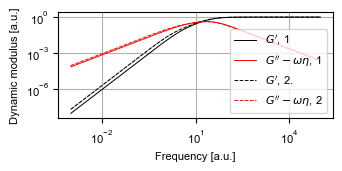

In [103]:
#compare two conditions (e.g., with and without inter-arm potentials)

#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(7/2.54,7/2.54))
fig=plt.figure(figsize=(9/2.54,3.5/2.54))

ax1 = fig.add_subplot(111)
linestyle=["-","--",":","-."]
k=0
labels_1=[r"$G'$, 1",r"$G'$, 2.",r"$G'$, 3"]
labels_2=[r"$G''-\omega \eta$, 1",r"$G''-\omega \eta$, 2",r"$G''-\omega \eta$, 3"]
for i in [-2,-1]: #[2,3]
    
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))

    
    ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],fmt=linestyle[k],label=labels_1[k],color="black",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],fmt=linestyle[k],label=labels_2[k],color="red",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")
    
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    #ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    k=k+1
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**-6,2)
#plt.xlim(10**-3,10**3)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_normal_soft_2_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

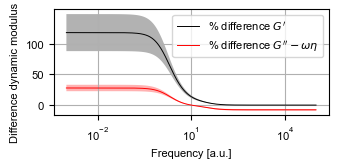

In [104]:
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(9/2.54,3.5/2.54))
#fig=plt.figure(figsize=(10,10))

ax1 = fig.add_subplot(111)
linestyle=["-","--",":"]


ex1=-2 #2
ex2=-1   #3

#diff_mean_storage=(np.mean(storage_mod_all_sims_all[ex2],axis=0)-np.mean(storage_mod_all_sims_all[ex1],axis=0))/np.mean(storage_mod_all_sims_all[ex1],axis=0)

#diff_mean_loss=(np.mean(loss_mod_all_sims_all[ex2],axis=0)-np.mean(loss_mod_all_sims_all[ex1],axis=0))/np.mean(loss_mod_all_sims_all[ex1],axis=0)


mean_storage_S1 = np.mean(storage_mod_all_sims_all[ex1], axis=0)
mean_storage_S2 = np.mean(storage_mod_all_sims_all[ex2], axis=0)

sem_storage_S1  = np.std(storage_mod_all_sims_all[ex1], axis=0) / np.sqrt(len(storage_mod_all_sims_all[ex1]))
sem_storage_S2  = np.std(storage_mod_all_sims_all[ex2], axis=0) / np.sqrt(len(storage_mod_all_sims_all[ex2]))



mean_loss_S1 = np.mean(loss_mod_all_sims_all[ex1], axis=0)
mean_loss_S2 = np.mean(loss_mod_all_sims_all[ex2], axis=0)

sem_loss_S1  = np.std(loss_mod_all_sims_all[ex1], axis=0) / np.sqrt(len(loss_mod_all_sims_all[ex1]))
sem_loss_S2  = np.std(loss_mod_all_sims_all[ex2], axis=0) / np.sqrt(len(loss_mod_all_sims_all[ex2]))



diff_mean_storage= (mean_storage_S2 - mean_storage_S1) / mean_storage_S1 *100

std_e_diff_mean_storage = np.sqrt(
    (sem_storage_S2 / mean_storage_S1)**2 +
    (mean_storage_S2 * sem_storage_S1 / mean_storage_S1**2)**2) *100 

diff_mean_loss= (mean_loss_S2 - mean_loss_S1) / mean_loss_S1 *100

std_e_diff_mean_loss = np.sqrt(
    (sem_loss_S2 / mean_loss_S1)**2 +
    (mean_loss_S2 * sem_loss_S1 / mean_loss_S1**2)**2) *100 


#err_diff_mean_loss=np.sqrt( (np.std(loss_mod_all_sims_all[ex1],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[ex1]))))**2 + (np.std(loss_mod_all_sims_all[ex2],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[ex2]))))**2 )

#err_diff_mean_storage=np.sqrt( (np.std(storage_mod_all_sims_all[ex1],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[ex1]))))**2 + (np.std(storage_mod_all_sims_all[ex2],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[ex2]))))**2 )


ax1.errorbar(omega_t_sim1[::],diff_mean_storage[::],fmt="-",label=r"% difference $G'$",color="black",linewidth=0.7)
ax1.fill_between(omega_t_sim1[::], diff_mean_storage[::] + std_e_diff_mean_storage[::], diff_mean_storage[::] - std_e_diff_mean_storage[::], alpha = 0.3 ,facecolor="black")


ax1.errorbar(omega_t_sim1[::],diff_mean_loss[::],fmt="-",label=r"% difference $G''-\omega \eta$",color="red",linewidth=0.7)
ax1.fill_between(omega_t_sim1[::], diff_mean_loss[::] + std_e_diff_mean_loss[::], diff_mean_loss[::] - std_e_diff_mean_loss[::], alpha = 0.3 ,facecolor="red")


fs1=8
plt.xscale("log")
#plt.yscale("log")
plt.grid()
#plt.ylim(10**-6,2)
#plt.xlim(10**-3,10**3)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
plt.yticks([0,50,100],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Difference dynamic modulus [%]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="upper right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_difference_normal_soft_2_2.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

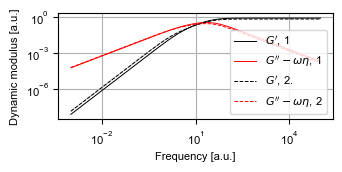

In [117]:
#compare two conditions (e.g., with and without inter-arm potentials), use rescaling by bond lifetime and stress bearing fraction

#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(7/2.54,7/2.54))
fig=plt.figure(figsize=(9/2.54,3.5/2.54))

ax1 = fig.add_subplot(111)
linestyle=["-","--",":","-."]
k=0
labels_1=[r"$G'$, 1",r"$G'$, 2.",r"$G'$, 3"]
labels_2=[r"$G''-\omega \eta$, 1",r"$G''-\omega \eta$, 2",r"$G''-\omega \eta$, 3"]
for i in [-2,-1]: #[2,3]
    G_rs=cyclo_frac_sims[i] #bf_frac_sims[i] 
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)*G_rs
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))*G_rs
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0)*G_rs
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))*G_rs

    
    

    
    ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],fmt=linestyle[k],label=labels_1[k],color="black",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::]- std_e_storage_mod_all_sims_ex1[::]*G_rs, mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],fmt=linestyle[k],label=labels_2[k],color="red",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")
    
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    #ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    k=k+1
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**-6,2)
#plt.xlim(10**-3,10**3)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_normal_soft_2_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [114]:
cyclo_frac_sims

[0.006941176470588235,
 0.05262745098039216,
 0.2526666666666667,
 0.41478431372549024,
 0.5209411764705882,
 0.8053333333333333,
 0.9040000000000001,
 0.7565490196078432]

In [113]:
bf_frac_sims

[0.04094117647058824,
 0.30854901960784314,
 0.7617254901960785,
 0.883921568627451,
 0.9510196078431372,
 0.981764705882353,
 0.9880000000000002,
 0.982]

In [73]:
traj_mech2=readdy.Trajectory(folder_names_dyn_mod[1][0])

time_obs_top_mech2,obs_top_mech2=traj_mech2.read_observable_topologies()
storage_mod_avg_t_nc,storage_mod_stde_t_nc,loss_mod_avg_t_nc,loss_mod_stde_t_nc,relaxation_mod_avg_t_nc,relaxation_mod_stde_t_nc,conn_mat_all_t,eigv_all_t,tau_all_t=get_time_avg_storage_loss_mod(obs_top=obs_top_mech2,time_step=15,time_skip=2250,omega_t=omega_t_sim1,t=t_sim1,edges_centre=4,edges_linker=3,cutoff_zero_eigv=10**-15,zeta=1,b=1,k=1,T=1,phi=1)


In [101]:
#test out the influence of adding relaxation times
tau_1=[e for e in tau_all_t[0]]
tau_1.append(10**50)
tau_1=np.array(tau_1)
sm1=storage_mod(phi=1,k=1,T=1,N=100,b=1,tau=tau_1,omega=omega_t_sim1)
lm1=loss_mod_deref(phi=1,k=1,T=1,N=100,b=1,tau=tau_1,omega=omega_t_sim1)

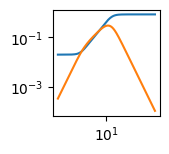

In [102]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(omega_t_sim1,sm1)
ax1.errorbar(omega_t_sim1,lm1)

plt.yscale("log")
plt.xscale("log")

# Include hydrodynamic tensor

dx/dt = H * Z * x +H * f

H is in general a non-linear function of R_n - R_m -> do pre-averaging for problems near equilibrium 
(M. Doi and S. F. Edwards, The Theory of Polymer Dynamics(Oxford University Press, 1988).) page 100

H: mobility, converts force vector into velocity vector
Z: Graph laplacian, transforms position vector into force vector
f: random force, dissipation fluctuation theoreme


#################

Zimm paper: 
Dynamics of Polymer Molecules in Dilute Solution:
Viscoelasticity, Flow Birefringence and Dielectric Loss

disusses eigenvalues and eigenvectors of H * Z for solution, intruduces pre-averagin
i.e. replacing H with static operator <H> (averaged over particle distances)

Other relevant literature

#################

Ring polymers:
https://pubs.acs.org/doi/10.1021/acs.jpcb.4c05788

Use pre-averaged H, and Z for connecting monomers

#################

BD with hydro. interactions:
https://pubs.aip.org/aip/jcp/article/148/19/194111/198240/Multi-resolution-polymer-Brownian-dynamics-with

Discusses pre-averaging in BD equation for dynamics 

#################

star and ring polmyers with Zimm model:

https://pubs.aip.org/aip/jcp/article/163/15/154901/3367779/Numerical-calculation-of-intrinsic-viscosity-of

suppl,discusses Z, and H matrices, uses 
eigenvalues for G(t) calculation


####################

modes in colloidial gels:

https://journals.aps.org/pre/abstract/10.1103/PhysRevE.97.012608

discusses eigenvalue problem with  Z and H matrices

discusses hydr. dynamic lubrication as near field contribution when particles nearly touch

#################
General discussion of using eigenvalues of connectivtiy matrix for relaxation dynamics and simulations with HI:

https://www.sciencedirect.com/science/article/pii/S0022309306009008

#################

Very clear discussion on Rouse-Zimm model and relaxation times from H*A eigenvalues:

https://pmc.ncbi.nlm.nih.gov/articles/PMC11244006/


################

Use of diagnoalization and eigenvalues of H*A for G' adn G'' in model :

https://pmc.ncbi.nlm.nih.gov/articles/PMC6403701/


###########

Diagonalization of H and A:


https://pubs.rsc.org/en/content/articlehtml/2013/cp/c3cp53864h

#################
#new nanostar paper:

Mechanical response of a simple DNA nanostar hydrogel:
symptoms of disorder and glassy emergence of solidity.

#Strategy:

Use pre-averaged form of H:

H_mn=1/(6 * pi * eta * a) for m=n

H_mn=1/(6 * pi * eta) * <1/R_mn>

get average 1/R_nm from eq simulations snapshots
calculate eigenvalues of H*Z

mostly compresses the relaxation time spectrum as slow modes (global) are speed up more than fast ones (local), as beads "drag" solvent, reducing viscous drag
need to check that H stays postive semidefinite with N eigenvalues for interpretation, this can be violated for large bead radius, when particles overlap and approximation of Oseen tensor not valid anymore!


In [13]:
#from NCG_readdy_sim_eval_3.py:
#include hydrodynamic interaction
#function that converts edges at time point t into connectivity matrix and eigenvalues from observed topology

def get_conn_mat_eigv_hydro1(time_sel,obs_top,part_pos,edges_centre,edges_linker,box_size, eta, a):
    #time_sel: time point to evaluate
    #obs_top: observed topologies for all time steps
    #part_pos: particle positions for all time steps
    #edges_centre: get vertices with this number of edges
    #edges_linker:get linkers this number of edges away from centre particles
    #box_size: [Lx,Ly,Lz] box size for minimum image pbc conditions
    #eta: viscosity
    #a: hydr radius

    
    #all edges at time point time_sel
    edges_ids_t=get_list_of_all_edges(time_sel=time_sel,tops=obs_top)

    #get all vertices with n edges (i.e. all centre particles)
    vertices_with_n_edges_t=vertices_with_n_edges(edges=edges_ids_t,count_edges=edges_centre)

    #print("centre vertices:",vertices_with_n_edges_t)

    #get all vertices m edges away from centre particles (i.e. get all linker particles)
    vertices_m_edges_away_t=[]
    for i in range(len(vertices_with_n_edges_t)):
        check_v=vertices_with_n_edges_t[i]
        vertices_m_edges_away_t.append( vertices_n_edges_away(edges=edges_ids_t, start_vertex=check_v,number_edges=edges_linker) )
        
        
    #print("linker from centre particles",vertices_m_edges_away_t)
    #create adjacency matrix 
    adjacency_matrix_t=create_adjacency_matrix(edges=edges_ids_t, sublists=vertices_m_edges_away_t)
    
    #create connectivity matrix 
    connectivity_matrix_t=np.zeros( (len(adjacency_matrix_t),len(adjacency_matrix_t))  )
    #fill main diagonal with number of edges (i.e. sum of each column)
    for i in range(len(connectivity_matrix_t)):
            connectivity_matrix_t[i][i]=np.sum(adjacency_matrix_t[i])
    #fill off diagonal entries with entries of connectivity matrix    
    for i in range(len(connectivity_matrix_t)):
        for j in range(i): #dont go to main diagonal 
            connectivity_matrix_t[i][j]=adjacency_matrix_t[i][j]*-1
            connectivity_matrix_t[j][i]=adjacency_matrix_t[i][j]*-1

    #####connectivity_matrix_t=rouse_laplacian(N=len(connectivity_matrix_t))
    #create hydro tensor

    #assumption: connectivty matriy i,j, contains info about link between centre particle i and centre particle j
    #the ids of centrer particle i an j are in stored in vertices_with_n_edges_t[i or j]
    #just need to get distance between i,j, with ppc condition
    #check: if distance between paired nanomotifs (Z_ij=1) is always roughly same, then this method should work

    centre_particle_coords=[]
    for i in range(len(vertices_with_n_edges_t)):
        k=vertices_with_n_edges_t[i] #index of centre particle i
        centre_particle_coords.append(part_pos[time_sel][k]) # position of centre particle i with index k

    centre_particle_coords=np.array(centre_particle_coords)


    #hydrodynamic tensor
    #rot average
    #H_t=compute_oa_rpy_matrix(positions=centre_particle_coords, box_size=box_size,eta=eta, a=a)

    #pre-average
    H_t=compute_pre_avg_rpy_matrix(positions=centre_particle_coords, box_size=box_size,eta=eta, a=a)
    print(len(H_t),len(H_t[0]))
    
    #######eigenvalues=hydr_spectrum(H=H_t, Z=connectivity_matrix_t, rtol=1e-14)
    eigenvalues=calculate_viscoelastic_eigenvalues(H=H_t, Z=connectivity_matrix_t)
    #eigenvalues=scipy.linalg.eigvals(H_t @ connectivity_matrix_t)
    #eigenvalues=calculate_viscoelastic_eigenvalues(H=np.eye(len(connectivity_matrix_t)), Z=connectivity_matrix_t)

    diagnostic_rank_test(positions=centre_particle_coords, Z=connectivity_matrix_t, H=H_t, tol=1e-10)

    #hydrodynamic tensor v2
    #H_t=compute_rpy_mobility_matrix(positions=centre_particle_coords, box_size=box_size, eta_s=eta, a=a)
    #eigenvalues=hydr_spectrum(H=H_t, Z=connectivity_matrix_t, rtol=1e-14)

    return connectivity_matrix_t, eigenvalues




def oa_rpy_scalar(r, eta, a):
    """
    Orientationally Averaged Rotne–Prager–Yamakawa (OA-RPY) mobility
    between two beads separated by distance r.
    
    Parameters
    ----------
    r : float
        Distance between beads.
    eta : float
        Solvent viscosity.
    a : float
        Hydrodynamic radius of each bead.

    Returns
    -------
    float
        OA-RPY mobility value H_ij.
    """

    # Self-term
    #print(r)
    if r < 1e-15:
        return 1 / (6 * np.pi * eta * a)

    # Non-overlapping (r > 2a)
    if r > 2*a:
        return 1/(6*np.pi*eta)*1/r #(1/(6*np.pi*eta*a)) * ((3*a)/(4*r) + (a**3)/(2*r**3)) #1/(6*np.pi*eta)*1/r

    # Overlapping (r =< 2a)
    else:
        return 1/(6*np.pi*eta) * (1/a -1*r/(4*a**2)) #(1/(6*np.pi*eta*a)) * (1 - (9*r)/(32*a)) # 1/(6*np.pi*eta) * (1/a -r/(4*a**2))



def compute_oa_rpy_matrix(positions, box_size,eta=1e-3, a=5e-9):
    """
    Compute the full OA-RPY N×N mobility matrix for bead positions.

    Parameters
    ----------
    positions : array (N, 3)
        3D coordinates of beads.
        
    box_size: size of periodic box for minimum image convention
    
    eta : float
        Solvent viscosity.
    a : float
        Hydrodynamic radius.
    

    Returns
    -------
    H : array (N, N)
        OA-RPY mobility matrix.
    """
    positions = np.asarray(positions)
    N = positions.shape[0]
    H = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            v=positions[j] - positions[i]
            r=pbc_distance(v, box_size)
            H[i, j] = oa_rpy_scalar(r, eta, a) #orientational average

    return H
#pre averaged, static hydr. interaction. Takes avg_inv_d=<1/r> average as input
def pre_avg_RPY(r, eta, a):
    if r < 1e-15:
        return 1 / (6 * np.pi * eta * a)
    else:
        return 1 / (6 * np.pi * eta *r) 

def compute_pre_avg_rpy_matrix(positions, box_size,eta=1e-3, a=5e-9):
    """
    Compute the pre averaged RPY N×N mobility matrix for bead positions.

    Parameters
    ----------
    positions : array (N, 3)
        3D coordinates of beads.
        
    box_size: size of periodic box for minimum image convention
    
    eta : float
        Solvent viscosity.
    a : float
        Hydrodynamic radius.
    

    Returns
    -------
    H : array (N, N)
        pre averaged mobility matrix.
    """
    positions = np.asarray(positions)
    N = positions.shape[0]
    H = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            v=positions[j] - positions[i]
            r=pbc_distance(v, box_size)
            H[i, j] = pre_avg_RPY(r, eta, a)#pre average

    return H



from scipy.linalg import sqrtm, eigvalsh

def hydr_spectrum(H, Z, rtol=1e-14):
    """
    Compute eigenvalues of the hydrodynamically renormalized operator
        L = H^{1/2} Z H^{1/2}
    to use as relaxation‑rate eigenvalues for a generalized Maxwell model.

    Parameters
    ----------
    H : array (N, N)
        Symmetric positive definite mobility matrix (OA-RPY, etc.).
    Z : array (N, N)
        Graph Laplacian (or spring matrix).
    rtol : float
        Threshold for dropping numerically zero eigenvalues.

    Returns
    -------
    λ : array (N_nonzero,)
        Eigenvalues of H^{1/2} Z H^{1/2}, in increasing order.
    τ : array (N_nonzero,)
        Corresponding relaxation times: τ = 1/λ.
    """
    # 1) H^{1/2}
    H_sqrt = sqrtm(H)                 # matrix square root
    # 2) L = H^{1/2} Z H^{1/2} (symmetric)
    L = H_sqrt @ Z @ H_sqrt

    # 3) eigenvalues of L
    eigv = eigvalsh(L)                    


    return eigv

'''

def compute_rpy_matrix(positions, eta=1e-3, a=5e-9):
    """
    Build the full 3N x 3N hydrodynamic mobility matrix.
    positions : (N,3) numpy array
    """
    positions = np.asarray(positions)
    N = positions.shape[0]

    H = np.zeros((3*N, 3*N))

    for i in range(N):
        for j in range(N):
            r_ij = positions[j] - positions[i]
            H_block = rpy_tensor(r_ij, eta, a)
            H[3*i:3*i+3, 3*j:3*j+3] = H_block

    return H


def rpy_tensor(r_ij, eta, a):
    """
    Compute 3x3 Rotne–Prager–Yamakawa mobility tensor between two beads.
    r_ij : 3D vector between particles i and j
    eta  : viscosity
    a    : bead hydrodynamic radius
    """
    r = np.linalg.norm(r_ij)
    I = np.eye(3)

    if r < 1e-12:
        # self-term: diagonal mobility (Stokes)
        return (1.0 / (6 * np.pi * eta * a)) * I

    r_hat = r_ij / r
    rr = np.outer(r_hat, r_hat)

    if r >= 2*a:
        term1 = (1/(8*np.pi*eta*r)) * (I + rr)
        term2 = (a*a/(4*np.pi*eta*r**3)) * (I - 3*rr)
        return term1 + term2
    else:
        # Overlapping / near-field correction
        # Regularization from Rotne–Prager–Yamakawa theory
        return (1/(6*np.pi*eta*a)) * (
            (4/3 - 3*r/(32*a)) * I
            + (r/(32*a)) * rr
        )

'''




'\n\ndef compute_rpy_matrix(positions, eta=1e-3, a=5e-9):\n    """\n    Build the full 3N x 3N hydrodynamic mobility matrix.\n    positions : (N,3) numpy array\n    """\n    positions = np.asarray(positions)\n    N = positions.shape[0]\n\n    H = np.zeros((3*N, 3*N))\n\n    for i in range(N):\n        for j in range(N):\n            r_ij = positions[j] - positions[i]\n            H_block = rpy_tensor(r_ij, eta, a)\n            H[3*i:3*i+3, 3*j:3*j+3] = H_block\n\n    return H\n\n\ndef rpy_tensor(r_ij, eta, a):\n    """\n    Compute 3x3 Rotne–Prager–Yamakawa mobility tensor between two beads.\n    r_ij : 3D vector between particles i and j\n    eta  : viscosity\n    a    : bead hydrodynamic radius\n    """\n    r = np.linalg.norm(r_ij)\n    I = np.eye(3)\n\n    if r < 1e-12:\n        # self-term: diagonal mobility (Stokes)\n        return (1.0 / (6 * np.pi * eta * a)) * I\n\n    r_hat = r_ij / r\n    rr = np.outer(r_hat, r_hat)\n\n    if r >= 2*a:\n        term1 = (1/(8*np.pi*eta*r)) * 

In [14]:
def compute_rpy_mobility_matrix(positions, box_size,eta_s, a):
    """
    Computes the mobility matrix H using the orientationally averaged RPY tensor.
    
    Parameters:
    positions (np.ndarray): N x 3 array of (x, y, z) coordinates.
    eta_s (float): Solvent viscosity (Pa*s).
    a (float): Hydrodynamic radius of a node (m).
    
    Returns:
    np.ndarray: N x N symmetric mobility matrix H.
    """
    N = positions.shape[0]
    H = np.zeros((N, N))
    
    # Pre-calculate common factors
    prefactor = 1.0 / (6.0 * np.pi * eta_s)
    self_mobility = prefactor / a
    
    for i in range(N):
        for j in range(N):
            if i == j:
                H[i, j] = self_mobility
            else:
                # Calculate Euclidean distance r_ij
                v=positions[j] - positions[i]
                r_ij=pbc_distance(v, box_size)
                
                if r_ij >= 2 * a:
                    # Non-overlapping case
                    H[i, j] = (prefactor / r_ij) * (1 + (2 * a**2) / (3 * r_ij**2))
                else:
                    # Overlapping case (regularization)
                    H[i, j] = (prefactor / a) *(1 -r_ij/(4*a))#  * (1 - (3 * r_ij) / (8 * a)) #*(1 -r_ij/(4*a))
                    
    return H


# Usage:
# diagnostic_rank_test(my_positions, my_Z, my_H)

# Relaxation time and moduli scaling in Rouse and Zimm picture, to test H*Z evaluation

number relaxation times Z: 99
number relaxation times HZ: 99


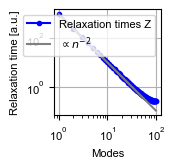

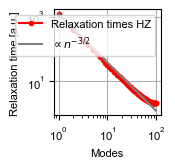

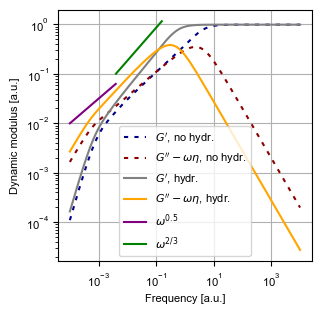

In [7]:
fs1=8

N_c=100
Z_g_chain=rouse_laplacian(N=N_c)

H_g_chain=compute_pre_avg_gaussian_chain_matrix(N=N_c, b=1,a=0.25,eta=1)

#plt.matshow(Z_g_chain)
#plt.show()
eigv_Z_g_chain=calculate_viscoelastic_eigenvalues(H=np.eye(N_c,N_c), Z=Z_g_chain)
relax_t_Z_g_chain=[1/e for e in eigv_Z_g_chain if e>10**-9]
print("number relaxation times Z:",len(relax_t_Z_g_chain))

fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

plt.plot(np.arange(1,len(relax_t_Z_g_chain)+1),relax_t_Z_g_chain,label="Relaxation times Z",marker=".",color="blue")
scaling_1=1/(np.arange(1,N_c)**2)
scaling_1=scaling_1/scaling_1[0] *relax_t_Z_g_chain[0]
plt.plot(np.arange(1,len(scaling_1)+1),scaling_1 ,label=r"$\propto n^{-2}$",color="grey")
plt.yscale("log")
plt.xscale("log")
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Relaxation time [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Modes",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="upper right")
plt.grid()

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/relax_time_rouse_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
#plt.show()

eigv_HZ_g_chain=calculate_viscoelastic_eigenvalues(H=H_g_chain, Z=Z_g_chain)
relax_t_HZ_g_chain=[1/e for e in eigv_HZ_g_chain if e>10**-9]
print("number relaxation times HZ:",len(relax_t_HZ_g_chain))


fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

plt.plot(np.arange(1,len(relax_t_HZ_g_chain)+1),relax_t_HZ_g_chain,label="Relaxation times HZ",marker=".",color="red")
scaling_2=(1/(np.arange(1,N_c)))**(3/2) #1.7
scaling_2=scaling_2/scaling_2[0] *relax_t_HZ_g_chain[0]
plt.plot(np.arange(1,len(scaling_2)+1),scaling_2,label=r"$\propto n^{-3/2}$",color="grey")
plt.yscale("log")
plt.xscale("log")
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Relaxation time [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Modes",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="upper right")
plt.grid()
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/relax_time_zimm_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
#plt.show()


############################################
############################################

omega_t_sim1=np.geomspace(10**-4,10**4,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-5,10**5,10**2)
phi_u=1
k_u=1
T_u=1
b_u=1

###########
###########
###########
sm_no_hydr=storage_mod(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=np.array(relax_t_Z_g_chain),omega=omega_t_sim1)
lm_no_hydr=loss_mod_deref(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=np.array(relax_t_Z_g_chain),omega=omega_t_sim1)
###########
###########
###########

sm_hydr=storage_mod(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=np.array(relax_t_HZ_g_chain),omega=omega_t_sim1)
lm_hydr=loss_mod_deref(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=np.array(relax_t_HZ_g_chain),omega=omega_t_sim1)


omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=sm_no_hydr, x2=omega_t_sim1, y2=lm_no_hydr)[0]
omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1, y1=sm_hydr, x2=omega_t_sim1, y2=lm_hydr)[0]


omega_t_sim1_shift=np.array(omega_t_sim1)  #*omega_inters_target_1/omega_inters_1
sm_hydr_shift=np.array(sm_hydr)  #*dyn_mod_inters_target_1/dyn_mod_inters_1
lm_hydr_shift=np.array(lm_hydr)  #*dyn_mod_inters_target_1/dyn_mod_inters_1


fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))
ax1 = fig.add_subplot(111)

visc_eff=0#10**-3

line1=ax1.errorbar(omega_t_sim1,sm_no_hydr,label=r"$G'$, no hydr.",color="darkblue")
line2=ax1.errorbar(omega_t_sim1,lm_no_hydr+omega_t_sim1*visc_eff,label=r"$G''-\omega \eta$, no hydr.",color="darkred")
line1[0].set_dashes([2, 3])  
line2[0].set_dashes([2, 3])  


ax1.errorbar(omega_t_sim1_shift,sm_hydr_shift,label=r"$G'$, hydr.",color="grey")
ax1.errorbar(omega_t_sim1_shift,lm_hydr_shift+omega_t_sim1_shift*visc_eff,label=r"$G''-\omega \eta$, hydr.",color="orange")

#ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
#ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$",color="purple")
#ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
ax1.errorbar(omega_t_sim1[200:400],omega_t_sim1[200:400]**(2/3) *4 , label=r"$\omega^{2/3}$",color="green")

plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower center")
plt.grid()
plt.yscale("log")
plt.xscale("log")

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_rouse_zimm_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")


# Test results for relaxation times and moduli for single trajectory

In [8]:


#load saved config
traj_mech_x=readdy.Trajectory("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_0/x_c_mech_opt_prod_cont_2_0.h5")
#traj_mech_x=readdy.Trajectory("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_3/prod_checkpoint_1/x_c_mech_opt_prod_1.h5")
#traj_mech_x=readdy.Trajectory("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_0/x_c_mech_opt_prod_0.h5")

times_mech_x,types_mech_x,ids_mech_x,part_positions_mech_x=traj_mech_x.read_observable_particles()
time_pt_mech_x, counts_pt_mech_x = traj_mech_x.read_observable_number_of_particles()
#part_pos_eq=part_positions

time_e_mech_x, energy_mech_x=traj_mech_x.read_observable_energy()

time_obs_top_mech_x,obs_top_mech_x=traj_mech_x.read_observable_topologies()

--- DIAGNOSTIC REPORT ---
Total Nodes (N): 100
Rank of Z: 98 (Expected 99 for connected graph)
Disconnected components found: 2
-------------------------
Rank of H: 100 (Expected 100)
Condition Number of H: 5.31e+01
-------------------------
Non-zero evals (Direct H*Z): 98
Non-zero evals (Symmetric):  98

CONCLUSION: System is numerically consistent.
CPU times: user 7.91 s, sys: 2.6 s, total: 10.5 s
Wall time: 596 ms


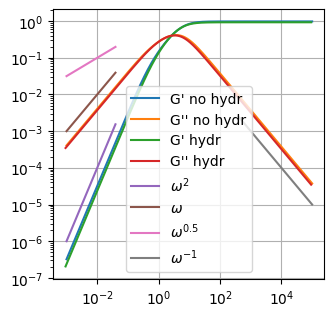

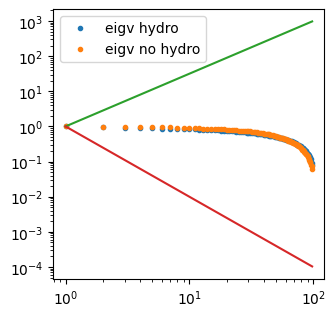

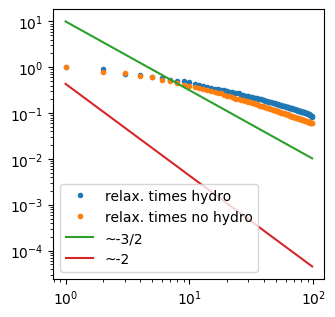

In [9]:
%%time
# parameter estimates:
#hydr radius [nm]
box_size=[69.7,69.7,69.7]
a_u=4.7#4.7#7.5#7#7#4.7 #10 #100 #4.7 #4.7 #15

system_temperature=1 #273.15 + 40  #293

kbt=1 #system_temperature*1.380649*10**-23

visc_T_sys=10**-6 #visc_T(system_temperature)

#eta=

b_u=1 #20 #[m] #Kuhn length, treating rough diameter of sphere around one X-motif as Kuhn length

zeta_u=1 #6*np.pi * visc_T_sys *b_u

k_u=1 #1.380649*10**-23 #[J/K]
T_u=1 #system_temperature  #[K]
phi_u=1#(100  * 4/3 * np.pi * (b_u/2)**3)/69.7**3 #[1] #Volume fraction occupied by polymer, fraction occopied by spheres with Kuhn length

omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #np.geomspace(10**-4,10**4,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)

for visc_T_sys in [8*10**-3]: #8*10**-3 #variying this shifts hydr curves to left or right, without chaning the scaling
    
    #no hydr:
    conn_mat_test_no_hydr_1, eigv_test_no_hydro_1 =get_conn_mat_eigv_1(time_sel=-1,obs_top=obs_top_mech_x,edges_centre=4,edges_linker=3)
    eigv_test_no_hydro_1=[e for e in eigv_test_no_hydro_1 if e>10**-9]
    eigv_test_no_hydro_1=np.array(eigv_test_no_hydro_1)
    #with hydr:
    conn_mat_test_hydr_1, eigv_test_hydro_1 =get_conn_mat_eigv_hydro2(time_sel=-10,obs_top=obs_top_mech_x,part_pos=part_positions_mech_x,edges_centre=4,edges_linker=3,box_size=box_size, eta=visc_T_sys, a=a_u,t_r_avg_f=-20,t_r_avg_l=None)
    #conn_mat_test_hydr_1, eigv_test_hydro_1 =get_conn_mat_eigv_hydro1(time_sel=-1,obs_top=obs_top_mech_x,part_pos=part_positions_mech_x,edges_centre=4,edges_linker=3,box_size=box_size, eta=visc_T_sys, a=a_u)
    eigv_test_hydro_1_all=eigv_test_hydro_1
    eigv_test_hydro_1=[e for e in eigv_test_hydro_1 if e>10**-9]
    eigv_test_hydro_1=np.array(eigv_test_hydro_1)
    
    
    ###########
    ###########
    ###########
    tau_no_hydr=np.array(1/eigv_test_no_hydro_1)
    
    sm_no_hydr=storage_mod(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_no_hydr,omega=omega_t_sim1)
    lm_no_hydr=loss_mod_deref(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_no_hydr,omega=omega_t_sim1)
    ###########
    ###########
    ###########
    
    tau_hydr=np.array(1/eigv_test_hydro_1)
    sm_hydr=storage_mod(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_hydr,omega=omega_t_sim1)
    lm_hydr=loss_mod_deref(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_hydr,omega=omega_t_sim1)

    
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=sm_no_hydr, x2=omega_t_sim1, y2=lm_no_hydr)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
    
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1, y1=sm_hydr, x2=omega_t_sim1, y2=lm_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_shift=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_1
    sm_hydr_shift=np.array(sm_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    lm_hydr_shift=np.array(lm_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    
    
    fig=plt.figure(figsize=(3.5,3.5))
    ax1 = fig.add_subplot(111)
    
    visc_eff=0#10**-3
    
    ax1.errorbar(omega_t_sim1,sm_no_hydr,label="G' no hydr")
    ax1.errorbar(omega_t_sim1,lm_no_hydr+omega_t_sim1*visc_eff,label="G'' no hydr")
    
    #ax1.errorbar(omega_t_sim1,sm_hydr,label="G' hydr")
    #ax1.errorbar(omega_t_sim1,lm_hydr+omega_t_sim1*visc_eff,label="G'' hydr")
    
    ax1.errorbar(omega_t_sim1_shift,sm_hydr_shift,label="G' hydr")
    ax1.errorbar(omega_t_sim1_shift,lm_hydr_shift+omega_t_sim1_shift*visc_eff,label="G'' hydr")

    ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    
    plt.legend()
    
    
    plt.yscale("log")
    plt.xscale("log")
    plt.grid()
    
    
    fig=plt.figure(figsize=(3.5,3.5))
    ax1 = fig.add_subplot(111)
    plt.errorbar(np.arange(1,len(eigv_test_hydro_1)+1),eigv_test_hydro_1[::-1]/eigv_test_hydro_1[::-1][0],fmt=".",label="eigv hydro")
    
    plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1),np.sort(eigv_test_no_hydro_1)[::-1]/np.sort(eigv_test_no_hydro_1)[::-1][0],fmt=".",label="eigv no hydro")
    plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1) ,np.arange(1,len(eigv_test_no_hydro_1)+1)**(3/2)   )
    plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1) ,1/(np.arange(1,len(eigv_test_no_hydro_1)+1)**2)   )

    plt.legend()
    
    
    plt.yscale("log")
    plt.xscale("log")

    fig=plt.figure(figsize=(3.5,3.5))
    ax1 = fig.add_subplot(111)

    plt.errorbar(np.arange(1,len(tau_hydr)+1),tau_hydr/tau_hydr[0],label="relax. times hydro",fmt=".")
    plt.errorbar(np.arange(1,len(tau_no_hydr)+1),np.sort(tau_no_hydr)[::-1]/np.sort(tau_no_hydr)[::-1][0],label="relax. times no hydro",fmt=".")
    plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1) ,np.arange(1,len(eigv_test_no_hydro_1)+1)**(-3/2)*10 ,label="~-3/2"  )
    plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1) ,1/(np.arange(1,len(eigv_test_no_hydro_1)+1)**2)/np.sort(tau_no_hydr)[::-1][0] ,label="~-2"  )
    plt.legend()
    
    plt.yscale("log")
    plt.xscale("log")


In [10]:
len(eigv_test_hydro_1)

98

--- DIAGNOSTIC REPORT ---
Total Nodes (N): 100
Rank of Z: 98 (Expected 99 for connected graph)
Disconnected components found: 2
-------------------------
Rank of H: 100 (Expected 100)
Condition Number of H: 5.31e+01
-------------------------
Non-zero evals (Direct H*Z): 98
Non-zero evals (Symmetric):  98

CONCLUSION: System is numerically consistent.
CPU times: user 11.7 s, sys: 4 s, total: 15.6 s
Wall time: 815 ms


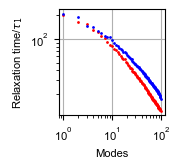

In [11]:
%%time
# parameter estimates:
#hydr radius [nm]
box_size=[69.7,69.7,69.7]
a_u=4.7#4.7#7.5#7#7#4.7 #10 #100 #4.7 #4.7 #15

system_temperature=1 #273.15 + 40  #293

kbt=1 #system_temperature*1.380649*10**-23

visc_T_sys=10**-6 #visc_T(system_temperature)

#eta=

b_u=1 #20 #[m] #Kuhn length, treating rough diameter of sphere around one X-motif as Kuhn length

zeta_u=1 #6*np.pi * visc_T_sys *b_u

k_u=1 #1.380649*10**-23 #[J/K]
T_u=1 #system_temperature  #[K]
phi_u=1#(100  * 4/3 * np.pi * (b_u/2)**3)/69.7**3 #[1] #Volume fraction occupied by polymer, fraction occopied by spheres with Kuhn length

omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #np.geomspace(10**-4,10**4,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)

for visc_T_sys in [1]: #variying this shifts hydr curves to left or right, without chaning the scaling
    
    #no hydr:
    conn_mat_test_no_hydr_1, eigv_test_no_hydro_1 =get_conn_mat_eigv_1(time_sel=-1,obs_top=obs_top_mech_x,edges_centre=4,edges_linker=3)
    #eigv with samge function for same pre-fac
    h_p=1/(6*np.pi*visc_T_sys*a_u)
    eigv_test_no_hydro_1=calculate_viscoelastic_eigenvalues(H=h_p*np.eye(len(conn_mat_test_no_hydr_1[0])), Z=conn_mat_test_no_hydr_1)
    
    eigv_test_no_hydro_1=[e for e in eigv_test_no_hydro_1 if e>10**-9]
    eigv_test_no_hydro_1=np.array(eigv_test_no_hydro_1)
    #with hydr:
    conn_mat_test_hydr_1, eigv_test_hydro_1 =get_conn_mat_eigv_hydro2(time_sel=-10,obs_top=obs_top_mech_x,part_pos=part_positions_mech_x,edges_centre=4,edges_linker=3,box_size=box_size, eta=visc_T_sys, a=a_u,t_r_avg_f=-20,t_r_avg_l=None)
    #conn_mat_test_hydr_1, eigv_test_hydro_1 =get_conn_mat_eigv_hydro1(time_sel=-1,obs_top=obs_top_mech_x,part_pos=part_positions_mech_x,edges_centre=4,edges_linker=3,box_size=box_size, eta=visc_T_sys, a=a_u)
    eigv_test_hydro_1_all=eigv_test_hydro_1
    eigv_test_hydro_1=[e for e in eigv_test_hydro_1 if e>10**-9]
    eigv_test_hydro_1=np.array(eigv_test_hydro_1)
    
    
    ###########
    ###########
    ###########
    tau_no_hydr=np.array(1/eigv_test_no_hydro_1)
    
    sm_no_hydr=storage_mod(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_no_hydr,omega=omega_t_sim1)
    lm_no_hydr=loss_mod_deref(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_no_hydr,omega=omega_t_sim1)
    ###########
    ###########
    ###########
    
    tau_hydr=np.array(1/eigv_test_hydro_1)
    sm_hydr=storage_mod(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_hydr,omega=omega_t_sim1)
    lm_hydr=loss_mod_deref(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_hydr,omega=omega_t_sim1)


    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=sm_no_hydr, x2=omega_t_sim1, y2=lm_no_hydr)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
    
    
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1, y1=sm_hydr, x2=omega_t_sim1, y2=lm_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_shift=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_1
    sm_hydr_shift=np.array(sm_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    lm_hydr_shift=np.array(lm_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1


    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig.add_subplot(111)

    plt.errorbar(np.arange(1,len(tau_no_hydr)+1),np.sort(tau_no_hydr)[::-1],label="Without hydr. int.",fmt=".",color="red",markersize=2)
    plt.errorbar(np.arange(1,len(tau_hydr)+1),tau_hydr,label="With hydr. int.",fmt=".",color="blue",markersize=2)


    #plt.errorbar(np.arange(1,len(tau_no_hydr)+1),np.sort(tau_no_hydr)[::-1]/np.sort(tau_no_hydr)[::-1][0],label="Without hydr. int.",fmt=".",color="red",markersize=2)
    #plt.errorbar(np.arange(1,len(tau_hydr)+1),tau_hydr/tau_hydr[0],label="With hydr. int.",fmt=".",color="blue",markersize=2)


    #plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1) ,np.arange(1,len(eigv_test_no_hydro_1)+1)**(-3/2)*10 ,label="~-3/2"  )
    #plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1) ,1/(np.arange(1,len(eigv_test_no_hydro_1)+1)**2)/np.sort(tau_no_hydr)[::-1][0] ,label="~-2"  )
    #plt.legend()
    fs1=8
    plt.grid()
    plt.xticks(fontname = "Arial",fontsize=fs1)
    plt.yticks(fontname = "Arial",fontsize=fs1)
    plt.xscale("log")
    plt.yscale("log")
    ax1.set_ylabel(r"Relaxation time/$\tau_1$",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Modes",fontname = "Arial",fontsize=fs1)
    #ax1.legend(prop={'family': 'Arial','size': fs1},loc="upper right")
    save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/relax_times_high_splitting_1.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")


In [12]:
print((tau_hydr[0]-np.sort(tau_no_hydr)[::-1][0])/np.sort(tau_no_hydr)[::-1][0] *100)
print((tau_hydr[-1]-np.sort(tau_no_hydr)[::-1][-1])/np.sort(tau_no_hydr)[::-1][-1] *100)

1.5989836694123936
38.88197955003217


# Averaged results for moduli with HI from many time steps and repeats

In [71]:
%%time
#calculate G' and G'' from simulations

omega_t_sim1_hydr=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1_hydr=np.geomspace(10**-2,10**3,10**2)

#use skip 5250 for cont 2 read in , use skip 11250 for 6e7 run (soft with r_ub=0)
#folder_names_dyn_mod=[folder_names_all_ex[e] for e in [8,2]]  #8,2
#time_skip_dyn_mod=[5250,2250] #,2250]

folder_names_dyn_mod=[folder_names_all_ex[e] for e in [0,1,2,3,4,5,8,9]]
time_skip_dyn_mod=[2250,2250,2250,2250,2250,2250,5250,11250]


#folder_names_dyn_mod=[["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]]
#time_skip_dyn_mod=[11250]

#print(folder_names_dyn_mod)
input_dyn_mod=[]
box_size=[69.7,69.7,69.7]
eta=8*10**-3
a=4.7
t_r_avg_f=-10
t_r_avg_l=10

for i in range(len(folder_names_dyn_mod)):
    input_dyn_mod.append((folder_names_dyn_mod[i],omega_t_sim1_hydr,t_sim1_hydr,1,1,1,1,1,15,time_skip_dyn_mod[i],box_size,eta,a,t_r_avg_f,t_r_avg_l))

with ThreadPoolExecutor(max_workers=18) as executor:
    results_dyn_mod_hydr = list(executor.map(lambda args: avg_moduli_hydr_3(*args), input_dyn_mod))




calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  1
calc. for sim  1


/home/aaron/phd/DNA_Nanomotif_ML_MD/Networking_and_Rheology/NCG_readdy_sim_eval_4.py:1638: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  eigv_all_t=np.array(eigv_all_t)
/home/aaron/phd/DNA_Nanomotif_ML_MD/Networking_and_Rheology/NCG_readdy_sim_eval_4.py:1639: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  tau_all_t=np.array(tau_all_t)


calc. for sim  1
calc. for sim  1
calc. for sim  1
calc. for sim  1
calc. for sim  1
calc. for sim  1
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  3
calc. for sim  3
calc. for sim  3
calc. for sim  3
calc. for sim  3
calc. for sim  3
calc. for sim  4
calc. for sim  3
calc. for sim  3
calc. for sim  4
calc. for sim  4
calc. for sim  4
calc. for sim  4
calc. for sim  4
calc. for sim  4
calc. for sim  4
CPU times: user 1h 16min 1s, sys: 4min 50s, total: 1h 20min 52s
Wall time: 10min 1s


In [72]:
# split results in storage, loss and cross links
storage_mod_all_sims_all_hydr=[results_dyn_mod_hydr[e][0] for e in range(len(results_dyn_mod_hydr))]
loss_mod_all_sims_all_hydr=[results_dyn_mod_hydr[e][1] for e in range(len(results_dyn_mod_hydr))]
cross_links_all_sims_all_hydr=[results_dyn_mod_hydr[e][2] for e in range(len(results_dyn_mod_hydr))]

Intersection: omega: 5.441945562137645 dynamic mod. 0.2312266880703019


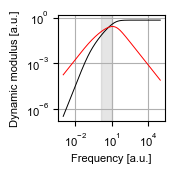

Intersection: omega: 4.203800339631481 dynamic mod. 0.2479061964470763


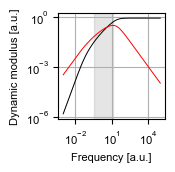

Intersection: omega: 6.424306683675146 dynamic mod. 0.3137166319624163


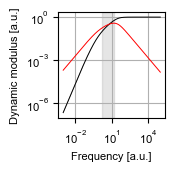

Intersection: omega: 8.789464193672563 dynamic mod. 0.34881192210070566


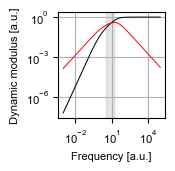

Intersection: omega: 10.765903664660382 dynamic mod. 0.37458284903553335


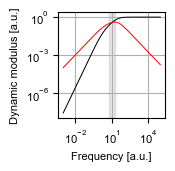

Intersection: omega: 15.567205177720382 dynamic mod. 0.4146613567793895


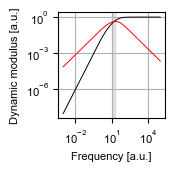

Intersection: omega: 17.070674820805195 dynamic mod. 0.4215166608732558


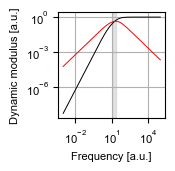

Intersection: omega: 15.003570851511046 dynamic mod. 0.43022374351179155


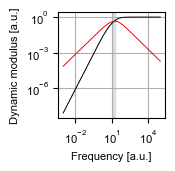

In [35]:


#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
for i in range(len(storage_mod_all_sims_all_hydr)):
    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig.add_subplot(111)
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all_hydr[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr[i])))
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all_hydr[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr[i])))
    
    ax1.errorbar(omega_t_sim1_hydr[::],mean_storage_mod_all_sims_ex1[::],fmt="-",label=r"$G'$",color="black",linewidth=0.7)
    ax1.fill_between(omega_t_sim1_hydr[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    ax1.errorbar(omega_t_sim1_hydr[::],mean_loss_mod_all_sims_ex1[::],fmt="-",label=r"$G''-\omega \eta$",color="red",linewidth=0.7)
    ax1.fill_between(omega_t_sim1_hydr[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")

    #determine scaling
    n1=np.gradient(mean_storage_mod_all_sims_ex1,omega_t_sim1_hydr)/mean_storage_mod_all_sims_ex1 *omega_t_sim1_hydr
    n2=np.gradient(mean_loss_mod_all_sims_ex1,omega_t_sim1_hydr)/mean_loss_mod_all_sims_ex1 *omega_t_sim1_hydr
    # Condition: 0 < n < 1 for both
    mask = (n1 > 0) & (n1 < 1) & (n2 > 0) & (n2 < 1)
    
    # Find indices where condition holds
    indices = np.where(mask)[0]
    
    start_idx = indices[0]
    end_idx = indices[-1] 

    ax1.axvspan(omega_t_sim1_hydr[start_idx], omega_t_sim1_hydr[end_idx], color='gray', alpha=0.2)

    
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1_hydr, y1=mean_storage_mod_all_sims_ex1, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1)[0]
    print("Intersection:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
   
    
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    #ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    fs1=8
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    #plt.ylim(10**-6,2)
    #plt.xlim(10**-3,10**3)
    plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
    plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
    #plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
    #plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
    ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
    #ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
    #if i ==0:
    save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_ub_rate_hydr_"+str(i)+"_1b.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
    plt.show()

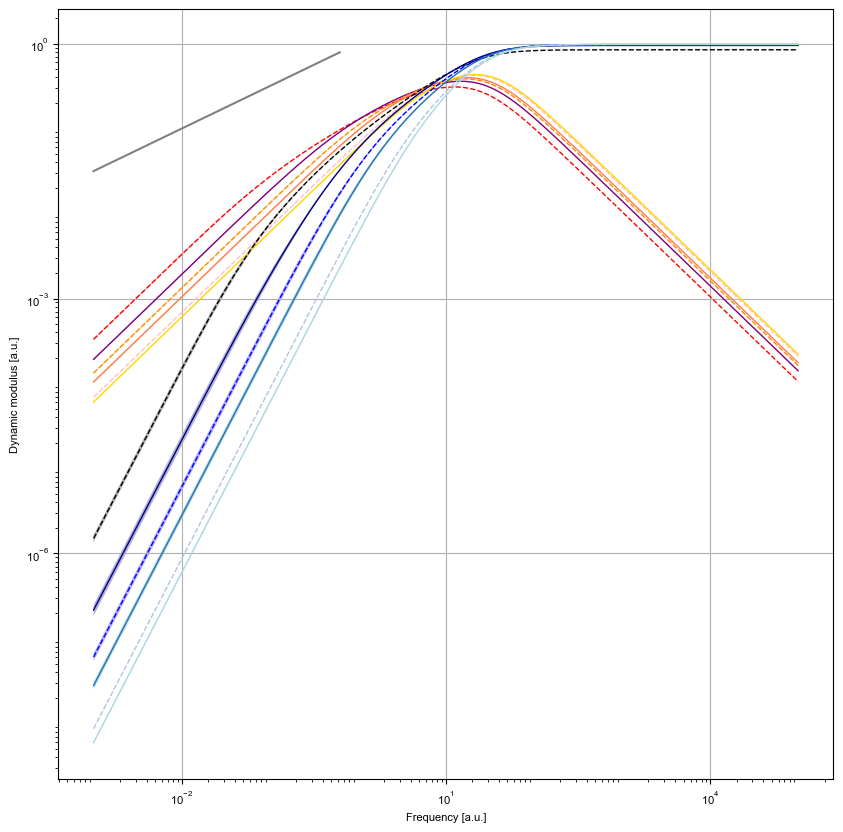

In [13]:
fig=plt.figure(figsize=(10,10))
#fig=plt.figure(figsize=(6/2.54,6/2.54))

ax1 = fig.add_subplot(111)
"""
1: ub rate 0.005
2: ub rate 0.0005
7: ub rate 0.0001
8: ub rate 0.00005
5: ub rate 0.000005
0: ub rate 0"""

labels_storage1=[r"$G',~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G',~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'',~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['#D3D3D3', '#A9A9A9', '#696969', '#2F4F4F']
color_loss_list1=['#FF6666', '#FF0000', '#8B0000', '#4B0000']

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']


fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]

#for i in range(len(storage_mod_all_sims_all[:4])):
lii=0
for i in [1,2,3,4,5,6]:
    alpha1=1 -lii/5

    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all_hydr[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr[i])))
    
    min_loss_mod_all_sims_ex1=np.min(loss_mod_all_sims_all_hydr[i],axis=0)
    max_loss_mod_all_sims_ex1=np.max(loss_mod_all_sims_all_hydr[i],axis=0)
    
    line1=ax1.errorbar(omega_t_sim1_hydr[::],mean_loss_mod_all_sims_ex1[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt=fmt_loss_list1[lii],linewidth=1)
    ax1.fill_between(omega_t_sim1_hydr[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::] ,facecolor=color_loss_list1[lii],alpha=0.3)
    #ax1.fill_between(omega_t_sim1_hydr[::], max_loss_mod_all_sims_ex1[::], min_loss_mod_all_sims_ex1[::] ,facecolor=color_loss_list1[lii],alpha=0.3)

    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1

lii=0
for i in [1,2,3,4,5,6]:

    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all_hydr[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr[i])))

    min_storage_mod_all_sims_ex1=np.min(storage_mod_all_sims_all_hydr[i],axis=0)
    max_storage_mod_all_sims_ex1=np.max(storage_mod_all_sims_all_hydr[i],axis=0)
    
    line1=ax1.errorbar(omega_t_sim1_hydr[::],mean_storage_mod_all_sims_ex1[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt=fmt_storage_list1[lii],linewidth=1)
    ax1.fill_between(omega_t_sim1_hydr[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
    #ax1.fill_between(omega_t_sim1_hydr[::], max_storage_mod_all_sims_ex1[::], min_storage_mod_all_sims_ex1[::] ,facecolor=color_storage_list1[lii],alpha=0.3)

    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1
ax1.errorbar(omega_t_sim1_hydr[:350],omega_t_sim1_hydr[:350]**0.5 , label=r"$\omega^{0.5}$",color="grey")
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_hydr_oseen_r_4_7_1b.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

<Figure size 1000x1000 with 0 Axes>

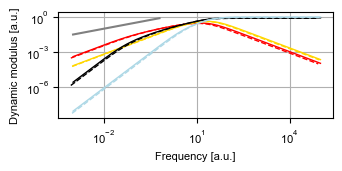

In [14]:
fig=plt.figure(figsize=(10,10))
#fig=plt.figure(figsize=(9/2.54,9/2.54))
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#fig=plt.figure(figsize=(9,9))
fig=plt.figure(figsize=(9/2.54,3.5/2.54))

ax1 = fig.add_subplot(111)
"""
1: ub rate 0.005
2: ub rate 0.0005
7: ub rate 0.0001
8: ub rate 0.00005
5: ub rate 0.000005
0: ub rate 0"""

labels_storage1=[r"$G',~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G',~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'',~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['#D3D3D3', '#A9A9A9', '#696969', '#2F4F4F']
color_loss_list1=['#FF6666', '#FF0000', '#8B0000', '#4B0000']

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']

color_storage_list1=['black',"lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red","gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']


fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]



#for i in range(len(storage_mod_all_sims_all[:4])):
lii=0
for i in [1,6]:
    alpha1=1 -lii/5

    #no hydr
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))

    line1=ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt="-",linewidth=1)
    ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::] ,facecolor=color_loss_list1[lii],alpha=0.3)
   
    #hydr

    mean_loss_mod_all_sims_ex1_hydr=np.mean(loss_mod_all_sims_all_hydr[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1_hydr=np.std(loss_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr[i])))
    mean_storage_mod_all_sims_ex1_hydr=np.mean(storage_mod_all_sims_all_hydr[i],axis=0)
    std_e_storage_mod_all_sims_ex1_hydr=np.std(storage_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr[i])))

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1_hydr, y1=mean_storage_mod_all_sims_ex1_hydr, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_hydr_shift=np.array(omega_t_sim1_hydr)*omega_inters_target_1/omega_inters_1
    mean_storage_mod_all_sims_ex1_hydr_shift=np.array(mean_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_storage_mod_all_sims_ex1_hydr_shift=np.array(std_e_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    mean_loss_mod_all_sims_ex1_hydr_shift=np.array(mean_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_loss_mod_all_sims_ex1_hydr_shift=np.array(std_e_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    
    
    line1_hydr=ax1.errorbar(omega_t_sim1_hydr_shift[::],mean_loss_mod_all_sims_ex1_hydr_shift[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt="--",linewidth=1)
    ax1.fill_between(omega_t_sim1_hydr_shift[::], mean_loss_mod_all_sims_ex1_hydr_shift[::] + std_e_loss_mod_all_sims_ex1_hydr_shift[::], mean_loss_mod_all_sims_ex1_hydr_shift[::] - std_e_loss_mod_all_sims_ex1_hydr_shift[::] ,facecolor=color_loss_list1[lii],alpha=0.3)
 
    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1

lii=0
for i in [1,6]:

    #no hydr
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))
    
    line1=ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt="-",linewidth=1)
    ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
   
    #hydr
    mean_loss_mod_all_sims_ex1_hydr=np.mean(loss_mod_all_sims_all_hydr[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1_hydr=np.std(loss_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr[i])))
    mean_storage_mod_all_sims_ex1_hydr=np.mean(storage_mod_all_sims_all_hydr[i],axis=0)
    std_e_storage_mod_all_sims_ex1_hydr=np.std(storage_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr[i])))

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1_hydr, y1=mean_storage_mod_all_sims_ex1_hydr, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_hydr_shift=np.array(omega_t_sim1_hydr)*omega_inters_target_1/omega_inters_1
    mean_storage_mod_all_sims_ex1_hydr_shift=np.array(mean_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1 #+omega_t_sim1*8*10**-3 #*0.05
    std_e_storage_mod_all_sims_ex1_hydr_shift=np.array(std_e_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    mean_loss_mod_all_sims_ex1_hydr_shift=np.array(mean_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_loss_mod_all_sims_ex1_hydr_shift=np.array(std_e_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    
    
    line1_hydr=ax1.errorbar(omega_t_sim1_hydr_shift[::],mean_storage_mod_all_sims_ex1_hydr_shift[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt="--",linewidth=1)
    ax1.fill_between(omega_t_sim1_hydr_shift[::], mean_storage_mod_all_sims_ex1_hydr_shift[::] + std_e_storage_mod_all_sims_ex1_hydr_shift[::], mean_storage_mod_all_sims_ex1_hydr_shift[::] - std_e_storage_mod_all_sims_ex1_hydr_shift[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
    
    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1
ax1.errorbar(omega_t_sim1[:350],omega_t_sim1[:350]**0.5 , label=r"$\omega^{0.5}$",color="grey")
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_comp_hydr_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

<Figure size 1000x1000 with 0 Axes>

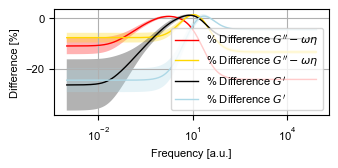

In [139]:
fig=plt.figure(figsize=(10,10))
#fig=plt.figure(figsize=(9/2.54,9/2.54))
fig=plt.figure(figsize=(9/2.54,3.5/2.54))

ax1 = fig.add_subplot(111)
"""
1: ub rate 0.005
2: ub rate 0.0005
7: ub rate 0.0001
8: ub rate 0.00005
5: ub rate 0.000005
0: ub rate 0"""

labels_storage1=[r"$G',~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G',~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'',~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['#D3D3D3', '#A9A9A9', '#696969', '#2F4F4F']
color_loss_list1=['#FF6666', '#FF0000', '#8B0000', '#4B0000']

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']

color_storage_list1=['black',"lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red","gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']



fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]

#for i in range(len(storage_mod_all_sims_all[:4])):
lii=0
for i in [1,6]:
    alpha1=1 -lii/5

    #no hydr
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))

    
    #line1=ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt=fmt_loss_list1[lii],linewidth=1)
    #ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::] ,facecolor=color_loss_list1[lii],alpha=0.3)
   
    #hydr

    mean_loss_mod_all_sims_ex1_hydr=np.mean(loss_mod_all_sims_all_hydr[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1_hydr=np.std(loss_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr[i])))
    mean_storage_mod_all_sims_ex1_hydr=np.mean(storage_mod_all_sims_all_hydr[i],axis=0)
    std_e_storage_mod_all_sims_ex1_hydr=np.std(storage_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr[i])))

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1_hydr, y1=mean_storage_mod_all_sims_ex1_hydr, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_hydr_shift=np.array(omega_t_sim1_hydr)*omega_inters_target_1/omega_inters_1
    mean_storage_mod_all_sims_ex1_hydr_shift=np.array(mean_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_storage_mod_all_sims_ex1_hydr_shift=np.array(std_e_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    mean_loss_mod_all_sims_ex1_hydr_shift=np.array(mean_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_loss_mod_all_sims_ex1_hydr_shift=np.array(std_e_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1

    #interpolate to same freq values:
    mean_loss_mod_all_sims_ex1_hydr_shift_interp=np.interp(omega_t_sim1,omega_t_sim1_hydr_shift,mean_loss_mod_all_sims_ex1_hydr_shift)
    std_e_loss_mod_all_sims_ex1_hydr_shift_interp=np.interp(omega_t_sim1,omega_t_sim1_hydr_shift,std_e_loss_mod_all_sims_ex1_hydr_shift)
    
    #line1_hydr=ax1.errorbar(omega_t_sim1[:-10:],mean_loss_mod_all_sims_ex1_hydr_shift_interp[:-10:],label=labels_loss1[lii],color=color_loss_list1[lii],fmt=fmt_loss_list1[lii],linewidth=1)
    #ax1.fill_between(omega_t_sim1_hydr_shift[::], mean_loss_mod_all_sims_ex1_hydr_shift[::] + std_e_loss_mod_all_sims_ex1_hydr_shift[::], mean_loss_mod_all_sims_ex1_hydr_shift[::] - std_e_loss_mod_all_sims_ex1_hydr_shift[::] ,facecolor=color_loss_list1[lii],alpha=0.3)

    #diff
    #line1_hydr=ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1_hydr_shift_interp[::]-mean_loss_mod_all_sims_ex1[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt=fmt_loss_list1[lii],linewidth=1)

    #perc diff might have to cut off some terminal values due to issues with interpolation
    perc_diff_loss=(mean_loss_mod_all_sims_ex1_hydr_shift_interp[::]-mean_loss_mod_all_sims_ex1[::])/mean_loss_mod_all_sims_ex1[::]*100
    std_e_perc_diff_loss=np.sqrt((std_e_loss_mod_all_sims_ex1_hydr_shift_interp/mean_loss_mod_all_sims_ex1)**2 + (mean_loss_mod_all_sims_ex1_hydr_shift_interp*std_e_loss_mod_all_sims_ex1/mean_loss_mod_all_sims_ex1**2)**2)*100
    line1_hydr=ax1.errorbar(omega_t_sim1[:-10:],perc_diff_loss[:-10:],label=r"% Difference $G''-\omega \eta$",color=color_loss_list1[lii],fmt="-",linewidth=1)
    ax1.fill_between(omega_t_sim1[:-10:], perc_diff_loss[:-10:] + std_e_perc_diff_loss[:-10:], perc_diff_loss[:-10:] - std_e_perc_diff_loss[:-10:] ,facecolor=color_loss_list1[lii],alpha=0.3)

    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1

lii=0
for i in [1,6]:

    #no hydr
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))
    
    #line1=ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt=fmt_storage_list1[lii],linewidth=1)
    #ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
   
    #hydr
    mean_loss_mod_all_sims_ex1_hydr=np.mean(loss_mod_all_sims_all_hydr[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1_hydr=np.std(loss_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr[i])))
    mean_storage_mod_all_sims_ex1_hydr=np.mean(storage_mod_all_sims_all_hydr[i],axis=0)
    std_e_storage_mod_all_sims_ex1_hydr=np.std(storage_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr[i])))

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1_hydr, y1=mean_storage_mod_all_sims_ex1_hydr, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_hydr_shift=np.array(omega_t_sim1_hydr)*omega_inters_target_1/omega_inters_1
    mean_storage_mod_all_sims_ex1_hydr_shift=np.array(mean_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_storage_mod_all_sims_ex1_hydr_shift=np.array(std_e_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    mean_loss_mod_all_sims_ex1_hydr_shift=np.array(mean_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_loss_mod_all_sims_ex1_hydr_shift=np.array(std_e_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1

    #interpolate to same freq values:
    mean_storage_mod_all_sims_ex1_hydr_shift_interp=np.interp(omega_t_sim1,omega_t_sim1_hydr_shift,mean_storage_mod_all_sims_ex1_hydr_shift)
    std_e_storage_mod_all_sims_ex1_hydr_shift_interp=np.interp(omega_t_sim1,omega_t_sim1_hydr_shift,std_e_storage_mod_all_sims_ex1_hydr_shift)
    #line1_hydr=ax1.errorbar(omega_t_sim1[:-10:],mean_storage_mod_all_sims_ex1_hydr_shift_interp[:-10:],label=labels_storage1[lii],color=color_storage_list1[lii],fmt=fmt_storage_list1[lii],linewidth=1)
    #ax1.fill_between(omega_t_sim1_hydr_shift[::], mean_storage_mod_all_sims_ex1_hydr_shift[::] + std_e_storage_mod_all_sims_ex1_hydr_shift[::], mean_storage_mod_all_sims_ex1_hydr_shift[::] - std_e_storage_mod_all_sims_ex1_hydr_shift[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
    
    #diff
    #line1_hydr=ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1_hydr_shift_interp[::]-mean_storage_mod_all_sims_ex1[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt=fmt_storage_list1[lii],linewidth=1)

    #perc diff
    perc_diff_storage=(mean_storage_mod_all_sims_ex1_hydr_shift_interp[::]-mean_storage_mod_all_sims_ex1[::])/mean_storage_mod_all_sims_ex1[::] *100
    std_e_perc_diff_storage=np.sqrt((std_e_storage_mod_all_sims_ex1_hydr_shift_interp/mean_storage_mod_all_sims_ex1)**2 + (mean_storage_mod_all_sims_ex1_hydr_shift_interp*std_e_storage_mod_all_sims_ex1/mean_storage_mod_all_sims_ex1**2)**2) *100

    line1_hydr=ax1.errorbar(omega_t_sim1[:-10:],perc_diff_storage[:-10:],label=r"% Difference $G'$",color=color_storage_list1[lii],fmt="-",linewidth=1)
    ax1.fill_between(omega_t_sim1[:-10:], perc_diff_storage[:-10:] + std_e_perc_diff_storage[:-10:], perc_diff_storage[:-10:] - std_e_perc_diff_storage[:-10:] ,facecolor=color_storage_list1[lii],alpha=0.3)

    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1
#ax1.errorbar(omega_t_sim1[:350],omega_t_sim1[:350]**0.5 , label=r"$\omega^{0.5}$",color="grey")
fs1=8
plt.xscale("log")
#plt.yscale("log")
plt.grid()

plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Difference [%]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/differences_moduli_hydr_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [140]:
perc_diff_storage[0]

-24.60492936158624

<Figure size 1000x1000 with 0 Axes>

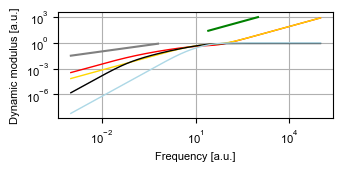

In [16]:
fig=plt.figure(figsize=(10,10))
#fig=plt.figure(figsize=(9/2.54,9/2.54))
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#fig=plt.figure(figsize=(9,9))
fig=plt.figure(figsize=(9/2.54,3.5/2.54))

ax1 = fig.add_subplot(111)
"""
1: ub rate 0.005
2: ub rate 0.0005
7: ub rate 0.0001
8: ub rate 0.00005
5: ub rate 0.000005
0: ub rate 0"""

labels_storage1=[r"$G',~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G',~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'',~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['#D3D3D3', '#A9A9A9', '#696969', '#2F4F4F']
color_loss_list1=['#FF6666', '#FF0000', '#8B0000', '#4B0000']

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']

color_storage_list1=['black',"lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red","gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']


fmt_storage_list1=["-","-","--","-","--","-","--","-"]
fmt_loss_list1=["-","-","--","-","--","-","--","-"]



#for i in range(len(storage_mod_all_sims_all[:4])):
lii=0
for i in [1,6]:
    alpha1=1 -lii/5

    #hydr

    mean_loss_mod_all_sims_ex1_hydr=np.mean(loss_mod_all_sims_all_hydr[i],axis=0) +omega_t_sim1_hydr*8*10**-3
    std_e_loss_mod_all_sims_ex1_hydr=np.std(loss_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr[i])))
    mean_storage_mod_all_sims_ex1_hydr=np.mean(storage_mod_all_sims_all_hydr[i],axis=0)
    std_e_storage_mod_all_sims_ex1_hydr=np.std(storage_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr[i])))
 
    line1_hydr=ax1.errorbar(omega_t_sim1_hydr[::],mean_loss_mod_all_sims_ex1_hydr[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt="-",linewidth=1)
    ax1.fill_between(omega_t_sim1_hydr[::], mean_loss_mod_all_sims_ex1_hydr[::] + std_e_loss_mod_all_sims_ex1_hydr[::], mean_loss_mod_all_sims_ex1_hydr[::] - std_e_loss_mod_all_sims_ex1_hydr[::] ,facecolor=color_loss_list1[lii],alpha=0.3)

    lii=lii+1

lii=0
for i in [1,6]:

    #hydr
    mean_loss_mod_all_sims_ex1_hydr=np.mean(loss_mod_all_sims_all_hydr[i],axis=0) +omega_t_sim1_hydr*8*10**-3
    std_e_loss_mod_all_sims_ex1_hydr=np.std(loss_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr[i])))
    mean_storage_mod_all_sims_ex1_hydr=np.mean(storage_mod_all_sims_all_hydr[i],axis=0)
    std_e_storage_mod_all_sims_ex1_hydr=np.std(storage_mod_all_sims_all_hydr[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr[i])))

    line1_hydr=ax1.errorbar(omega_t_sim1_hydr[::],mean_storage_mod_all_sims_ex1_hydr[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt="-",linewidth=1)
    ax1.fill_between(omega_t_sim1_hydr[::], mean_storage_mod_all_sims_ex1_hydr[::] + std_e_storage_mod_all_sims_ex1_hydr[::], mean_storage_mod_all_sims_ex1_hydr[::] - std_e_storage_mod_all_sims_ex1_hydr[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])

    lii=lii+1
ax1.errorbar(omega_t_sim1[:350],omega_t_sim1[:350]**0.5 , label=r"$\omega^{0.5}$",color="grey")

ax1.errorbar(omega_t_sim1[550:750],omega_t_sim1[550:750]**1 , label=r"$\omega^{0.5}$",color="green")

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0,10**3],fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_hydr_with_visc_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [144]:
print(perc_diff_storage[0])
print(std_e_perc_diff_storage[0])

-24.60492936158624
4.713128696721861


(0.001, 0.1)

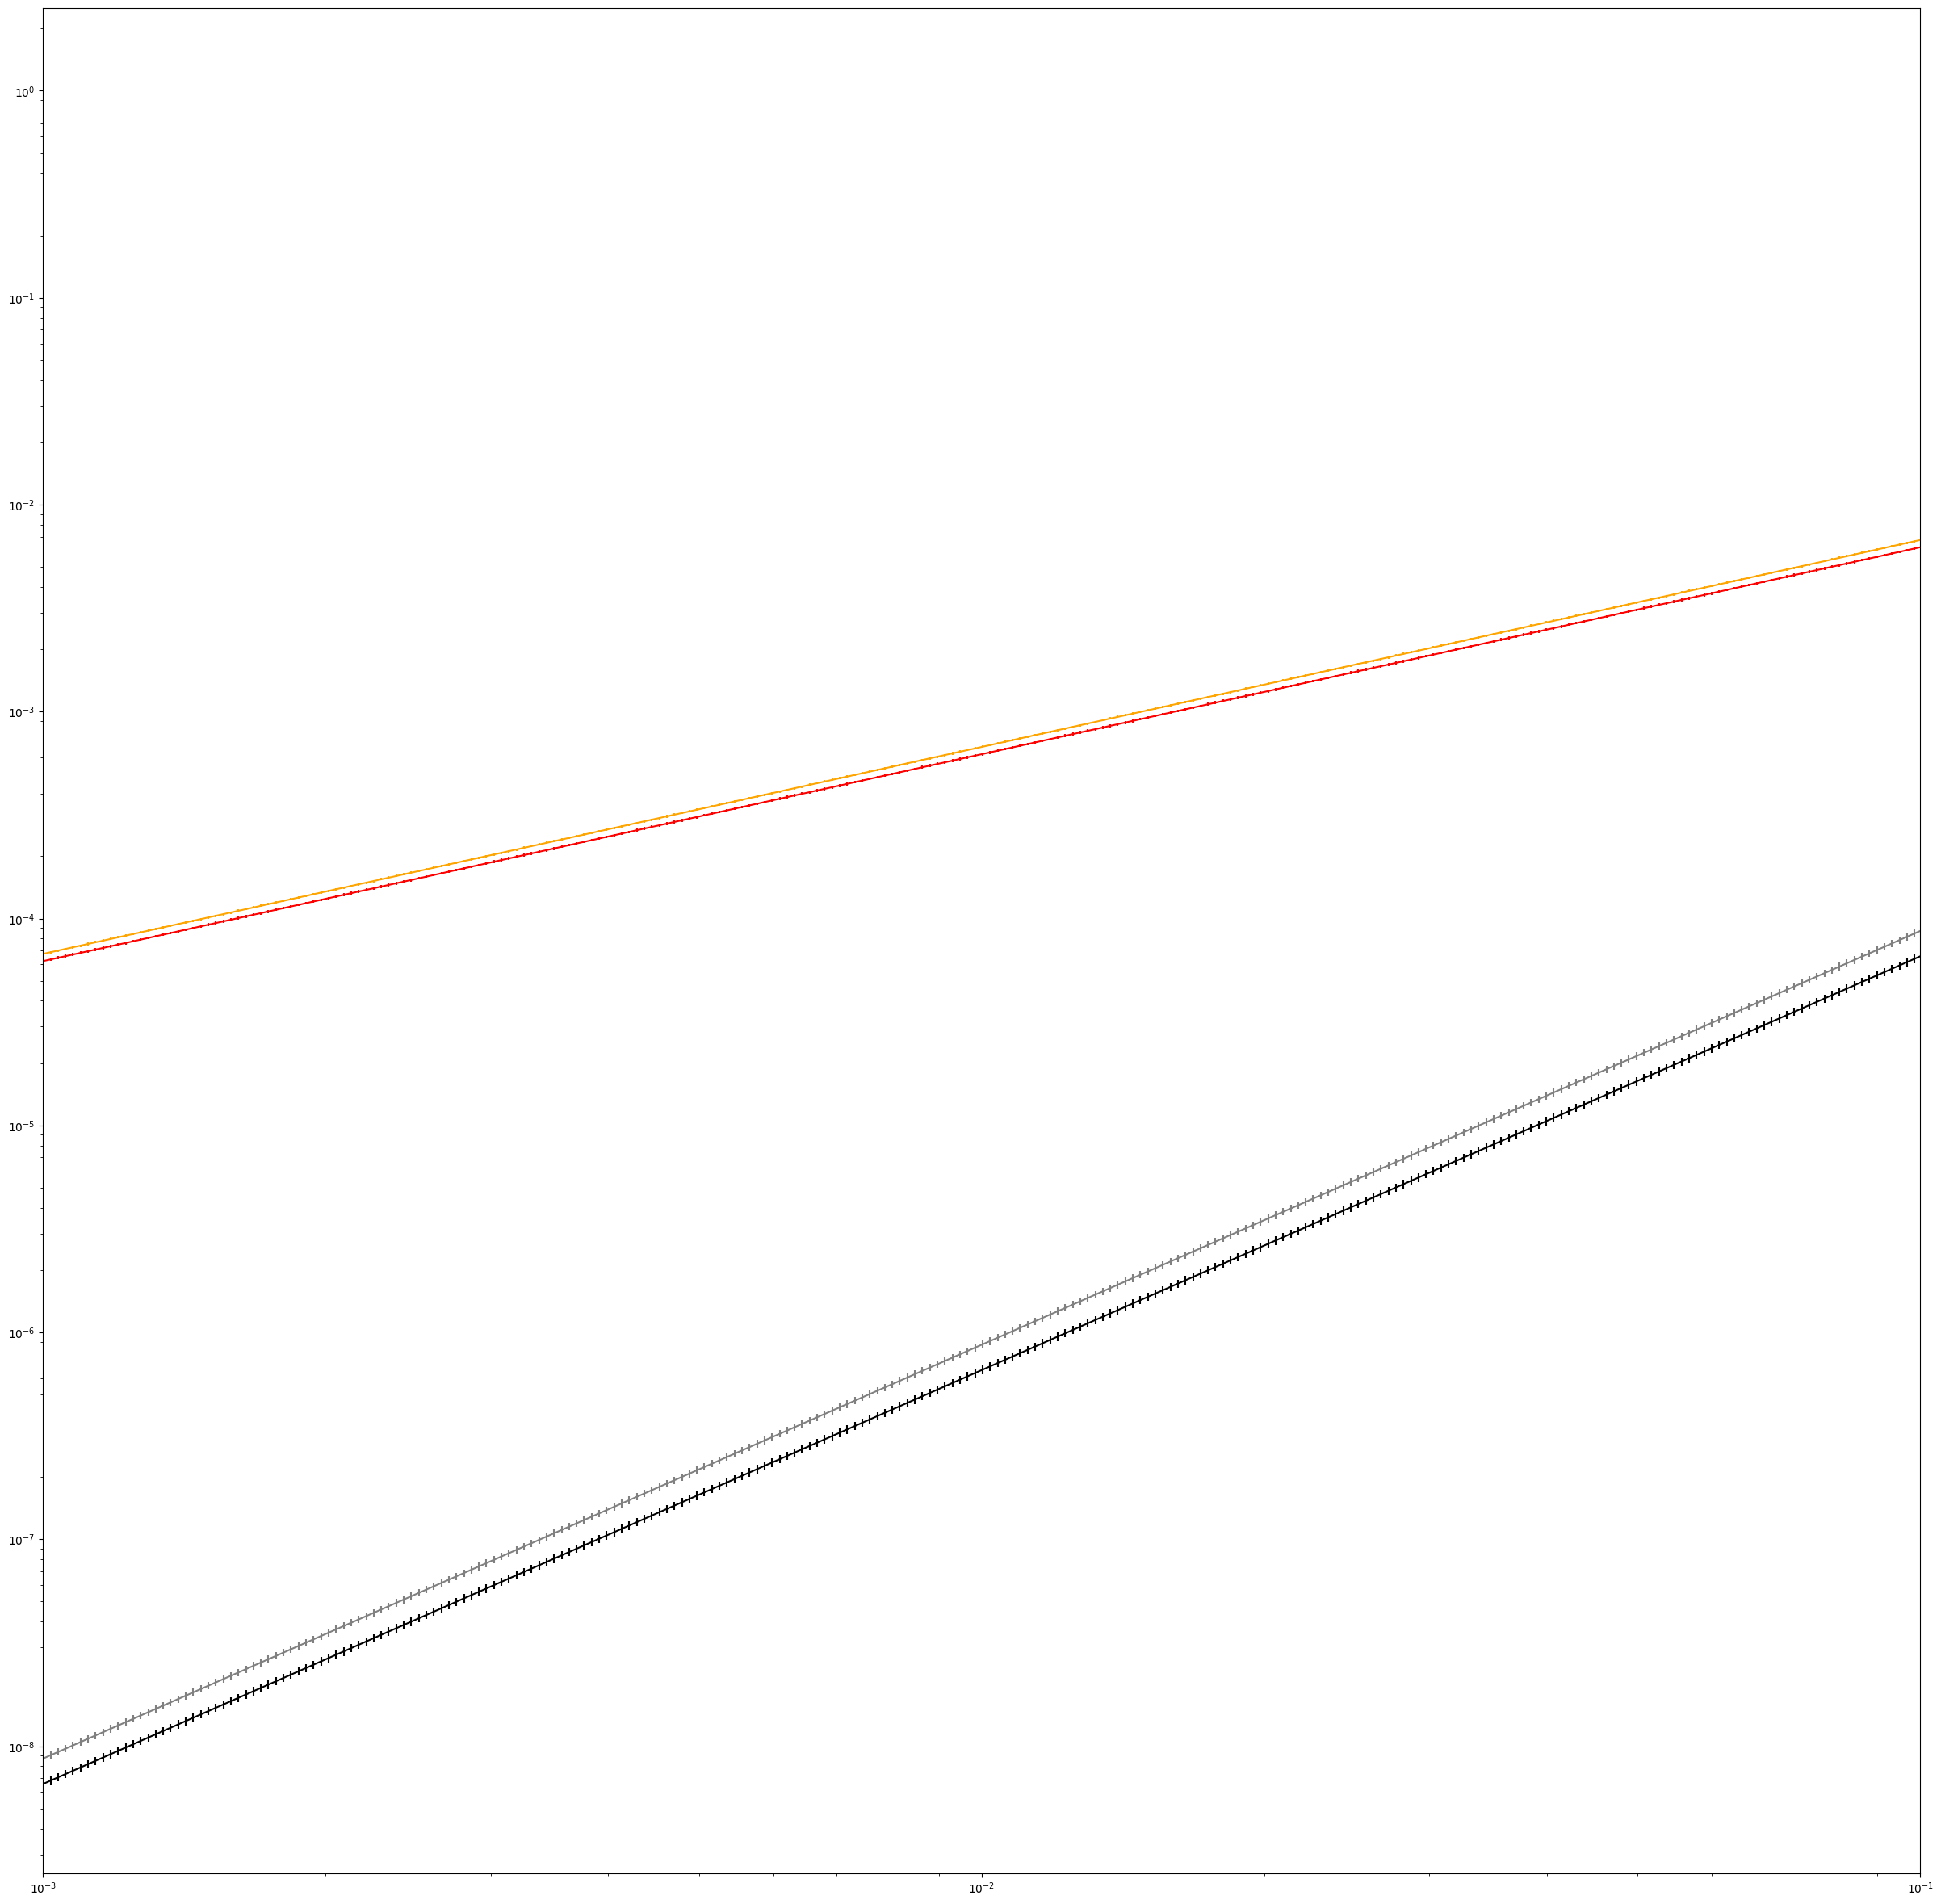

In [44]:
fig=plt.figure(figsize=(30,30))

plt.errorbar(omega_t_sim1,mean_loss_mod_all_sims_ex1_hydr_shift_interp,yerr=std_e_loss_mod_all_sims_ex1_hydr_shift_interp,color="red")
plt.errorbar(omega_t_sim1,mean_loss_mod_all_sims_ex1,yerr=std_e_loss_mod_all_sims_ex1,color="orange")


plt.errorbar(omega_t_sim1,mean_storage_mod_all_sims_ex1_hydr_shift_interp,yerr=std_e_storage_mod_all_sims_ex1_hydr_shift_interp,color="black")

plt.errorbar(omega_t_sim1,mean_storage_mod_all_sims_ex1,yerr=std_e_storage_mod_all_sims_ex1,color="grey")

plt.yscale("log")
plt.xscale("log")
plt.xlim(10**-3,10**-1)

In [12]:
%%time
#calculate average distance between linked nanomotif centers from simulations

omega_t_sim1_hydr=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1_hydr=np.geomspace(10**-2,10**3,10**2)

#use skip 5250 for cont 2 read in , use skip 11250 for 6e7 run (soft with r_ub=0)
#folder_names_dyn_mod=[folder_names_all_ex[e] for e in [8,2]]  #8,2
#time_skip_dyn_mod=[5250,2250] #,2250]

folder_names_dyn_mod=[folder_names_all_ex[e] for e in [0,1,2,3,4,5,8,9]]
time_skip_dyn_mod=[2250,2250,2250,2250,2250,2250,5250,11250]


#folder_names_dyn_mod=[["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]]
#time_skip_dyn_mod=[11250]

#print(folder_names_dyn_mod)
input_dyn_mod=[]
box_size=[69.7,69.7,69.7]
eta=8*10**-3
a=4.7
t_r_avg_f=-10
t_r_avg_l=10

for i in range(len(folder_names_dyn_mod)):
    input_dyn_mod.append((folder_names_dyn_mod[i],omega_t_sim1_hydr,t_sim1_hydr,1,1,1,1,1,15,time_skip_dyn_mod[i],box_size,eta,a,t_r_avg_f,t_r_avg_l))

with ThreadPoolExecutor(max_workers=18) as executor:
    results_dist = list(executor.map(lambda args: avg_conn_mat_dist(*args), input_dyn_mod))



calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  0
calc. for sim  1
calc. for sim  1
calc. for sim  1
calc. for sim  1
calc. for sim  1
calc. for sim  1
calc. for sim  1
calc. for sim  1
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  2
calc. for sim  3
calc. for sim  3
calc. for sim  3
calc. for sim  3
calc. for sim  3
calc. for sim  3
calc. for sim  3
calc. for sim  3
calc. for sim  4
calc. for sim  4
calc. for sim  4
calc. for sim  4
calc. for sim  4
calc. for sim  4
calc. for sim  4
calc. for sim  4
CPU times: user 2min 19s, sys: 22.8 s, total: 2min 42s
Wall time: 5min 22s


In [19]:
len(results_dist[6])

5

In [18]:

results_dist_fl = [element for innerList in results_dist[6] for element in innerList]

results_dist_fl2=[element for innerList in results_dist_fl for element in innerList]
print(np.mean(results_dist_fl2))
print(np.std(results_dist_fl2))

15.376267697154725
0.7310309694180092


# Try method on existing 3-armed model simulation

In [12]:
traj_load1_3arm=readdy.Trajectory("/mnt/d/D_phd/Y_shaped_nanomotifs_networking/sim_opt_Y_motif_rheo_high_conn_1/prod_cont_checkpoint_0/y_xma_opt_prod_cont_rheo_high_conn_1_0.h5")

times_load1_3arm,types_load1_3arm,ids_load1_3arm,part_positions_load1_3arm=traj_load1_3arm.read_observable_particles()
time_pt_load1_3arm, counts_pt_load1_3arm = traj_load1_3arm.read_observable_number_of_particles()
#part_pos_eq=part_positions

time_e_load1_3arm, energy_load1_3arm=traj_load1_3arm.read_observable_energy()

time_obs_top_load1_3arm,obs_top_load1_3arm=traj_load1_3arm.read_observable_topologies()

In [243]:
print(traj_load1_3arm.box_size)

[82.11 82.11 82.11]


--- DIAGNOSTIC REPORT ---
Total Nodes (N): 102
Rank of Z: 100 (Expected 101 for connected graph)
Disconnected components found: 2
-------------------------
Rank of H: 102 (Expected 102)
Condition Number of H: 2.97e+01
-------------------------
Non-zero evals (Direct H*Z): 100
Non-zero evals (Symmetric):  100

CONCLUSION: System is numerically consistent.
CPU times: user 6.72 s, sys: 3.48 s, total: 10.2 s
Wall time: 533 ms


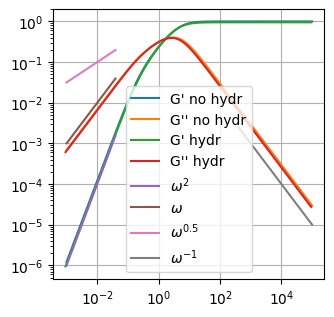

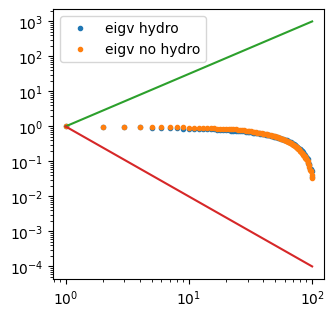

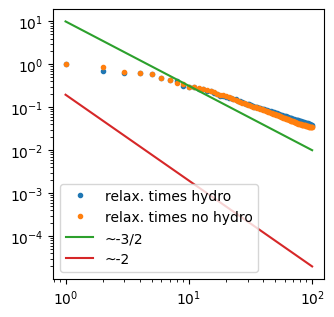

In [69]:
%%time
# parameter estimates:
#hydr radius [nm]
box_size=[69.72,69.72,69.72]
a_u=4.7*3/4#4.5#4.5#4.7#7.5#7#7#4.7 #10 #100 #4.7 #4.7 #15

system_temperature=1 #273.15 + 40  #293

kbt=1 #system_temperature*1.380649*10**-23

visc_T_sys=10**-6 #visc_T(system_temperature)

#eta=

b_u=1 #20 #[m] #Kuhn length, treating rough diameter of sphere around one X-motif as Kuhn length

zeta_u=1 #6*np.pi * visc_T_sys *b_u

k_u=1 #1.380649*10**-23 #[J/K]
T_u=1 #system_temperature  #[K]
phi_u=1#(100  * 4/3 * np.pi * (b_u/2)**3)/69.7**3 #[1] #Volume fraction occupied by polymer, fraction occopied by spheres with Kuhn length

omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #np.geomspace(10**-4,10**4,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)

for visc_T_sys in [12*10**-3]: #8*10**-3 #variying this shifts hydr curves to left or right, without chaning the scaling
    
    #no hydr:
    conn_mat_test_no_hydr_1, eigv_test_no_hydro_1 =get_conn_mat_eigv_1(time_sel=-1,obs_top=obs_top_load1_3arm,edges_centre=3,edges_linker=3)
    eigv_test_no_hydro_1=[e for e in eigv_test_no_hydro_1 if e>10**-9]
    eigv_test_no_hydro_1=np.array(eigv_test_no_hydro_1)
    #with hydr:
    conn_mat_test_hydr_1, eigv_test_hydro_1 =get_conn_mat_eigv_hydro2(time_sel=-10,obs_top=obs_top_load1_3arm,part_pos=part_positions_load1_3arm,edges_centre=3,edges_linker=3,box_size=box_size, eta=visc_T_sys, a=a_u,t_r_avg_f=-20,t_r_avg_l=None)
    #conn_mat_test_hydr_1, eigv_test_hydro_1 =get_conn_mat_eigv_hydro1(time_sel=-1,obs_top=obs_top_mech_x,part_pos=part_positions_mech_x,edges_centre=4,edges_linker=3,box_size=box_size, eta=visc_T_sys, a=a_u)
    eigv_test_hydro_1_all=eigv_test_hydro_1
    eigv_test_hydro_1=[e for e in eigv_test_hydro_1 if e>10**-9]
    eigv_test_hydro_1=np.array(eigv_test_hydro_1)
    
    
    ###########
    ###########
    ###########
    tau_no_hydr=np.array(1/eigv_test_no_hydro_1)
    
    sm_no_hydr=storage_mod(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_no_hydr,omega=omega_t_sim1)
    lm_no_hydr=loss_mod_deref(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_no_hydr,omega=omega_t_sim1)
    ###########
    ###########
    ###########
    
    tau_hydr=np.array(1/eigv_test_hydro_1)
    sm_hydr=storage_mod(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_hydr,omega=omega_t_sim1)
    lm_hydr=loss_mod_deref(phi=phi_u,k=k_u,T=T_u,N=100,b=b_u,tau=tau_hydr,omega=omega_t_sim1)


    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=sm_no_hydr, x2=omega_t_sim1, y2=lm_no_hydr)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
    
    
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1, y1=sm_hydr, x2=omega_t_sim1, y2=lm_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_shift=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_1
    sm_hydr_shift=np.array(sm_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    lm_hydr_shift=np.array(lm_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    
    
    fig=plt.figure(figsize=(3.5,3.5))
    ax1 = fig.add_subplot(111)
    
    visc_eff=0#10**-3
    
    ax1.errorbar(omega_t_sim1,sm_no_hydr,label="G' no hydr")
    ax1.errorbar(omega_t_sim1,lm_no_hydr+omega_t_sim1*visc_eff,label="G'' no hydr")
    
    #ax1.errorbar(omega_t_sim1,sm_hydr,label="G' hydr")
    #ax1.errorbar(omega_t_sim1,lm_hydr+omega_t_sim1*visc_eff,label="G'' hydr")
    
    ax1.errorbar(omega_t_sim1_shift,sm_hydr_shift,label="G' hydr")
    ax1.errorbar(omega_t_sim1_shift,lm_hydr_shift+omega_t_sim1_shift*visc_eff,label="G'' hydr")

    ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    
    plt.legend()
    
    
    plt.yscale("log")
    plt.xscale("log")
    plt.grid()
    
    
    fig=plt.figure(figsize=(3.5,3.5))
    ax1 = fig.add_subplot(111)
    plt.errorbar(np.arange(1,len(eigv_test_hydro_1)+1),eigv_test_hydro_1[::-1]/eigv_test_hydro_1[::-1][0],fmt=".",label="eigv hydro")
    
    plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1),np.sort(eigv_test_no_hydro_1)[::-1]/np.sort(eigv_test_no_hydro_1)[::-1][0],fmt=".",label="eigv no hydro")
    plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1) ,np.arange(1,len(eigv_test_no_hydro_1)+1)**(3/2)   )
    plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1) ,1/(np.arange(1,len(eigv_test_no_hydro_1)+1)**2)   )

    plt.legend()
    
    
    plt.yscale("log")
    plt.xscale("log")

    fig=plt.figure(figsize=(3.5,3.5))
    ax1 = fig.add_subplot(111)

    plt.errorbar(np.arange(1,len(tau_hydr)+1),tau_hydr/tau_hydr[0],label="relax. times hydro",fmt=".")
    plt.errorbar(np.arange(1,len(tau_no_hydr)+1),np.sort(tau_no_hydr)[::-1]/np.sort(tau_no_hydr)[::-1][0],label="relax. times no hydro",fmt=".")
    plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1) ,np.arange(1,len(eigv_test_no_hydro_1)+1)**(-3/2)*10 ,label="~-3/2"  )
    plt.errorbar(np.arange(1,len(eigv_test_no_hydro_1)+1) ,1/(np.arange(1,len(eigv_test_no_hydro_1)+1)**2)/np.sort(tau_no_hydr)[::-1][0] ,label="~-2"  )
    plt.legend()
    
    plt.yscale("log")
    plt.xscale("log")


In [17]:
%%time
#calculate G' and G'' from simulations with HI

omega_t_sim1_hydr=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1_hydr=np.geomspace(10**-2,10**3,10**2)

#use skip 5250 for cont 2 read in , use skip 11250 for 6e7 run (soft with r_ub=0)
#folder_names_dyn_mod=[folder_names_all_ex[e] for e in [8,2]]  #8,2
#time_skip_dyn_mod=[5250,2250] #,2250]

# opt,r_b=0.1 r_ub=0.000002
folder_name_ex3=["/mnt/d/D_phd/Y_shaped_nanomotifs_networking/sim_opt_Y_motif_rheo_high_conn_1/prod_cont_checkpoint_"+str(e)+"/y_xma_opt_prod_cont_rheo_high_conn_1_"+str(e)+".h5" for e in [0,1,2,3,4]]


folder_names_dyn_mod=[folder_name_ex3]
time_skip_dyn_mod=[2250]


#folder_names_dyn_mod=[["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]]
#time_skip_dyn_mod=[11250]

#print(folder_names_dyn_mod)
input_dyn_mod=[]
box_size=[69.72,69.72,69.72]
eta=12*10**-3
a=4.7*0.75   #4.5
t_r_avg_f=-10
t_r_avg_l=10

for i in range(len(folder_names_dyn_mod)):
    input_dyn_mod.append((folder_names_dyn_mod[i],omega_t_sim1_hydr,t_sim1_hydr,1,1,1,1,1,15,time_skip_dyn_mod[i],box_size,eta,a,t_r_avg_f,t_r_avg_l))

with ThreadPoolExecutor(max_workers=18) as executor:
    results_dyn_mod_hydr_3arm = list(executor.map(lambda args: avg_moduli_hydr_3_3arm(*args), input_dyn_mod))


calc. for sim  0
calc. for sim  1
calc. for sim  2
calc. for sim  3
calc. for sim  4
CPU times: user 11min 41s, sys: 1min 52s, total: 13min 33s
Wall time: 1min 11s


In [18]:
# split results in storage, loss and cross links
storage_mod_all_sims_all_hydr_3arm=[results_dyn_mod_hydr_3arm[e][0] for e in range(len(results_dyn_mod_hydr_3arm))]
loss_mod_all_sims_all_hydr_3arm=[results_dyn_mod_hydr_3arm[e][1] for e in range(len(results_dyn_mod_hydr_3arm))]
cross_links_all_sims_all_hydr_3arm=[results_dyn_mod_hydr_3arm[e][2] for e in range(len(results_dyn_mod_hydr_3arm))]

Intersection: omega: 11.170342909032309 dynamic mod. 0.388825238986508


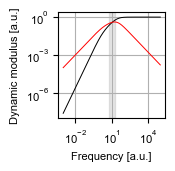

In [72]:


#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
for i in range(len(storage_mod_all_sims_all_hydr_3arm)):
    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig.add_subplot(111)
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all_hydr_3arm[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all_hydr_3arm[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr_3arm[i])))
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all_hydr_3arm[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all_hydr_3arm[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr_3arm[i])))
    
    ax1.errorbar(omega_t_sim1_hydr[::],mean_storage_mod_all_sims_ex1[::],fmt="-",label=r"$G'$",color="black",linewidth=0.7)
    ax1.fill_between(omega_t_sim1_hydr[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    ax1.errorbar(omega_t_sim1_hydr[::],mean_loss_mod_all_sims_ex1[::],fmt="-",label=r"$G''-\omega \eta$",color="red",linewidth=0.7)
    ax1.fill_between(omega_t_sim1_hydr[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")

    #determine scaling
    n1=np.gradient(mean_storage_mod_all_sims_ex1,omega_t_sim1_hydr)/mean_storage_mod_all_sims_ex1 *omega_t_sim1_hydr
    n2=np.gradient(mean_loss_mod_all_sims_ex1,omega_t_sim1_hydr)/mean_loss_mod_all_sims_ex1 *omega_t_sim1_hydr
    # Condition: 0 < n < 1 for both
    mask = (n1 > 0) & (n1 < 1) & (n2 > 0) & (n2 < 1)
    
    # Find indices where condition holds
    indices = np.where(mask)[0]
    
    start_idx = indices[0]
    end_idx = indices[-1] 

    ax1.axvspan(omega_t_sim1_hydr[start_idx], omega_t_sim1_hydr[end_idx], color='gray', alpha=0.2)

    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1_hydr, y1=mean_storage_mod_all_sims_ex1, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1)[0]
    print("Intersection:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
      


    
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    #ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    fs1=8
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    #plt.ylim(10**-6,2)
    #plt.xlim(10**-3,10**3)
    plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
    plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
    #plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
    #plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
    ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
    #ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
    #if i ==0:
    save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_ub_rate_hydr_"+str(i)+"_1b.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [19]:
%%time
#calculate G' and G'' from simulations without HI

omega_t_sim1_hydr=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1_hydr=np.geomspace(10**-2,10**3,10**2)

#use skip 5250 for cont 2 read in , use skip 11250 for 6e7 run (soft with r_ub=0)
#folder_names_dyn_mod=[folder_names_all_ex[e] for e in [8,2]]  #8,2
#time_skip_dyn_mod=[5250,2250] #,2250]

# opt,r_b=0.1 r_ub=0.000002
folder_name_ex3=["/mnt/d/D_phd/Y_shaped_nanomotifs_networking/sim_opt_Y_motif_rheo_high_conn_1/prod_cont_checkpoint_"+str(e)+"/y_xma_opt_prod_cont_rheo_high_conn_1_"+str(e)+".h5" for e in [0,1,2,3,4]]


folder_names_dyn_mod=[folder_name_ex3]
time_skip_dyn_mod=[2250]


#folder_names_dyn_mod=[["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]]
#time_skip_dyn_mod=[11250]

#print(folder_names_dyn_mod)
input_dyn_mod=[]
box_size=[69.72,69.72,69.72]
eta=1 #8*10**-3
a=0.001 #4.5
t_r_avg_f=-10
t_r_avg_l=10

for i in range(len(folder_names_dyn_mod)):
    input_dyn_mod.append((folder_names_dyn_mod[i],omega_t_sim1_hydr,t_sim1_hydr,1,1,1,1,1,15,time_skip_dyn_mod[i]))

with ThreadPoolExecutor(max_workers=18) as executor:
    results_dyn_mod_3arm = list(executor.map(lambda args: avg_moduli_3_3arm(*args), input_dyn_mod))


calc. for sim  0
calc. for sim  1
calc. for sim  2
calc. for sim  3
calc. for sim  4
CPU times: user 2min 26s, sys: 4min 26s, total: 6min 53s
Wall time: 43.9 s


In [20]:
# split results in storage, loss and cross links
storage_mod_all_sims_all_3arm=[results_dyn_mod_3arm[e][0] for e in range(len(results_dyn_mod_3arm))]
loss_mod_all_sims_all_3arm=[results_dyn_mod_3arm[e][1] for e in range(len(results_dyn_mod_3arm))]
cross_links_all_sims_all_3arm=[results_dyn_mod_3arm[e][2] for e in range(len(results_dyn_mod_3arm))]

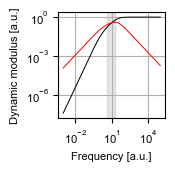

In [16]:


#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
for i in range(len(storage_mod_all_sims_all_3arm)):
    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig.add_subplot(111)
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all_3arm[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all_3arm[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr_3arm[i])))
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all_3arm[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all_3arm[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr_3arm[i])))
    
    ax1.errorbar(omega_t_sim1_hydr[::],mean_storage_mod_all_sims_ex1[::],fmt="-",label=r"$G'$",color="black",linewidth=0.7)
    ax1.fill_between(omega_t_sim1_hydr[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    ax1.errorbar(omega_t_sim1_hydr[::],mean_loss_mod_all_sims_ex1[::],fmt="-",label=r"$G''-\omega \eta$",color="red",linewidth=0.7)
    ax1.fill_between(omega_t_sim1_hydr[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")

    #determine scaling
    n1=np.gradient(mean_storage_mod_all_sims_ex1,omega_t_sim1_hydr)/mean_storage_mod_all_sims_ex1 *omega_t_sim1_hydr
    n2=np.gradient(mean_loss_mod_all_sims_ex1,omega_t_sim1_hydr)/mean_loss_mod_all_sims_ex1 *omega_t_sim1_hydr
    # Condition: 0 < n < 1 for both
    mask = (n1 > 0) & (n1 < 1) & (n2 > 0) & (n2 < 1)
    
    # Find indices where condition holds
    indices = np.where(mask)[0]
    
    start_idx = indices[0]
    end_idx = indices[-1] 

    ax1.axvspan(omega_t_sim1_hydr[start_idx], omega_t_sim1_hydr[end_idx], color='gray', alpha=0.2)

    
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    #ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    fs1=8
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    #plt.ylim(10**-6,2)
    #plt.xlim(10**-3,10**3)
    plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
    plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
    #plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
    #plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
    ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
    #ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
    #if i ==0:
    save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_ub_rate_hydr_"+str(i)+"_1b.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

<Figure size 1000x1000 with 0 Axes>

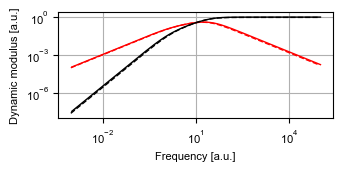

In [89]:
fig=plt.figure(figsize=(10,10))
#fig=plt.figure(figsize=(9/2.54,9/2.54))
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#fig=plt.figure(figsize=(9,9))
fig=plt.figure(figsize=(9/2.54,3.5/2.54))

ax1 = fig.add_subplot(111)
"""
1: ub rate 0.005
2: ub rate 0.0005
7: ub rate 0.0001
8: ub rate 0.00005
5: ub rate 0.000005
0: ub rate 0"""

labels_storage1=[r"$G',~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G',~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'',~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['#D3D3D3', '#A9A9A9', '#696969', '#2F4F4F']
color_loss_list1=['#FF6666', '#FF0000', '#8B0000', '#4B0000']

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']

color_storage_list1=['black',"lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red","gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']


fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]



#for i in range(len(storage_mod_all_sims_all[:4])):
lii=0
for i in [0]:
    alpha1=1 -lii/5

    #no hydr
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all_3arm[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all_3arm[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_3arm[i])))
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all_3arm[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all_3arm[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_3arm[i])))

    line1=ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt="-",linewidth=1)
    ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::] ,facecolor=color_loss_list1[lii],alpha=0.3)
   
    #hydr

    mean_loss_mod_all_sims_ex1_hydr=np.mean(loss_mod_all_sims_all_hydr_3arm[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1_hydr=np.std(loss_mod_all_sims_all_hydr_3arm[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr_3arm[i])))
    mean_storage_mod_all_sims_ex1_hydr=np.mean(storage_mod_all_sims_all_hydr_3arm[i],axis=0)
    std_e_storage_mod_all_sims_ex1_hydr=np.std(storage_mod_all_sims_all_hydr_3arm[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr_3arm[i])))

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1_hydr, y1=mean_storage_mod_all_sims_ex1_hydr, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_hydr_shift=np.array(omega_t_sim1_hydr)*omega_inters_target_1/omega_inters_1
    mean_storage_mod_all_sims_ex1_hydr_shift=np.array(mean_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_storage_mod_all_sims_ex1_hydr_shift=np.array(std_e_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    mean_loss_mod_all_sims_ex1_hydr_shift=np.array(mean_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_loss_mod_all_sims_ex1_hydr_shift=np.array(std_e_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    
    
    line1_hydr=ax1.errorbar(omega_t_sim1_hydr_shift[::],mean_loss_mod_all_sims_ex1_hydr_shift[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt="--",linewidth=1)
    ax1.fill_between(omega_t_sim1_hydr_shift[::], mean_loss_mod_all_sims_ex1_hydr_shift[::] + std_e_loss_mod_all_sims_ex1_hydr_shift[::], mean_loss_mod_all_sims_ex1_hydr_shift[::] - std_e_loss_mod_all_sims_ex1_hydr_shift[::] ,facecolor=color_loss_list1[lii],alpha=0.3)
 
    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1

lii=0
for i in [0]:

    #no hydr
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all_3arm[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all_3arm[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_3arm[i])))
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all_3arm[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all_3arm[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_3arm[i])))
    
    line1=ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt="-",linewidth=1)
    ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
   
    #hydr
    mean_loss_mod_all_sims_ex1_hydr=np.mean(loss_mod_all_sims_all_hydr_3arm[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1_hydr=np.std(loss_mod_all_sims_all_hydr_3arm[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr_3arm[i])))
    mean_storage_mod_all_sims_ex1_hydr=np.mean(storage_mod_all_sims_all_hydr_3arm[i],axis=0)
    std_e_storage_mod_all_sims_ex1_hydr=np.std(storage_mod_all_sims_all_hydr_3arm[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr_3arm[i])))

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1_hydr, y1=mean_storage_mod_all_sims_ex1_hydr, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_hydr_shift=np.array(omega_t_sim1_hydr)*omega_inters_target_1/omega_inters_1
    mean_storage_mod_all_sims_ex1_hydr_shift=np.array(mean_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1 #+omega_t_sim1*8*10**-3 #*0.05
    std_e_storage_mod_all_sims_ex1_hydr_shift=np.array(std_e_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    mean_loss_mod_all_sims_ex1_hydr_shift=np.array(mean_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_loss_mod_all_sims_ex1_hydr_shift=np.array(std_e_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    
    
    line1_hydr=ax1.errorbar(omega_t_sim1_hydr_shift[::],mean_storage_mod_all_sims_ex1_hydr_shift[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt="--",linewidth=1)
    ax1.fill_between(omega_t_sim1_hydr_shift[::], mean_storage_mod_all_sims_ex1_hydr_shift[::] + std_e_storage_mod_all_sims_ex1_hydr_shift[::], mean_storage_mod_all_sims_ex1_hydr_shift[::] - std_e_storage_mod_all_sims_ex1_hydr_shift[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
    
    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1
#ax1.errorbar(omega_t_sim1[:350],omega_t_sim1[:350]**0.5 , label=r"$\omega^{0.5}$",color="grey")
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_comp_3_arm_hydr_2.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

<Figure size 1000x1000 with 0 Axes>

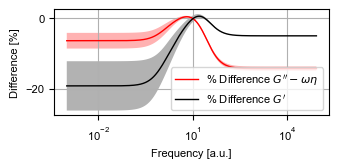

In [90]:
fig=plt.figure(figsize=(10,10))
#fig=plt.figure(figsize=(9/2.54,9/2.54))
fig=plt.figure(figsize=(9/2.54,3.5/2.54))

ax1 = fig.add_subplot(111)
"""
1: ub rate 0.005
2: ub rate 0.0005
7: ub rate 0.0001
8: ub rate 0.00005
5: ub rate 0.000005
0: ub rate 0"""

labels_storage1=[r"$G',~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G',~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'',~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['#D3D3D3', '#A9A9A9', '#696969', '#2F4F4F']
color_loss_list1=['#FF6666', '#FF0000', '#8B0000', '#4B0000']

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']

color_storage_list1=['black',"lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red","gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']



fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]

#for i in range(len(storage_mod_all_sims_all[:4])):
lii=0
for i in [0]:
    alpha1=1 -lii/5

    #no hydr
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all_3arm[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all_3arm[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_3arm[i])))
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all_3arm[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all_3arm[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_3arm[i])))

    
    #line1=ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt=fmt_loss_list1[lii],linewidth=1)
    #ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::] ,facecolor=color_loss_list1[lii],alpha=0.3)
   
    #hydr

    mean_loss_mod_all_sims_ex1_hydr=np.mean(loss_mod_all_sims_all_hydr_3arm[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1_hydr=np.std(loss_mod_all_sims_all_hydr_3arm[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr_3arm[i])))
    mean_storage_mod_all_sims_ex1_hydr=np.mean(storage_mod_all_sims_all_hydr_3arm[i],axis=0)
    std_e_storage_mod_all_sims_ex1_hydr=np.std(storage_mod_all_sims_all_hydr_3arm[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr_3arm[i])))

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1_hydr, y1=mean_storage_mod_all_sims_ex1_hydr, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_hydr_shift=np.array(omega_t_sim1_hydr)*omega_inters_target_1/omega_inters_1
    mean_storage_mod_all_sims_ex1_hydr_shift=np.array(mean_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_storage_mod_all_sims_ex1_hydr_shift=np.array(std_e_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    mean_loss_mod_all_sims_ex1_hydr_shift=np.array(mean_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_loss_mod_all_sims_ex1_hydr_shift=np.array(std_e_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1

    #interpolate to same freq values:
    mean_loss_mod_all_sims_ex1_hydr_shift_interp=np.interp(omega_t_sim1,omega_t_sim1_hydr_shift,mean_loss_mod_all_sims_ex1_hydr_shift)
    std_e_loss_mod_all_sims_ex1_hydr_shift_interp=np.interp(omega_t_sim1,omega_t_sim1_hydr_shift,std_e_loss_mod_all_sims_ex1_hydr_shift)
    
    #line1_hydr=ax1.errorbar(omega_t_sim1[:-10:],mean_loss_mod_all_sims_ex1_hydr_shift_interp[:-10:],label=labels_loss1[lii],color=color_loss_list1[lii],fmt=fmt_loss_list1[lii],linewidth=1)
    #ax1.fill_between(omega_t_sim1_hydr_shift[::], mean_loss_mod_all_sims_ex1_hydr_shift[::] + std_e_loss_mod_all_sims_ex1_hydr_shift[::], mean_loss_mod_all_sims_ex1_hydr_shift[::] - std_e_loss_mod_all_sims_ex1_hydr_shift[::] ,facecolor=color_loss_list1[lii],alpha=0.3)

    #diff
    #line1_hydr=ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1_hydr_shift_interp[::]-mean_loss_mod_all_sims_ex1[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt=fmt_loss_list1[lii],linewidth=1)

    #perc diff might have to cut off some terminal values due to issues with interpolation
    perc_diff_loss=(mean_loss_mod_all_sims_ex1_hydr_shift_interp[::]-mean_loss_mod_all_sims_ex1[::])/mean_loss_mod_all_sims_ex1[::]*100
    std_e_perc_diff_loss=np.sqrt((std_e_loss_mod_all_sims_ex1_hydr_shift_interp/mean_loss_mod_all_sims_ex1)**2 + (mean_loss_mod_all_sims_ex1_hydr_shift_interp*std_e_loss_mod_all_sims_ex1/mean_loss_mod_all_sims_ex1**2)**2)*100
    line1_hydr=ax1.errorbar(omega_t_sim1[:-10:],perc_diff_loss[:-10:],label=r"% Difference $G''-\omega \eta$",color=color_loss_list1[lii],fmt="-",linewidth=1)
    ax1.fill_between(omega_t_sim1[:-10:], perc_diff_loss[:-10:] + std_e_perc_diff_loss[:-10:], perc_diff_loss[:-10:] - std_e_perc_diff_loss[:-10:] ,facecolor=color_loss_list1[lii],alpha=0.3)

    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1

lii=0
for i in [0]:

    #no hydr
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all_3arm[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all_3arm[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_3arm[i])))
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all_3arm[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all_3arm[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_3arm[i])))
    
    #line1=ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt=fmt_storage_list1[lii],linewidth=1)
    #ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
   
    #hydr
    mean_loss_mod_all_sims_ex1_hydr=np.mean(loss_mod_all_sims_all_hydr_3arm[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1_hydr=np.std(loss_mod_all_sims_all_hydr_3arm[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr_3arm[i])))
    mean_storage_mod_all_sims_ex1_hydr=np.mean(storage_mod_all_sims_all_hydr_3arm[i],axis=0)
    std_e_storage_mod_all_sims_ex1_hydr=np.std(storage_mod_all_sims_all_hydr_3arm[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr_3arm[i])))

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1)[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1_hydr, y1=mean_storage_mod_all_sims_ex1_hydr, x2=omega_t_sim1_hydr, y2=mean_loss_mod_all_sims_ex1_hydr)[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_hydr_shift=np.array(omega_t_sim1_hydr)*omega_inters_target_1/omega_inters_1
    mean_storage_mod_all_sims_ex1_hydr_shift=np.array(mean_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_storage_mod_all_sims_ex1_hydr_shift=np.array(std_e_storage_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    mean_loss_mod_all_sims_ex1_hydr_shift=np.array(mean_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1
    std_e_loss_mod_all_sims_ex1_hydr_shift=np.array(std_e_loss_mod_all_sims_ex1_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_1

    #interpolate to same freq values:
    mean_storage_mod_all_sims_ex1_hydr_shift_interp=np.interp(omega_t_sim1,omega_t_sim1_hydr_shift,mean_storage_mod_all_sims_ex1_hydr_shift)
    std_e_storage_mod_all_sims_ex1_hydr_shift_interp=np.interp(omega_t_sim1,omega_t_sim1_hydr_shift,std_e_storage_mod_all_sims_ex1_hydr_shift)
    #line1_hydr=ax1.errorbar(omega_t_sim1[:-10:],mean_storage_mod_all_sims_ex1_hydr_shift_interp[:-10:],label=labels_storage1[lii],color=color_storage_list1[lii],fmt=fmt_storage_list1[lii],linewidth=1)
    #ax1.fill_between(omega_t_sim1_hydr_shift[::], mean_storage_mod_all_sims_ex1_hydr_shift[::] + std_e_storage_mod_all_sims_ex1_hydr_shift[::], mean_storage_mod_all_sims_ex1_hydr_shift[::] - std_e_storage_mod_all_sims_ex1_hydr_shift[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
    
    #diff
    #line1_hydr=ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1_hydr_shift_interp[::]-mean_storage_mod_all_sims_ex1[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt=fmt_storage_list1[lii],linewidth=1)

    #perc diff
    perc_diff_storage=(mean_storage_mod_all_sims_ex1_hydr_shift_interp[::]-mean_storage_mod_all_sims_ex1[::])/mean_storage_mod_all_sims_ex1[::] *100
    std_e_perc_diff_storage=np.sqrt((std_e_storage_mod_all_sims_ex1_hydr_shift_interp/mean_storage_mod_all_sims_ex1)**2 + (mean_storage_mod_all_sims_ex1_hydr_shift_interp*std_e_storage_mod_all_sims_ex1/mean_storage_mod_all_sims_ex1**2)**2) *100

    line1_hydr=ax1.errorbar(omega_t_sim1[:-10:],perc_diff_storage[:-10:],label=r"% Difference $G'$",color=color_storage_list1[lii],fmt="-",linewidth=1)
    ax1.fill_between(omega_t_sim1[:-10:], perc_diff_storage[:-10:] + std_e_perc_diff_storage[:-10:], perc_diff_storage[:-10:] - std_e_perc_diff_storage[:-10:] ,facecolor=color_storage_list1[lii],alpha=0.3)

    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1
#ax1.errorbar(omega_t_sim1[:350],omega_t_sim1[:350]**0.5 , label=r"$\omega^{0.5}$",color="grey")
fs1=8
plt.xscale("log")
#plt.yscale("log")
plt.grid()

plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Difference [%]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/differences_moduli_3_arm_hydr_2.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [79]:
%%time
#calculate average distance between linked nanomotif centers from simulations

omega_t_sim1_hydr=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1_hydr=np.geomspace(10**-2,10**3,10**2)

#use skip 5250 for cont 2 read in , use skip 11250 for 6e7 run (soft with r_ub=0)
#folder_names_dyn_mod=[folder_names_all_ex[e] for e in [8,2]]  #8,2
#time_skip_dyn_mod=[5250,2250] #,2250]

folder_name_ex3=["/mnt/d/D_phd/Y_shaped_nanomotifs_networking/sim_opt_Y_motif_rheo_high_conn_1/prod_cont_checkpoint_"+str(e)+"/y_xma_opt_prod_cont_rheo_high_conn_1_"+str(e)+".h5" for e in [0,1,2,3,4]]


folder_names_dyn_mod=[folder_name_ex3]
time_skip_dyn_mod=[2250]


#folder_names_dyn_mod=[["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]]
#time_skip_dyn_mod=[11250]

#print(folder_names_dyn_mod)
input_dyn_mod=[]
box_size=[69.7,69.7,69.7]
eta=8*10**-3
a=4.7
t_r_avg_f=-10
t_r_avg_l=10

for i in range(len(folder_names_dyn_mod)):
    input_dyn_mod.append((folder_names_dyn_mod[i],omega_t_sim1_hydr,t_sim1_hydr,1,1,1,1,1,15,time_skip_dyn_mod[i],box_size,eta,a,t_r_avg_f,t_r_avg_l))

with ThreadPoolExecutor(max_workers=18) as executor:
    results_dist_3arm = list(executor.map(lambda args: avg_conn_mat_dist_3arm(*args), input_dyn_mod))




calc. for sim  0
calc. for sim  1
calc. for sim  2
calc. for sim  3
calc. for sim  4
CPU times: user 14.6 s, sys: 1.07 s, total: 15.6 s
Wall time: 43.7 s


In [81]:
results_dist_fl_3arm = [element for innerList in results_dist_3arm[0] for element in innerList]

results_dist_fl2_3arm=[element for innerList in results_dist_fl_3arm for element in innerList]
print(np.mean(results_dist_fl2_3arm))
print(np.std(results_dist_fl2_3arm))

15.66664644849491
0.38483487274348277


# Compare angles from optimised and soft sims

CPU times: user 182 ms, sys: 1.07 s, total: 1.25 s
Wall time: 5.62 s


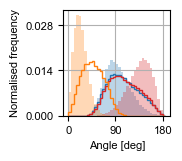

In [24]:
%%time

#guess parameter in middle of range
#folder_names_init_sim="ML_parameter_opt_1/NCG_X_motif_4/unopt_test_2/"
#names_ini1="x_test_1_"

#sim from optimization
folder_names_init_sim="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_2/1_motif_SE/"
names_ini1="x_c_mech_opt_angle_test_"

#opt simulations
folder_names_opt_sim1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/opt_test_1/"
#folder_names_opt_sim2="ML_parameter_opt_1/NCG_X_motif_3/opt_test_2/"
#folder_names_opt_sim3="ML_parameter_opt_1/NCG_X_motif_3/opt_test_3/"

names_opt1="x_opt_test_1_"
#names_opt2="x_opt_test_2_"
#names_opt3="x_opt_test_3_"

names_angle_eval=[[names_ini1+str(l+0)+".h5" for l in range(5)]
                 ,[names_opt1+str(l+0)+".h5" for l in range(5)]]

folders_angle_eval=[folder_names_init_sim,
                   folder_names_opt_sim1]

colours_l=["tab:blue","tab:blue"]
colours_l2=["tab:red","tab:red"]
colours_l3=["tab:orange","tab:orange"]
names_l=["First prediction","Optimised"]
histtype=["step","bar"]
alpha=[1,0.3]

fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)
#sel_target_angle_distr=ax1.hist(values_angle_base_target*180/np.pi,bins=np.arange(0,190,5),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]


for i in range(len(names_angle_eval)):
    base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
    list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]

    sel_angle_distr=ax1.hist(values_angle_base_ex_1*180/np.pi,bins=np.arange(0,190,5),density=True, color=colours_l[i],histtype=histtype[i],label=names_l[i],alpha=alpha[i])[0]

    sel_angle_distr2=ax1.hist(values_angle_oppa_ex_test_1*180/np.pi,bins=np.arange(0,190,5),density=True, color=colours_l2[i],histtype=histtype[i],label=names_l[i],alpha=alpha[i])[0]
    




#sim from optimization
folder_names_init_sim="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_2/2_motifs_bound/"
names_ini1="x_c_mech_opt_angle_test_bound_"

#opt simulations
folder_names_opt_sim1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/opt_test_1/"
#folder_names_opt_sim2="ML_parameter_opt_1/NCG_X_motif_3/opt_test_2/"
#folder_names_opt_sim3="ML_parameter_opt_1/NCG_X_motif_3/opt_test_3/"

names_opt1="x_opt_test_ba_1_"
#names_opt2="x_opt_test_ba_2_"
#names_opt3="x_opt_test_ba_3_"

names_angle_eval=[[names_ini1+str(l+0)+".h5" for l in range(5)]
                 ,[names_opt1+str(l+0)+".h5" for l in range(5)]]

folders_angle_eval=[folder_names_init_sim,
                   folder_names_opt_sim1]


#sel_target_angle_distr=ax1.hist(values_angle_ds_fused_link_target*180/np.pi,bins=np.arange(0,190,5),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]

for i in range(len(names_angle_eval)):
    angle_ds_fused_link_distr_ex_1, values_angle_ds_fused_link_ex1=cg_angle_distr_c1_1_bm(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)

    sel_angle_distr4=ax1.hist(values_angle_ds_fused_link_ex1*180/np.pi,bins=np.arange(0,190,5),density=True,color=colours_l3[i], histtype=histtype[i],label=names_l[i],alpha=alpha[i])[0]



fs1=8

#ax1.legend(loc="lower center",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks([0,90,180],fontname = "Arial",fontsize=fs1)
plt.yticks([0.00,0.014,0.028],fontname = "Arial",fontsize=fs1)
#plt.xlim(-1,50)
ax1.grid()

#plt.savefig("ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comparison_angles_normal_soft_1.pdf",format="pdf",bbox_inches="tight")




# Radial distribution function

In [87]:
#names with varying unbidning rate
folder_name_rdf_ex1=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_"+str(e)+"/x_c_mech_opt_prod_cont_2_"+str(e)+".h5" for e in [0,1,2,3,4]]

folder_name_rdf_ex2=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_4/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

folder_name_rdf_ex3=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_2/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

folder_name_rdf_ex4=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]


In [88]:
r1,rdf1_t_rep=mean_rdf_repeats(file_names=folder_name_rdf_ex1,box_length=69.718, r_max=50, dr=0.1,type_particle=53,t_skip=5250,t_step=15,t_stop=None)

x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51


In [70]:
r2,rdf2_t_rep=mean_rdf_repeats(file_names=folder_name_rdf_ex2,box_length=69.718, r_max=50, dr=0.1,type_particle=53,t_skip=2250,t_step=15,t_stop=None)

x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51


In [71]:
r3,rdf3_t_rep=mean_rdf_repeats(file_names=folder_name_rdf_ex3,box_length=69.718, r_max=50, dr=0.1,type_particle=53,t_skip=2250,t_step=15,t_stop=None)

x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51


In [72]:
r4,rdf4_t_rep=mean_rdf_repeats(file_names=folder_name_rdf_ex4,box_length=69.718, r_max=50, dr=0.1,type_particle=53,t_skip=11250,t_step=15,t_stop=None)

x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51


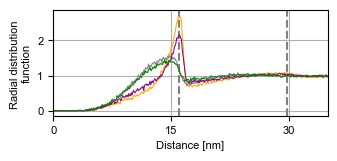

In [73]:
fig=plt.figure(figsize=(9/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

mean_rdf1_t_rep=np.mean(rdf1_t_rep,axis=0)
std_e_rdf1_t_rep=np.std(rdf1_t_rep,axis=0)/(np.sqrt(rdf1_t_rep.shape[0]))

mean_rdf2_t_rep=np.mean(rdf2_t_rep,axis=0)
std_e_rdf2_t_rep=np.std(rdf2_t_rep,axis=0)/(np.sqrt(rdf2_t_rep.shape[0]))

mean_rdf3_t_rep=np.mean(rdf3_t_rep,axis=0)
std_e_rdf3_t_rep=np.std(rdf3_t_rep,axis=0)/(np.sqrt(rdf3_t_rep.shape[0]))

mean_rdf4_t_rep=np.mean(rdf4_t_rep,axis=0)
std_e_rdf4_t_rep=np.std(rdf4_t_rep,axis=0)/(np.sqrt(rdf4_t_rep.shape[0]))

step_l1=1
ax1.errorbar(r1[::step_l1],mean_rdf1_t_rep[::step_l1],color="orange",label=r"$r_{Split} \cdot \Delta t=0$",linewidth=0.7)
ax1.fill_between(r1, mean_rdf1_t_rep[::] + std_e_rdf1_t_rep[::], mean_rdf1_t_rep[::] - std_e_rdf1_t_rep[::], alpha = 0.3 ,facecolor="orange")

ax1.errorbar(r4[::step_l1],mean_rdf4_t_rep[::step_l1],color="grey",label=r"$r_{Split}\cdot \Delta t=0$, no inter-arm pot.",linewidth=0.7)
ax1.fill_between(r4, mean_rdf4_t_rep[::] + std_e_rdf4_t_rep[::], mean_rdf4_t_rep[::] - std_e_rdf4_t_rep[::], alpha = 0.3 ,facecolor="grey")

ax1.errorbar(r1[::step_l1],mean_rdf2_t_rep[::step_l1],color="purple",label=r"$r_{Split}\cdot \Delta t=5\cdot 10^{-6}$",linewidth=0.7)
ax1.fill_between(r1, mean_rdf2_t_rep[::] + std_e_rdf2_t_rep[::], mean_rdf2_t_rep[::] - std_e_rdf2_t_rep[::], alpha = 0.3 ,facecolor="purple")

ax1.errorbar(r1[::step_l1],mean_rdf3_t_rep[::step_l1],color="green",label=r"$r_{Split}\cdot \Delta t=5\cdot 10^{-6}$, no inter-arm pot.",linewidth=0.7)
ax1.fill_between(r1, mean_rdf3_t_rep[::] + std_e_rdf3_t_rep[::], mean_rdf3_t_rep[::] - std_e_rdf3_t_rep[::], alpha = 0.3 ,facecolor="green")





fs1=8
plt.xlim(0,35)
plt.xticks([0,15,30],fontname = "Arial",fontsize=fs1)
plt.yticks([0,1,2],fontname = "Arial",fontsize=fs1)

plt.ylabel("Radial distribution \nfunction",fontname = "Arial",fontsize=fs1)
plt.xlabel("Distance [nm]",fontname = "Arial",fontsize=fs1)
plt.grid()


#plt.axhline(1)
plt.axvline(16,color="grey",linestyle="--",label="16 nm")
plt.axvline(29.8,color="grey",linestyle="--",label="16 nm")

#ax1.legend(prop={'family': 'Arial','size': fs1},loc="upper right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/rad_ditr_fct_comp_2.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
#plt.hlines(1,0,80)

In [ ]:
peaks,_=scipy.signal.find_peaks(mean_rdf1_t_rep, prominence=0.1)
print(peaks)
print(r1[peaks])

# Rdf 3-armed

In [82]:
#names with varying unbidning rate
folder_name_rdf_ex1_3armed=["/mnt/d/D_phd/Y_shaped_nanomotifs_networking/sim_opt_Y_motif_rheo_high_conn_1/prod_cont_checkpoint_"+str(e)+"/y_xma_opt_prod_cont_rheo_high_conn_1_"+str(e)+".h5" for e in [0,1,2,3,4]]


In [85]:
r1_3armed,rdf1_t_rep_3armed=mean_rdf_repeats(file_names=folder_name_rdf_ex1_3armed,box_length=69.718, r_max=50, dr=0.1,type_particle=0,t_skip=2250,t_step=15,t_stop=None)

y_centre_1
51
y_centre_1
51
y_centre_1
51
y_centre_1
51
y_centre_1
51


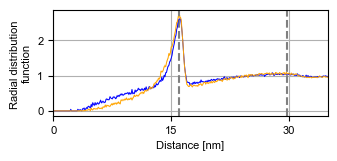

In [90]:
fig=plt.figure(figsize=(9/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

mean_rdf1_t_rep_3armed=np.mean(rdf1_t_rep_3armed,axis=0)
std_e_rdf1_t_rep_3armed=np.std(rdf1_t_rep_3armed,axis=0)/(np.sqrt(rdf1_t_rep_3armed.shape[0]))

step_l1=1
ax1.errorbar(r1_3armed[::step_l1],mean_rdf1_t_rep_3armed[::step_l1],color="blue",label=r"$r_{Split} \cdot \Delta t=0$",linewidth=0.7)
ax1.fill_between(r1_3armed, mean_rdf1_t_rep_3armed[::] + std_e_rdf1_t_rep_3armed[::], mean_rdf1_t_rep_3armed[::] - std_e_rdf1_t_rep_3armed[::], alpha = 0.3 ,facecolor="blue")


#also plot 4 amred
mean_rdf1_t_rep=np.mean(rdf1_t_rep,axis=0)
std_e_rdf1_t_rep=np.std(rdf1_t_rep,axis=0)/(np.sqrt(rdf1_t_rep.shape[0]))
ax1.errorbar(r1[::step_l1],mean_rdf1_t_rep[::step_l1],color="orange",label=r"$r_{Split} \cdot \Delta t=0$",linewidth=0.7)
ax1.fill_between(r1, mean_rdf1_t_rep[::] + std_e_rdf1_t_rep[::], mean_rdf1_t_rep[::] - std_e_rdf1_t_rep[::], alpha = 0.3 ,facecolor="orange")



fs1=8
plt.xlim(0,35)
plt.xticks([0,15,30],fontname = "Arial",fontsize=fs1)
plt.yticks([0,1,2],fontname = "Arial",fontsize=fs1)

plt.ylabel("Radial distribution \nfunction",fontname = "Arial",fontsize=fs1)
plt.xlabel("Distance [nm]",fontname = "Arial",fontsize=fs1)
plt.grid()


#plt.axhline(1)
plt.axvline(16,color="grey",linestyle="--",label="16 nm")
plt.axvline(29.8,color="grey",linestyle="--",label="16 nm")

#ax1.legend(prop={'family': 'Arial','size': fs1},loc="upper right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/rad_ditr_fct_comp_2.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
#plt.hlines(1,0,80)

# Get intra-chain mod

12


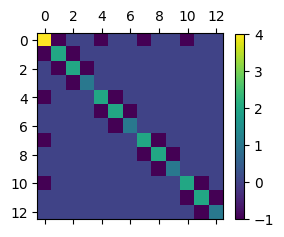

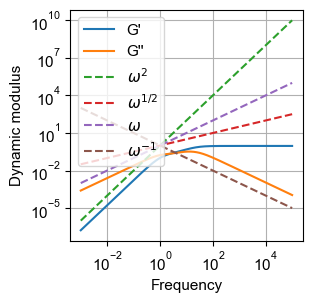

In [73]:
def calculate_graph_laplacian(edges, num_nodes):
    # Initialize the adjacency matrix
    adjacency_matrix = np.zeros((num_nodes, num_nodes))
    
    # Fill the adjacency matrix based on the edges
    for edge in edges:
        i, j = edge
        adjacency_matrix[i, j] = 1
        adjacency_matrix[j, i] = 1
    
    # Degree matrix
    degree_matrix = np.diag(np.sum(adjacency_matrix, axis=1))
    
    # Laplacian matrix
    laplacian_matrix = degree_matrix - adjacency_matrix
    
    return laplacian_matrix


conn_matrix_intra_1=calculate_graph_laplacian(edges=[(0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6), (0, 7), (7, 8), (8, 9), (0, 10), (10, 11), (11, 12)],num_nodes=13)

fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
cax1=ax1.matshow(conn_matrix_intra_1, cmap='viridis')
fig1.colorbar(cax1,shrink=0.8)

eigenvalues_intra_1, eigenvectors_intra_1 = np.linalg.eig(conn_matrix_intra_1)



#get relaxation times for non-zero eigenvalues
#!! sometimes very small eigenvalues are calculated that should probably be zero, for instance for graph laplacian for N monomers, only N-1 non-zero eigenvalues exist
eigenvalues_intra_1_nz=np.array([e for e in eigenvalues_intra_1 if abs(e)>10**-9])
tau_intra_1=relax_times(zeta=1,b=1,k=1,T=1,eigv_lambda=eigenvalues_intra_1_nz)
print(len(tau_intra_1))

#get storage mod and loss mod
#omega_intra_1=np.geomspace(10**-2,10**4,10**4)
#t_intra_1=np.geomspace(10**-2,10**3,10**4)

storage_mod_intra_1=storage_mod(phi=1,k=1,T=1,N=13,b=1,tau=tau_intra_1[:],omega=omega_t_sim1)
loss_mod_intra_1=loss_mod_deref(phi=1,k=1,T=1,N=13,b=1,tau=tau_intra_1[:],omega=omega_t_sim1)
relaxation_mod_intra_1=relaxation_mod(phi=1,k=1,T=1,N=13,b=1,tau=tau_intra_1[:],t=t_sim1)
storage_mod_intra_1=[x.real if isinstance(x, complex) else x for x in storage_mod_intra_1]
loss_mod_intra_1=[x.real if isinstance(x, complex) else x for x in loss_mod_intra_1]
relaxation_mod_intra_1=[x.real if isinstance(x, complex) else x for x in relaxation_mod_intra_1]

fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)

ax1.errorbar(omega_t_sim1,storage_mod_intra_1,fmt="-",label="G'")
ax1.errorbar(omega_t_sim1,loss_mod_intra_1,fmt="-",label="G''")

omega_intra_2=np.geomspace(10**0,10**2,10**3)
ax1.errorbar(omega_t_sim1,omega_t_sim1**2,label=r"$\omega^2$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**0.5,label=r"$\omega^{1/2}$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**1,label=r"$\omega$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**-1,label=r"$\omega^{-1}$",fmt="--")

plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
ax1.set_ylabel("Dynamic modulus",fontname = "Arial",fontsize=11)
ax1.set_xlabel("Frequency",fontname = "Arial",fontsize=11)
ax1.legend(loc="upper left",prop={'family': 'Arial','size': 11})

# Generate theoretical graphs of networked materials

8.0
6


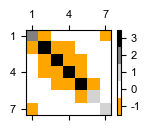

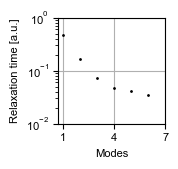

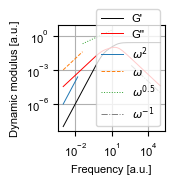

In [22]:
#example graph, relaxation times and moduli

omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)
fs1=8
num_nodes_ilu_1=24
#conn_matrix_gen_ilu_1=generate_rd_graph_laplacian2_b(N=num_nodes_ilu_1, m=4, p=30,rs=4)

conn_matrix_gen_ilu_1=generate_laplacian_from_edges([[0,1],[1,2],[2,3],[3,4],[1,3],[2,4],[4,5],[0,6]])

#edges_test_1=[[i,i+1] for i in range(1000)]
#conn_matrix_gen_ilu_1=generate_laplacian_from_edges(edges_test_1)

print(0.5*np.trace(conn_matrix_gen_ilu_1))
fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig1.add_subplot(111)


from matplotlib.colors import ListedColormap,BoundaryNorm
# You can also use: ListedColormap(plt.cm.tab10.colors[:5])
cmap = ListedColormap(["orange", "white", "lightgrey", "grey", "black"])

cax1=ax1.matshow(conn_matrix_gen_ilu_1, cmap=cmap)


bounds  = np.array([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5])  # 6 edges → 5 bins
centers = (bounds[:-1] + bounds[1:]) / 2               # → [-1, 0, 1, 2, 3]
labels  = ['-1', '0', '1', '2', '3']

norm = BoundaryNorm(bounds, cmap.N, clip=True)

cbar = plt.colorbar(cax1, shrink=0.8, ticks=centers,boundaries=bounds)

cbar.ax.set_yticklabels(labels)  # vertical by default

cbar.ax.tick_params(labelsize=fs1,labelfontfamily = "Arial")

############
#cbar = plt.colorbar(cax1,shrink=0.8)
#cbar.set_ticks([-1,0,1,2,3])
#cbar.ax.tick_params(labelsize=fs1,labelfontfamily = "Arial")
##############

plt.yticks([0,3,6],[1,4,7],fontname = "Arial",fontsize=fs1)
plt.xticks([0,3,6],[1,4,7],fontname = "Arial",fontsize=fs1)

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/graph_laplacian_2.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")


eigenvalues_gen_ilu_1, eigenvectors_gen_ilu_1 = np.linalg.eig(conn_matrix_gen_ilu_1)



#get relaxation times for non-zero eigenvalues
#!! sometimes very small eigenvalues are calculated that should probably be zero, for instance for graph laplacian for N monomers, only N-1 non-zero eigenvalues exist
eigenvalues_gen_ilu_1_nz=np.array([e for e in eigenvalues_gen_ilu_1 if abs(e)>10**-9])
tau_gen_ilu_1=relax_times(zeta=1,b=1,k=1,T=1,eigv_lambda=eigenvalues_gen_ilu_1_nz)
print(len(tau_gen_ilu_1))

#get storage mod and loss mod
#omega_gen_ilu_1=np.geomspace(10**-2,10**4,10**4)
#t_gen_ilu_1=np.geomspace(10**-2,10**3,10**4)

storage_mod_gen_ilu_1=storage_mod(phi=1,k=1,T=1,N=num_nodes_ilu_1,b=1,tau=tau_gen_ilu_1[:],omega=omega_t_sim1)
loss_mod_gen_ilu_1=loss_mod_deref(phi=1,k=1,T=1,N=num_nodes_ilu_1,b=1,tau=tau_gen_ilu_1[:],omega=omega_t_sim1)
relaxation_mod_gen_ilu_1=relaxation_mod(phi=1,k=1,T=1,N=num_nodes_ilu_1,b=1,tau=tau_gen_ilu_1[:],t=t_sim1)
storage_mod_gen_ilu_1=[x.real if isinstance(x, complex) else x for x in storage_mod_gen_ilu_1]
loss_mod_gen_ilu_1=[x.real if isinstance(x, complex) else x for x in loss_mod_gen_ilu_1]
relaxation_mod_gen_ilu_1=[x.real if isinstance(x, complex) else x for x in relaxation_mod_gen_ilu_1]


sorted_tau_test=sorted(tau_gen_ilu_1,reverse=True)
modes_test=np.arange(1,len(sorted_tau_test)+1)
fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig1.add_subplot(111)
ax1.errorbar(modes_test,sorted_tau_test,fmt=".",markersize=2,color="black")
0
#plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks([1,4,7],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-2,10**-1,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Relaxation time [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Modes",fontname = "Arial",fontsize=fs1)

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/relax_times_graph_laplacian_2.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")


fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig1.add_subplot(111)

ax1.errorbar(omega_t_sim1,storage_mod_gen_ilu_1,fmt="-",label="G'",color="black",linewidth=0.7)
ax1.errorbar(omega_t_sim1,loss_mod_gen_ilu_1,fmt="-",label="G''",color="red",linewidth=0.7)

omega_gen_rd_2=np.geomspace(10**0,10**2,10**3)
'''ax1.errorbar(omega_t_sim1,omega_t_sim1**2,label=r"$\omega^2$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**0.5,label=r"$\omega^{1/2}$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**1,label=r"$\omega$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**-1,label=r"$\omega^{-1}$",fmt="--")'''

ax1.errorbar(omega_t_sim1[:150],omega_t_sim1[:150]**2, label=r"$\omega^2$",fmt="-",linewidth=0.7)
ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$",fmt="--",linewidth=0.7)
ax1.errorbar(omega_t_sim1[200:500],omega_t_sim1[200:500]**0.5 , label=r"$\omega^{0.5}$",fmt=":",linewidth=0.7)
ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$",fmt="-.",color="grey",linewidth=0.7)

plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(loc="lower right",prop={'family': 'Arial','size': fs1})
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/moduli_graph_laplacian_2.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")


200.0
99
200.0
99


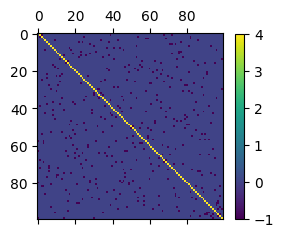

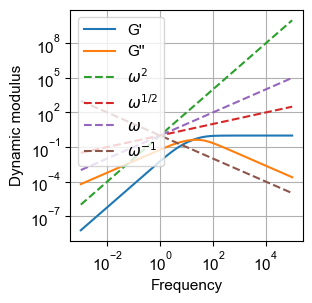

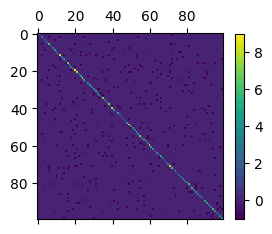

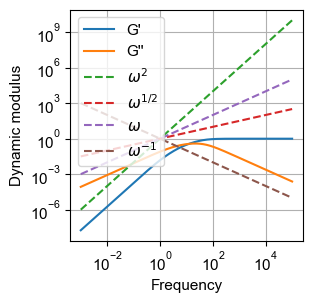

In [74]:

#generate theoretical graphs


#graph of 100, 4-armed nanomotifs, with all 4 armes connected to other nanomotifs
num_nodes_rd_1=100
conn_matrix_gen_rd_1=generate_rd_graph_laplacian2_b(N=num_nodes_rd_1, m=4, p=200,rs=1)
print(0.5*np.trace(conn_matrix_gen_rd_1))
fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
cax1=ax1.matshow(conn_matrix_gen_rd_1, cmap='viridis')
fig1.colorbar(cax1,shrink=0.8)

eigenvalues_gen_rd_1, eigenvectors_gen_rd_1 = np.linalg.eig(conn_matrix_gen_rd_1)



#get relaxation times for non-zero eigenvalues
#!! sometimes very small eigenvalues are calculated that should probably be zero, for instance for graph laplacian for N monomers, only N-1 non-zero eigenvalues exist
eigenvalues_gen_rd_1_nz=np.array([e for e in eigenvalues_gen_rd_1 if abs(e)>10**-9])
tau_gen_rd_1=relax_times(zeta=1,b=1,k=1,T=1,eigv_lambda=eigenvalues_gen_rd_1_nz)
print(len(tau_gen_rd_1))

#get storage mod and loss mod
#omega_gen_rd_1=np.geomspace(10**-2,10**4,10**4)
#t_gen_rd_1=np.geomspace(10**-2,10**3,10**4)

storage_mod_gen_rd_1=storage_mod(phi=1,k=1,T=1,N=num_nodes_rd_1,b=1,tau=tau_gen_rd_1[:],omega=omega_t_sim1)
loss_mod_gen_rd_1=loss_mod_deref(phi=1,k=1,T=1,N=num_nodes_rd_1,b=1,tau=tau_gen_rd_1[:],omega=omega_t_sim1)
relaxation_mod_gen_rd_1=relaxation_mod(phi=1,k=1,T=1,N=num_nodes_rd_1,b=1,tau=tau_gen_rd_1[:],t=t_sim1)
storage_mod_gen_rd_1=[x.real if isinstance(x, complex) else x for x in storage_mod_gen_rd_1]
loss_mod_gen_rd_1=[x.real if isinstance(x, complex) else x for x in loss_mod_gen_rd_1]
relaxation_mod_gen_rd_1=[x.real if isinstance(x, complex) else x for x in relaxation_mod_gen_rd_1]

fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)

ax1.errorbar(omega_t_sim1,storage_mod_gen_rd_1,fmt="-",label="G'")
ax1.errorbar(omega_t_sim1,loss_mod_gen_rd_1,fmt="-",label="G''")

omega_gen_rd_2=np.geomspace(10**0,10**2,10**3)
ax1.errorbar(omega_t_sim1,omega_t_sim1**2,label=r"$\omega^2$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**0.5,label=r"$\omega^{1/2}$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**1,label=r"$\omega$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**-1,label=r"$\omega^{-1}$",fmt="--")

plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
ax1.set_ylabel("Dynamic modulus",fontname = "Arial",fontsize=11)
ax1.set_xlabel("Frequency",fontname = "Arial",fontsize=11)
ax1.legend(loc="upper left",prop={'family': 'Arial','size': 11})




################################
################################
################################
################################
################################
################################


#graph of 100, motifs with maximum degree 99 and same number of edges as for the 4-armed systems

num_nodes_rd_2=100
conn_matrix_gen_rd_2=generate_rd_graph_laplacian2_b(N=num_nodes_rd_2, m=99, p=200,rs=1)
print(0.5*np.trace(conn_matrix_gen_rd_2))
fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
cax1=ax1.matshow(conn_matrix_gen_rd_2, cmap='viridis')
fig1.colorbar(cax1,shrink=0.8)

eigenvalues_gen_rd_2, eigenvectors_gen_rd_2 = np.linalg.eig(conn_matrix_gen_rd_2)



#get relaxation times for non-zero eigenvalues
#!! sometimes very small eigenvalues are calculated that should probably be zero, for instance for graph laplacian for N monomers, only N-1 non-zero eigenvalues exist
eigenvalues_gen_rd_2_nz=np.array([e for e in eigenvalues_gen_rd_2 if abs(e)>10**-9])
tau_gen_rd_2=relax_times(zeta=1,b=1,k=1,T=1,eigv_lambda=eigenvalues_gen_rd_2_nz)
print(len(tau_gen_rd_2))

#get storage mod and loss mod
#omega_gen_rd_2=np.geomspace(10**-2,10**4,10**4)
#t_gen_rd_2=np.geomspace(10**-2,10**3,10**4)

storage_mod_gen_rd_2=storage_mod(phi=1,k=1,T=1,N=num_nodes_rd_2,b=1,tau=tau_gen_rd_2[:],omega=omega_t_sim1)
loss_mod_gen_rd_2=loss_mod_deref(phi=1,k=1,T=1,N=num_nodes_rd_2,b=1,tau=tau_gen_rd_2[:],omega=omega_t_sim1)
relaxation_mod_gen_rd_2=relaxation_mod(phi=1,k=1,T=1,N=num_nodes_rd_2,b=1,tau=tau_gen_rd_2[:],t=t_sim1)
storage_mod_gen_rd_2=[x.real if isinstance(x, complex) else x for x in storage_mod_gen_rd_2]
loss_mod_gen_rd_2=[x.real if isinstance(x, complex) else x for x in loss_mod_gen_rd_2]
relaxation_mod_gen_rd_2=[x.real if isinstance(x, complex) else x for x in relaxation_mod_gen_rd_2]

fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)

ax1.errorbar(omega_t_sim1,storage_mod_gen_rd_2,fmt="-",label="G'")
ax1.errorbar(omega_t_sim1,loss_mod_gen_rd_2,fmt="-",label="G''")

omega_gen_rd_2=np.geomspace(10**0,10**2,10**3)
ax1.errorbar(omega_t_sim1,omega_t_sim1**2,label=r"$\omega^2$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**0.5,label=r"$\omega^{1/2}$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**1,label=r"$\omega$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**-1,label=r"$\omega^{-1}$",fmt="--")

plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
ax1.set_ylabel("Dynamic modulus",fontname = "Arial",fontsize=11)
ax1.set_xlabel("Frequency",fontname = "Arial",fontsize=11)
ax1.legend(loc="upper left",prop={'family': 'Arial','size': 11})






# Compare moduli to experimental data

Experimental bulk rheology data was provided by Nathaniel Conrad and is described in Conrad et al Increasing valence pushes DNA nanostar networks to the isostatic point, PNAS, 2019

Additional micro rheology data was generated in Palombo et al Topological linking determines elasticity in limited valence networks, Nat. Materials, 2025. Data was made available with publication. 

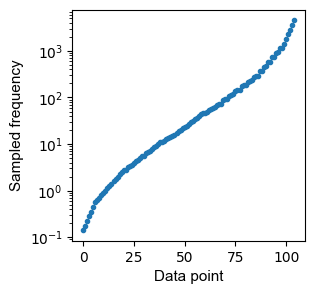

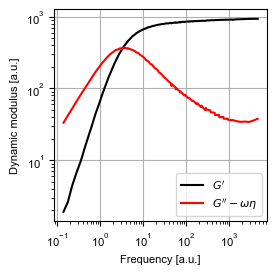

In [75]:
#Exp. data from Conrad et al for 4-armed motif
exp_data_dyn_mod=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_conrad_et_al/FrequencySweep_4ArmDNAns_490uM.csv",sep=",",header=None)
exp_data_dyn_mod.columns=["freq.","G'","G''"]

freq=exp_data_dyn_mod["freq."].to_numpy()

G_storage_exp=exp_data_dyn_mod["G'"].to_numpy()
G_loss_exp=exp_data_dyn_mod["G''"].to_numpy()

fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
ax1.errorbar(np.arange(len(freq)),freq,fmt=".")
ax1.set_ylabel("Sampled frequency",fontname = "Arial",fontsize=11)
ax1.set_xlabel("Data point",fontname = "Arial",fontsize=11)
plt.yscale("log")

#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(7/2.54,7/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq[::],G_storage_exp[::],fmt="-",label=r"$G'$",color="black")


ax1.errorbar(freq[::],G_loss_exp[::],fmt="-",label=r"$G''-\omega \eta$",color="red")


fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**-6,2)
#plt.xlim(10**-3,10**3)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_ub_rate_ex_"+str(i)+"_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [76]:
#load in sim data for 4-armed motif

omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)


#load in new
folder_name_ex_c=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_"+str(e)+"/x_c_mech_opt_prod_cont_2_"+str(e)+".h5" for e in [0,1,2,3,4]]

#####storage_mod_all_sims_ex_c,loss_mod_all_sims_ex_c=avg_moduli_1(folder_names=folder_name_ex_c,omega_t_sim1=omega_t_sim1,t_sim1=t_sim1,b_u=1,zeta_u=1,k_u=1,T_u=1,phi_u=1,time_step=15,time_skip=5250)
#storage_mod_all_sims_ex_c,loss_mod_all_sims_ex_c,conn_mat_sim_ex_c=avg_moduli_3(folder_names=folder_name_ex_c,omega_t_sim1=omega_t_sim1,t_sim1=t_sim1,b_u=1,zeta_u=1,k_u=1,T_u=1,phi_u=1,time_step=15,time_skip=5250)

#use previous load in

storage_mod_all_sims_ex_c=storage_mod_all_sims_all[-1]
loss_mod_all_sims_ex_c=loss_mod_all_sims_all[-1]

#previous load in hydr:
#storage_mod_all_sims_ex_c=storage_mod_all_sims_all_hydr[0]
#loss_mod_all_sims_ex_c=loss_mod_all_sims_all_hydr[0]

storage_mod_all_t_avg_comp_mean=np.mean(storage_mod_all_sims_ex_c,axis=0)
loss_mod_all_t_avg_comp_mean=np.mean(loss_mod_all_sims_ex_c,axis=0)

storage_mod_all_t_avg_comp_stde=np.std(storage_mod_all_sims_ex_c,axis=0)/np.sqrt(len(storage_mod_all_sims_ex_c))
loss_mod_all_t_avg_comp_stde=np.std(loss_mod_all_sims_ex_c,axis=0)/np.sqrt(len(loss_mod_all_sims_ex_c))

In [77]:
#load in hydro:
storage_mod_all_sims_ex_c_hydr=storage_mod_all_sims_all_hydr[6]
loss_mod_all_sims_ex_c_hydr=loss_mod_all_sims_all_hydr[6]

storage_mod_all_t_avg_comp_mean_hydr=np.mean(storage_mod_all_sims_ex_c_hydr,axis=0)
loss_mod_all_t_avg_comp_mean_hydr=np.mean(loss_mod_all_sims_ex_c_hydr,axis=0)

storage_mod_all_t_avg_comp_stde_hydr=np.std(storage_mod_all_sims_ex_c_hydr,axis=0)/np.sqrt(len(storage_mod_all_sims_ex_c_hydr))
loss_mod_all_t_avg_comp_stde_hydr=np.std(loss_mod_all_sims_ex_c_hydr,axis=0)/np.sqrt(len(loss_mod_all_sims_ex_c_hydr))

In [89]:
#rescale simulation data by matching cross over point to experimental data
#omega_inters_target_1=3.1 #8
#dyn_mod_inters_target_1=390  #95
#dataset 1
omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=freq, y1=G_storage_exp, x2=freq, y2=G_loss_exp)[0]
print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)


omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1, y1=storage_mod_all_t_avg_comp_mean, x2=omega_t_sim1, y2=loss_mod_all_t_avg_comp_mean)[0]
print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

omega_t_sim1_shift=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_1
storage_mod_sim1_avg_t_shift=np.array(storage_mod_all_t_avg_comp_mean)*dyn_mod_inters_target_1/dyn_mod_inters_1
loss_mod_sim1_avg_t_shift=np.array(loss_mod_all_t_avg_comp_mean)*dyn_mod_inters_target_1/dyn_mod_inters_1

storage_mod_all_t_avg_comp_stde_shift=np.array(storage_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1
loss_mod_all_t_avg_comp_stde_shift=np.array(loss_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1



#combination of intra and inter chain moduli
frac_inter=0.88
storage_mod_all_t_avg_comp_mean_comb=frac_inter*np.array(storage_mod_all_t_avg_comp_mean)+(1-frac_inter)*np.array(storage_mod_intra_1)
loss_mod_all_t_avg_comp_mean_comb=frac_inter*np.array(loss_mod_all_t_avg_comp_mean)+(1-frac_inter)*np.array(loss_mod_intra_1)

omega_inters_2,dyn_mod_inters_2=find_intersection(x1=omega_t_sim1, y1=storage_mod_all_t_avg_comp_mean_comb, x2=omega_t_sim1, y2=loss_mod_all_t_avg_comp_mean_comb)[0]
print("Intersection sim dataset 1:","omega:",omega_inters_2,"dynamic mod.", dyn_mod_inters_2)

omega_t_sim1_shift_comb=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_2

storage_mod_sim1_avg_t_shift_comb=np.array(storage_mod_all_t_avg_comp_mean_comb)*dyn_mod_inters_target_1/dyn_mod_inters_2
loss_mod_sim1_avg_t_shift_comb=np.array(loss_mod_all_t_avg_comp_mean_comb)*dyn_mod_inters_target_1/dyn_mod_inters_2


#single relaxation time

storage_mod_r1=storage_mod(phi=1,k=1,T=1,N=1,b=1,tau=np.array([1]),omega=omega_t_sim1)
loss_mod_r1=loss_mod_deref(phi=1,k=1,T=1,N=1,b=1,tau=np.array([1]),omega=omega_t_sim1)

omega_inters_3,dyn_mod_inters_3=find_intersection(x1=omega_t_sim1, y1=storage_mod_r1, x2=omega_t_sim1, y2=loss_mod_r1)[0]
print("Intersection sim dataset 1:","omega:",omega_inters_3,"dynamic mod.", dyn_mod_inters_3)
omega_t_sim1_shift_r1=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_3

storage_mod_r1_shift=np.array(storage_mod_r1)*dyn_mod_inters_target_1/dyn_mod_inters_3
loss_mod_r1_shift=np.array(loss_mod_r1)*dyn_mod_inters_target_1/dyn_mod_inters_3

#artificial graph laplacian 1

omega_inters_4,dyn_mod_inters_4=find_intersection(x1=omega_t_sim1, y1=storage_mod_gen_rd_1, x2=omega_t_sim1, y2=loss_mod_gen_rd_1)[0]

storage_mod_gen_rd_1_shift=np.array(storage_mod_gen_rd_1)*dyn_mod_inters_target_1/dyn_mod_inters_4
loss_mod_gen_rd_1_shift=np.array(loss_mod_gen_rd_1)*dyn_mod_inters_target_1/dyn_mod_inters_4

print("Intersection sim dataset 1:","omega:",omega_inters_4,"dynamic mod.", dyn_mod_inters_4)
omega_t_sim1_shift_rd_1=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_4

#storage_mod_all_t_avg_comp_stde_shift=np.array(storage_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1
#loss_mod_all_t_avg_comp_stde_shift=np.array(loss_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1

#artificial graph laplacian 2

omega_inters_5,dyn_mod_inters_5=find_intersection(x1=omega_t_sim1, y1=storage_mod_gen_rd_2, x2=omega_t_sim1, y2=loss_mod_gen_rd_2)[0]

storage_mod_gen_rd_2_shift=np.array(storage_mod_gen_rd_2)*dyn_mod_inters_target_1/dyn_mod_inters_5
loss_mod_gen_rd_2_shift=np.array(loss_mod_gen_rd_2)*dyn_mod_inters_target_1/dyn_mod_inters_5

print("Intersection sim dataset 1:","omega:",omega_inters_5,"dynamic mod.", dyn_mod_inters_5)
omega_t_sim1_shift_rd_2=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_5

#storage_mod_all_t_avg_comp_stde_shift=np.array(storage_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1
#loss_mod_all_t_avg_comp_stde_shift=np.array(loss_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1


#simulations with hydr. interaction

omega_inters_6,dyn_mod_inters_6=find_intersection(x1=omega_t_sim1, y1=storage_mod_all_t_avg_comp_mean_hydr, x2=omega_t_sim1, y2=loss_mod_all_t_avg_comp_mean_hydr)[0]
print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

omega_t_hydr_shift=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_6
storage_mod_mean_hydr_shift=np.array(storage_mod_all_t_avg_comp_mean_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_6
loss_mod_mean_hydr_shift=np.array(loss_mod_all_t_avg_comp_mean_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_6

storage_mod_stde_hydr_shift=np.array(storage_mod_all_t_avg_comp_stde_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_6
loss_mod_stde_hydr_shift=np.array(loss_mod_all_t_avg_comp_stde_hydr)*dyn_mod_inters_target_1/dyn_mod_inters_6



f_eval_1=65#  65
print("G' plateau at freq",freq[f_eval_1],"exp:",G_storage_exp[f_eval_1])
print("G' plateau at freq",freq[f_eval_1],"pred. from relax. spectra from sim",np.interp(freq[f_eval_1],omega_t_sim1_shift,storage_mod_sim1_avg_t_shift))
print("G' plateau at freq",freq[f_eval_1],"pred. from 1 relax time",np.interp(freq[f_eval_1],omega_t_sim1_shift_r1,storage_mod_r1_shift))
print("G' plateau at freq",freq[f_eval_1],"pred. from relax. spectra from theo. graph",np.interp(freq[f_eval_1],omega_t_sim1_shift_rd_1,storage_mod_gen_rd_1_shift))
print("G' plateau at freq",freq[f_eval_1],"pred. from relax. spectra from sim with hydr. int.",np.interp(freq[f_eval_1],omega_t_hydr_shift,storage_mod_mean_hydr_shift))



Intersection exp dataset 1: omega: 3.30506 dynamic mod. 359.08500000000004
Intersection sim dataset 1: omega: 13.432182549917226 dynamic mod. 0.3830682897952372
Intersection sim dataset 1: omega: 11.805667010450797 dynamic mod. 0.36629514090686544
Intersection sim dataset 1: omega: 0.9977401668339922 dynamic mod. 0.49884765500121053
Intersection sim dataset 1: omega: 17.38836298389772 dynamic mod. 0.4148540491474968
Intersection sim dataset 1: omega: 12.4771257871546 dynamic mod. 0.36454516202583953
Intersection sim dataset 1: omega: 13.432182549917226 dynamic mod. 0.3830682897952372
G' plateau at freq 62.8319 exp: 826.197
G' plateau at freq 62.8319 pred. from relax. spectra from sim 910.4733239964695
G' plateau at freq 62.8319 pred. from 1 relax time 717.8334375102505
G' plateau at freq 62.8319 pred. from relax. spectra from theo. graph 851.2712626299883
G' plateau at freq 62.8319 pred. from relax. spectra from sim with hydr. int. 830.029845680521


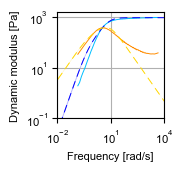

In [28]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq[::],G_storage_exp[::],fmt="-",label=r"$G'$, exp.",color="deepskyblue",linewidth=0.7)
ax1.errorbar(freq[::],G_loss_exp[::],fmt="-",label=r"$G''$, exp.",color="darkorange",linewidth=0.7)
   
line1=ax1.errorbar(omega_t_sim1_shift[::],storage_mod_sim1_avg_t_shift[::],fmt=":",label=r"$G'$, sim. rescal.",color="blue",linewidth=0.7)
ax1.fill_between(omega_t_sim1_shift[::], storage_mod_sim1_avg_t_shift[::] + storage_mod_all_t_avg_comp_stde_shift[::], storage_mod_sim1_avg_t_shift[::] - storage_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,facecolor="blue")
line1[0].set_dashes([8,5])  #[8, 5]  

#G_loss_medium=visc_T_sys=omega_t_sim1_shift*visc_T(273+20)

line2=ax1.errorbar(omega_t_sim1_shift[::],loss_mod_sim1_avg_t_shift[::],fmt=":",label=r"$G''-\omega \eta$, sim. rescal.",color="gold",linewidth=0.7)
ax1.fill_between(omega_t_sim1_shift[::], loss_mod_sim1_avg_t_shift[::] + loss_mod_all_t_avg_comp_stde_shift[::], loss_mod_sim1_avg_t_shift[::] - loss_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,facecolor="gold")
line2[0].set_dashes([8, 5])  #[8, 5]


#ax1.errorbar(omega_t_sim1_shift,omega_t_sim1_shift*visc_T_sys,fmt="-",label=r"$\omega \cdot \eta_{medium}$",color="blue")

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(10**0,1500)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_sim_10.pdf"
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_sim_test.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

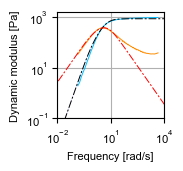

In [29]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq[::],G_storage_exp[::],fmt="-",label=r"$G'$, exp.",color="deepskyblue",linewidth=0.7)
ax1.errorbar(freq[::],G_loss_exp[::],fmt="-",label=r"$G''$, exp.",color="darkorange",linewidth=0.7)
   
line1=ax1.errorbar(omega_t_hydr_shift[::],storage_mod_mean_hydr_shift[::],fmt=":",label=r"$G'$, sim. rescal.",color="black",linewidth=0.7)
ax1.fill_between(omega_t_hydr_shift[::], storage_mod_mean_hydr_shift[::] + storage_mod_stde_hydr_shift[::], storage_mod_mean_hydr_shift[::] - storage_mod_stde_hydr_shift[::], alpha = 0.3 ,facecolor="blue")
line1[0].set_dashes([8, 2, 2, 2])  #[8, 5]  

#G_loss_medium=visc_T_sys=omega_t_sim1_shift*visc_T(273+20)

line2=ax1.errorbar(omega_t_hydr_shift[::],loss_mod_mean_hydr_shift[::],fmt=":",label=r"$G''-\omega \eta$, sim. rescal.",color="red",linewidth=0.7)
ax1.fill_between(omega_t_hydr_shift[::], loss_mod_mean_hydr_shift[::] + loss_mod_stde_hydr_shift[::], loss_mod_mean_hydr_shift[::] - loss_mod_stde_hydr_shift[::], alpha = 0.3 ,facecolor="gold")
line2[0].set_dashes([8, 2, 2, 2])  #[8, 5]


#ax1.errorbar(omega_t_sim1_shift,omega_t_sim1_shift*visc_T_sys,fmt="-",label=r"$\omega \cdot \eta_{medium}$",color="blue")

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(10**0,1500)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_sim_10.pdf"
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_sim_hydr1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

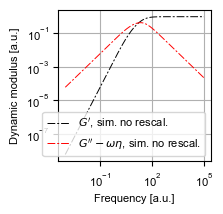

In [101]:
fig=plt.figure(figsize=(5/2.54,5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig.add_subplot(111)

#ax1.errorbar(freq[::],G_storage_exp[::],fmt="-",label=r"$G'$, exp.",color="deepskyblue",linewidth=0.7)
#ax1.errorbar(freq[::],G_loss_exp[::],fmt="-",label=r"$G''$, exp.",color="darkorange",linewidth=0.7)


line1=ax1.errorbar(omega_t_sim1[::],storage_mod_all_t_avg_comp_mean_hydr[::],fmt=":",label=r"$G'$, sim. no rescal.",color="black",linewidth=0.7)
#ax1.fill_between(omega_t_sim1[::], loss_mod_all_t_avg_comp_mean_hydr[::] + storage_mod_stde_hydr_shift[::], storage_mod_mean_hydr_shift[::] - storage_mod_stde_hydr_shift[::], alpha = 0.3 ,facecolor="blue")
line1[0].set_dashes([8, 2, 2, 2])  #[8, 5]  


#G_loss_medium=visc_T_sys=omega_t_sim1_shift*visc_T(273+20)

line2=ax1.errorbar(omega_t_sim1[::],loss_mod_all_t_avg_comp_mean_hydr[::],fmt=":",label=r"$G''-\omega \eta$, sim. no rescal.",color="red",linewidth=0.7)
#ax1.fill_between(omega_t_hydr_shift[::], loss_mod_mean_hydr_shift[::] + loss_mod_stde_hydr_shift[::], loss_mod_mean_hydr_shift[::] - loss_mod_stde_hydr_shift[::], alpha = 0.3 ,facecolor="gold")
line2[0].set_dashes([8, 2, 2, 2])  #[8, 5]


#line1=ax1.errorbar(omega_t_hydr_shift[::],storage_mod_mean_hydr_shift[::],fmt=":",label=r"$G'$, sim. rescal.",color="black",linewidth=0.7)
#ax1.fill_between(omega_t_hydr_shift[::], storage_mod_mean_hydr_shift[::] + storage_mod_stde_hydr_shift[::], storage_mod_mean_hydr_shift[::] - storage_mod_stde_hydr_shift[::], alpha = 0.3 ,facecolor="blue")
line1[0].set_dashes([8, 2, 2, 2])  #[8, 5]  

#G_loss_medium=visc_T_sys=omega_t_sim1_shift*visc_T(273+20)

#line2=ax1.errorbar(omega_t_hydr_shift[::],loss_mod_mean_hydr_shift[::],fmt=":",label=r"$G''-\omega \eta$, sim. rescal.",color="red",linewidth=0.7)
#ax1.fill_between(omega_t_hydr_shift[::], loss_mod_mean_hydr_shift[::] + loss_mod_stde_hydr_shift[::], loss_mod_mean_hydr_shift[::] - loss_mod_stde_hydr_shift[::], alpha = 0.3 ,facecolor="gold")
line2[0].set_dashes([8, 2, 2, 2])  #[8, 5]


#ax1.errorbar(omega_t_sim1_shift,omega_t_sim1_shift*visc_T_sys,fmt="-",label=r"$\omega \cdot \eta_{medium}$",color="blue")

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**0,1500)
#plt.xlim(10**-2,10**4)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_sim_10.pdf"

save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/example_hydr_opt_sim_no_rs_1.png"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
#plt.savefig(save_name_1,format="png",bbox_inches="tight", dpi=300)

<Figure size 137.795x137.795 with 0 Axes>

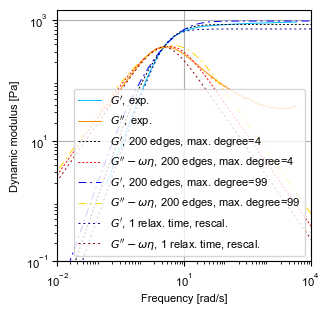

In [54]:


fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq[::],G_storage_exp[::],fmt="-",label=r"$G'$, exp.",color="deepskyblue",linewidth=0.7)
ax1.errorbar(freq[::],G_loss_exp[::],fmt="-",label=r"$G''$, exp.",color="darkorange",linewidth=0.7)
   
line1=ax1.errorbar(omega_t_sim1_shift_rd_1[::],storage_mod_gen_rd_1_shift[::],fmt=":",label=r"$G'$, 200 edges, max. degree=4 ",color="black",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], storage_mod_sim1_avg_t_shift[::] + storage_mod_all_t_avg_comp_stde_shift[::], storage_mod_sim1_avg_t_shift[::] - storage_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="black")
line1[0].set_dashes([2,2,2,2])  

line2=ax1.errorbar(omega_t_sim1_shift_rd_1[::],loss_mod_gen_rd_1_shift[::],fmt=":",label=r"$G''-\omega \eta$, 200 edges, max. degree=4 ",color="red",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], loss_mod_sim1_avg_t_shift[::] + loss_mod_all_t_avg_comp_stde_shift[::], loss_mod_sim1_avg_t_shift[::] - loss_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="red")
line2[0].set_dashes([2,2,2,2])  

#ax1.errorbar(omega_t_sim1_shift,omega_t_sim1_shift*visc_T_sys,fmt="-",label=r"$\omega \cdot \eta_{medium}$",color="blue")



   
line3=ax1.errorbar(omega_t_sim1_shift_rd_2[::],storage_mod_gen_rd_2_shift[::],fmt="-.",label=r"$G'$, 200 edges, max. degree=99 ",color="blue",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], storage_mod_sim1_avg_t_shift[::] + storage_mod_all_t_avg_comp_stde_shift[::], storage_mod_sim1_avg_t_shift[::] - storage_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="black")
line3[0].set_dashes([8, 4, 2, 4])  

line4=ax1.errorbar(omega_t_sim1_shift_rd_2[::],loss_mod_gen_rd_2_shift[::],fmt="-.",label=r"$G''-\omega \eta$, 200 edges, max. degree=99 ",color="gold",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], loss_mod_sim1_avg_t_shift[::] + loss_mod_all_t_avg_comp_stde_shift[::], loss_mod_sim1_avg_t_shift[::] - loss_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="red")
line4[0].set_dashes([8, 4, 2, 4])  



line5=ax1.errorbar(omega_t_sim1_shift_r1[::],storage_mod_r1_shift[::],fmt=":",label=r"$G'$, 1 relax. time, rescal.",color="darkblue",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], storage_mod_sim1_avg_t_shift[::] + storage_mod_all_t_avg_comp_stde_shift[::], storage_mod_sim1_avg_t_shift[::] - storage_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="black")
line5[0].set_dashes([2, 3])  

line6=ax1.errorbar(omega_t_sim1_shift_r1[::],loss_mod_r1_shift[::],fmt=":",label=r"$G''-\omega \eta$, 1 relax. time, rescal.",color="darkred",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], loss_mod_sim1_avg_t_shift[::] + loss_mod_all_t_avg_comp_stde_shift[::], loss_mod_sim1_avg_t_shift[::] - loss_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="red")
line6[0].set_dashes([2, 3])   



fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(10**0,1500)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")




save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_theo_1_3.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")




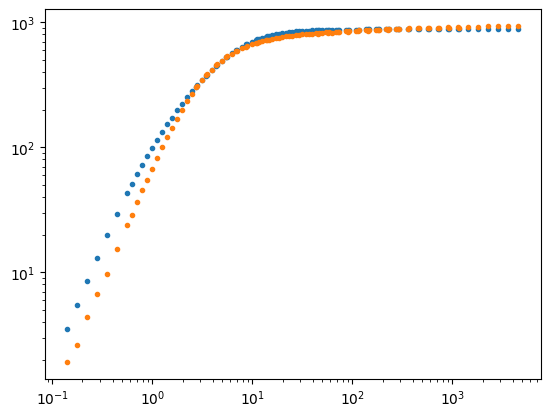

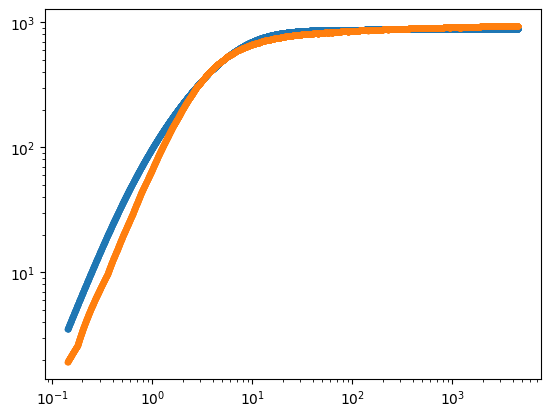

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9881868745082691
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9760587627162047
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9915648219727285
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9740207666537554
With same log spaced x range, mean absolute percentage error: 0.20736177109758727
With same log spaced x range, mean absolute log error: 0.15969213664780546
Integral mean absolute log error: 0.160765662410161


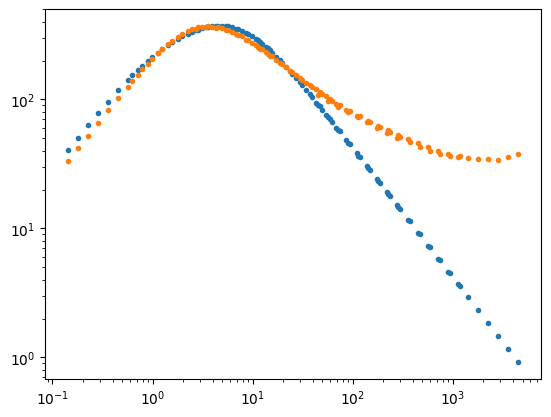

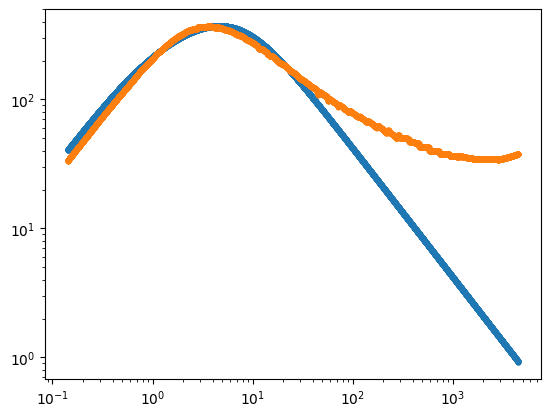

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9442144464325649
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -0.7667579723321398
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9448727369444248
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.5034905374812246
With same log spaced x range, mean absolute percentage error: 0.37306364411339626
With same log spaced x range, mean absolute log error: 0.8012634154246447
Integral mean absolute log error: 0.8009465521818798


In [199]:
#Quantify similarity between prediction and experiment
calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_storage_exp, x2=omega_t_sim1_shift,y2=storage_mod_sim1_avg_t_shift,X_low=5* 10**-10,X_high=5* 10**10)

calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_loss_exp, x2=omega_t_sim1_shift,y2=loss_mod_sim1_avg_t_shift,X_low=5* 10**-10,X_high=5* 10**10)

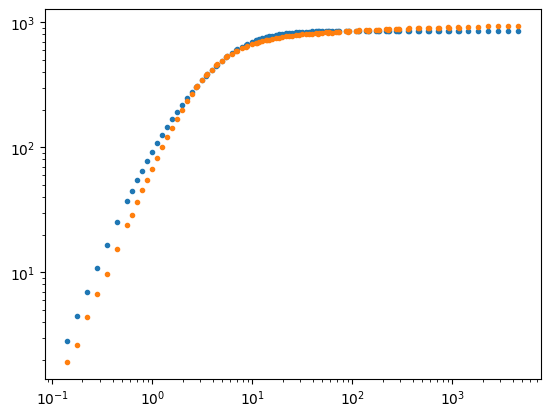

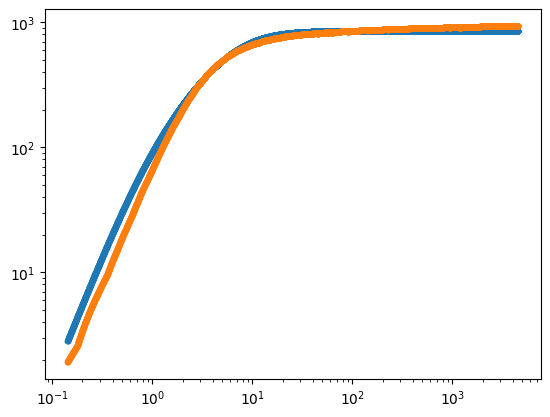

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9890168563200268
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9863017266457355
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9900499244923922
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9855058585973544
With same log spaced x range, mean absolute percentage error: 0.15255992341306232
With same log spaced x range, mean absolute log error: 0.12848532985216785
Integral mean absolute log error: 0.1295668472740065


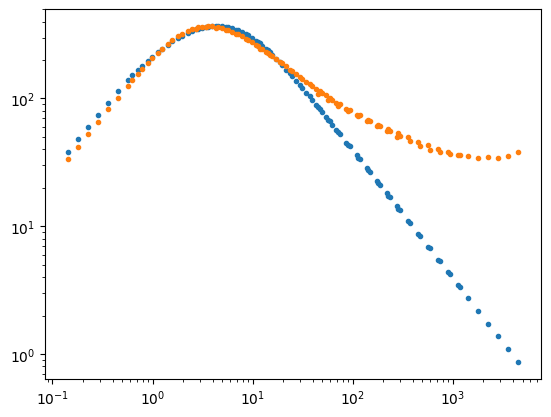

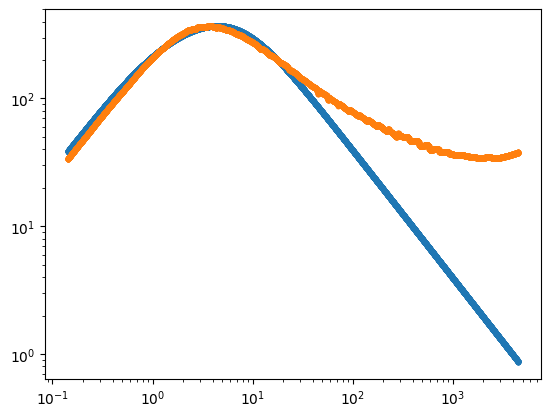

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9449643837858238
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -0.8853160876392936
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9457129716338339
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.645168779375437
With same log spaced x range, mean absolute percentage error: 0.3722691711022129
With same log spaced x range, mean absolute log error: 0.8229986472632745
Integral mean absolute log error: 0.8226733497881923


In [200]:
calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_storage_exp, x2=omega_t_sim1_shift_rd_1,y2=storage_mod_gen_rd_1_shift,X_low=5* 10**-10,X_high=5* 10**10)

calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_loss_exp, x2=omega_t_sim1_shift_rd_1,y2=loss_mod_gen_rd_1_shift,X_low=5* 10**-10,X_high=5* 10**10)

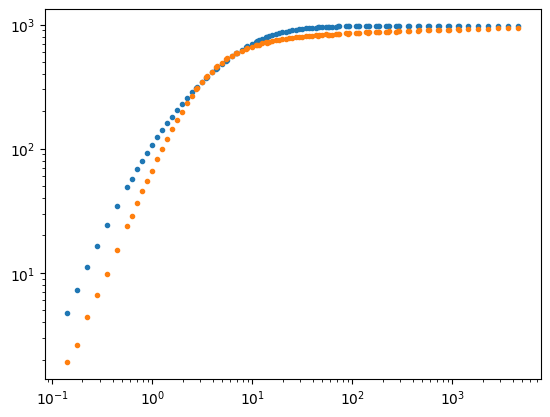

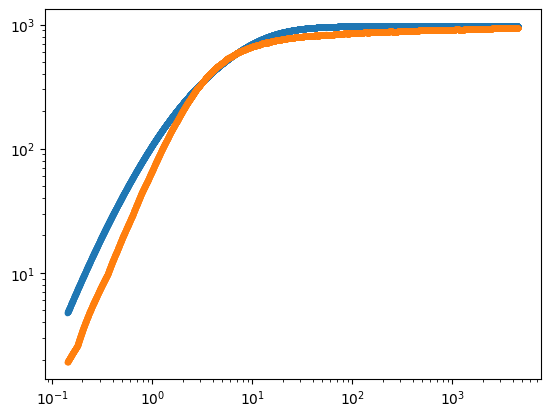

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9306418974042483
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9555719443163503
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9591817363563561
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9529454304897299
With same log spaced x range, mean absolute percentage error: 0.3287759274122522
With same log spaced x range, mean absolute log error: 0.23441520161788154
Integral mean absolute log error: 0.23545420418590732


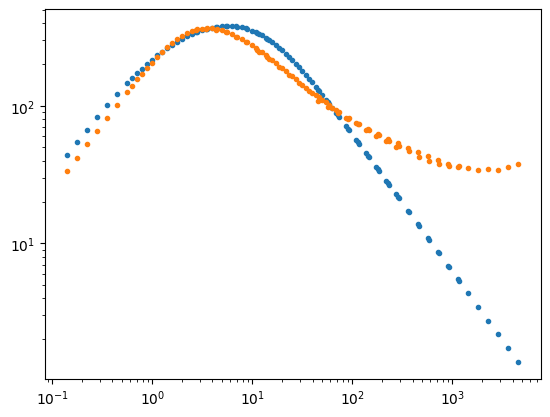

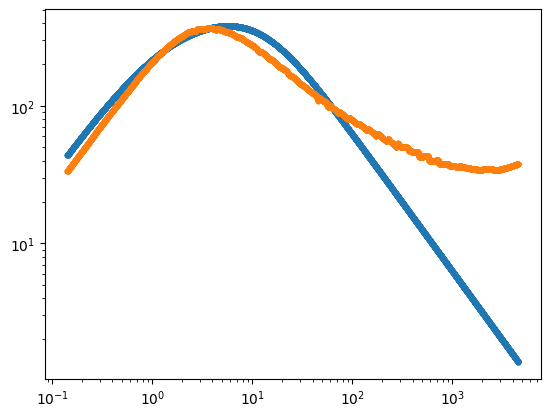

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8840211271819377
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -0.17962121830247435
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.903487195407649
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -0.7516657872137098
With same log spaced x range, mean absolute percentage error: 0.36646488221002294
With same log spaced x range, mean absolute log error: 0.6696773293491579
Integral mean absolute log error: 0.6694567393808503


In [208]:
calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_storage_exp, x2=omega_t_sim1_shift_rd_2,y2=storage_mod_gen_rd_2_shift,X_low=5* 10**-10,X_high=5* 10**10)

calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_loss_exp, x2=omega_t_sim1_shift_rd_2,y2=loss_mod_gen_rd_2_shift,X_low=5* 10**-10,X_high=5* 10**10)

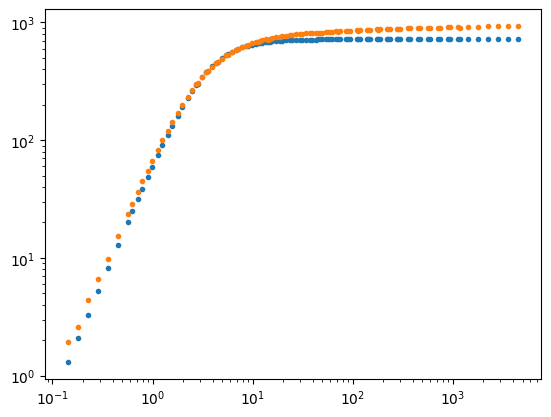

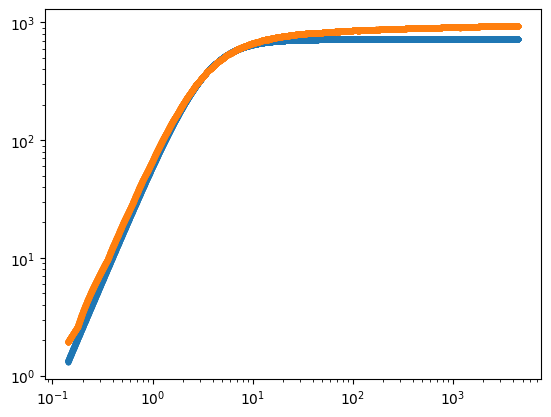

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8730940270435883
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9868940201619844
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8900508247015733
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9895740721408339
With same log spaced x range, mean absolute percentage error: 0.13860495566063727
With same log spaced x range, mean absolute log error: 0.1531138727086299
Integral mean absolute log error: 0.15204188269840976


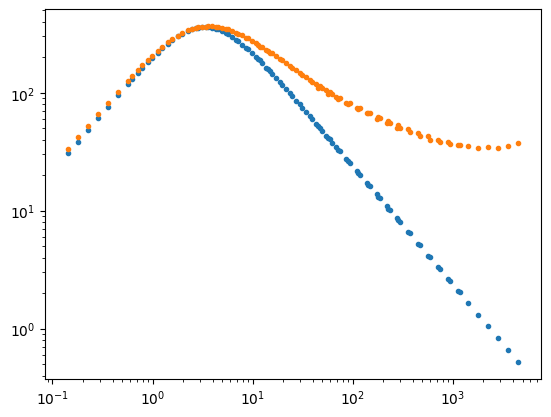

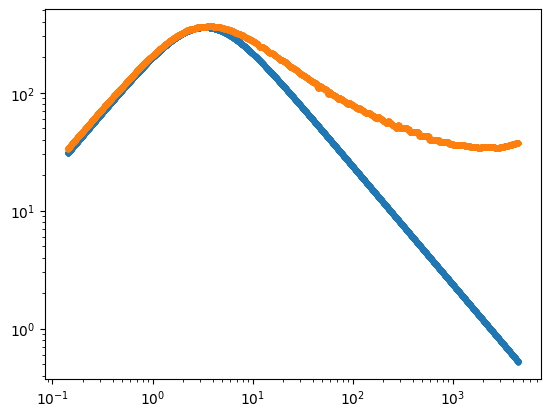

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8359570582696105
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.102501317457711
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8656702820791219
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -3.0163514718591786
With same log spaced x range, mean absolute percentage error: 0.45525857474456005
With same log spaced x range, mean absolute log error: 1.10227165170577
Integral mean absolute log error: 1.1019080148188378


In [209]:
calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_storage_exp, x2=omega_t_sim1_shift_r1,y2=storage_mod_r1_shift,X_low=5* 10**-10,X_high=5* 10**10)

calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_loss_exp, x2=omega_t_sim1_shift_r1,y2=loss_mod_r1_shift,X_low=5* 10**-10,X_high=5* 10**10)

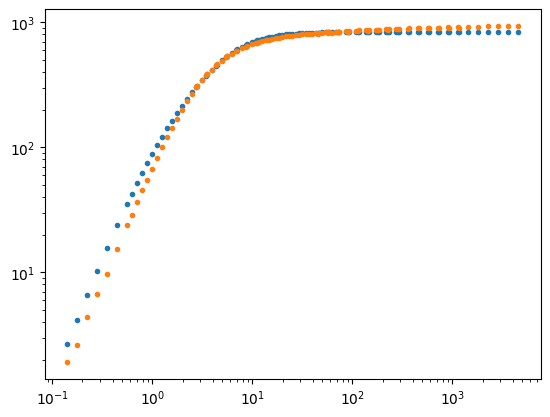

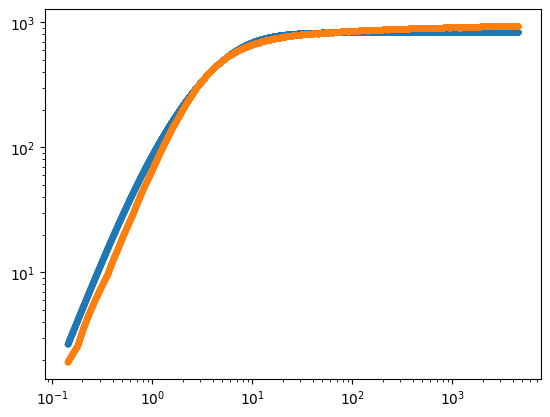

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9848446823123385
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9890572920136301
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9844219737029503
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9884221282289825
With same log spaced x range, mean absolute percentage error: 0.13919695245570535
With same log spaced x range, mean absolute log error: 0.1218468469923441
Integral mean absolute log error: 0.12293269243665127


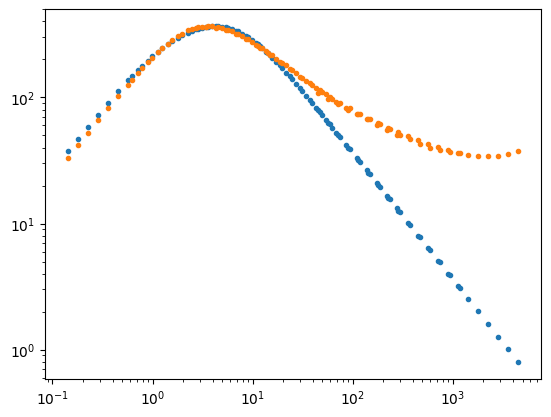

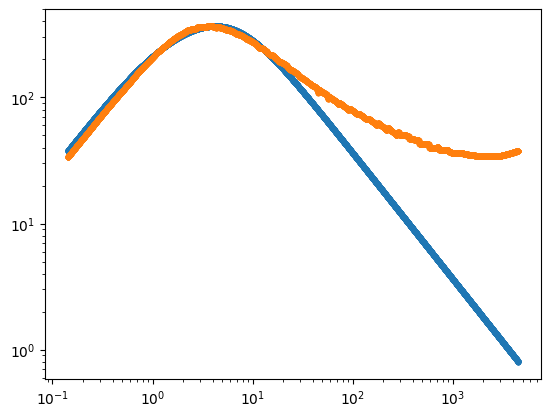

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9402832261129096
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.0459248233748384
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9422301147841663
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.8344010738586896
With same log spaced x range, mean absolute percentage error: 0.3788209333616404
With same log spaced x range, mean absolute log error: 0.8579144556822769
Integral mean absolute log error: 0.8575565413069464


In [71]:
#Quantify similarity between prediction and experiment
calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_storage_exp, x2=omega_t_hydr_shift,y2=storage_mod_mean_hydr_shift,X_low=5* 10**-10,X_high=5* 10**10)

calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_loss_exp, x2=omega_t_hydr_shift,y2=loss_mod_mean_hydr_shift,X_low=5* 10**-10,X_high=5* 10**10)

# Comparison to exp data with different valency

In [15]:


#three arms
exp_data_dyn_mod_v3=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_conrad_et_al/3_arm_500uM_MasterCurve.dat",sep=",",header=None)
exp_data_dyn_mod_v3.columns=["freq.","G'","G''"]

freq_v3=exp_data_dyn_mod_v3["freq."].to_numpy()
G_storage_exp_v3=exp_data_dyn_mod_v3["G'"].to_numpy()
G_loss_exp_v3=exp_data_dyn_mod_v3["G''"].to_numpy()

#four arms
exp_data_dyn_mod_v4=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_conrad_et_al/FrequencySweep_4ArmDNAns_490uM.csv",sep=",",header=None)
exp_data_dyn_mod_v4.columns=["freq.","G'","G''"]

freq_v4=exp_data_dyn_mod_v4["freq."].to_numpy()
G_storage_exp_v4=exp_data_dyn_mod_v4["G'"].to_numpy()
G_loss_exp_v4=exp_data_dyn_mod_v4["G''"].to_numpy()

#five arms
exp_data_dyn_mod_v5=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_conrad_et_al/5_arm_490uM_MasterCurve(2).dat",sep=",",header=None)
exp_data_dyn_mod_v5.columns=["freq.","G'","G''"]

freq_v5=exp_data_dyn_mod_v5["freq."].to_numpy()
G_storage_exp_v5=exp_data_dyn_mod_v5["G'"].to_numpy()
G_loss_exp_v5=exp_data_dyn_mod_v5["G''"].to_numpy()

#six arms
exp_data_dyn_mod_v6=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_conrad_et_al/6_arm_450uM_MasterCurve.dat",sep=",",header=None)
exp_data_dyn_mod_v6.columns=["freq.","G'","G''"]

freq_v6=exp_data_dyn_mod_v6["freq."].to_numpy()
G_storage_exp_v6=exp_data_dyn_mod_v6["G'"].to_numpy()
G_loss_exp_v6=exp_data_dyn_mod_v6["G''"].to_numpy()

In [16]:
#three arms, Palombo et al 2025
exp_data_dyn_mod_v3b=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_palombo_et_al/2022.09.01_0.5mM_02_20C_FreqSweep.dat", delim_whitespace=True)


freq_v3b=exp_data_dyn_mod_v3b["Frequency(Hz)"].to_numpy()[::-1]
G_storage_exp_v3b=exp_data_dyn_mod_v3b["Shear_modulus_(elastic_component)(Pa)"].to_numpy()[::-1]
G_loss_exp_v3b=exp_data_dyn_mod_v3b["Shear_modulus_(viscous_component)(Pa)"].to_numpy()[::-1]


#the data is soparse around, need to interpolate to make reasonable predictions for cross over point
freq_v3b_os=np.geomspace(freq_v3b[0],freq_v3b[-1],10000)

G_storage_exp_v3b_os = np.interp(freq_v3b_os, freq_v3b, G_storage_exp_v3b)
G_loss_exp_v3b_os = np.interp(freq_v3b_os, freq_v3b, G_loss_exp_v3b)

/tmp/ipykernel_106/2524412780.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  exp_data_dyn_mod_v3b=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_palombo_et_al/2022.09.01_0.5mM_02_20C_FreqSweep.dat", delim_whitespace=True)


<Figure size 137.795x137.795 with 0 Axes>

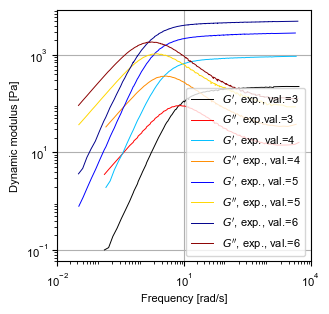

In [17]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq_v3[::],G_storage_exp_v3[::],fmt="-",label=r"$G'$, exp., val.=3",color="black",linewidth=0.7)
ax1.errorbar(freq_v3[::],G_loss_exp_v3[::],fmt="-",label=r"$G''$, exp.val.=3",color="red",linewidth=0.7)

ax1.errorbar(freq_v4[::],G_storage_exp_v4[::],fmt="-",label=r"$G'$, exp. val.=4",color="deepskyblue",linewidth=0.7)
ax1.errorbar(freq_v4[::],G_loss_exp_v4[::],fmt="-",label=r"$G''$, exp., val.=4",color="darkorange",linewidth=0.7)

ax1.errorbar(freq_v5[::],G_storage_exp_v5[::],fmt="-",label=r"$G'$, exp., val.=5",color="blue",linewidth=0.7)
ax1.errorbar(freq_v5[::],G_loss_exp_v5[::],fmt="-",label=r"$G''$, exp., val.=5",color="gold",linewidth=0.7)

ax1.errorbar(freq_v6[::],G_storage_exp_v6[::],fmt="-",label=r"$G'$, exp., val.=6",color="darkblue",linewidth=0.7)
ax1.errorbar(freq_v6[::],G_loss_exp_v6[::],fmt="-",label=r"$G''$, exp., val.=6",color="darkred",linewidth=0.7)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**0,1500)
#plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

Intersection exp dataset 1: omega: 7.58082 dynamic mod. 91.50695
Intersection sim dataset 1: omega: 3.30506 dynamic mod. 359.08500000000004
Intersection exp dataset 1: omega: 7.58082 dynamic mod. 91.50695
Intersection sim dataset 1: omega: 2.01155 dynamic mod. 1051.405
Intersection exp dataset 1: omega: 7.58082 dynamic mod. 91.50695
Intersection sim dataset 1: omega: 1.48807 dynamic mod. 1856.02


<Figure size 137.795x137.795 with 0 Axes>

<Figure size 326.772x326.772 with 0 Axes>

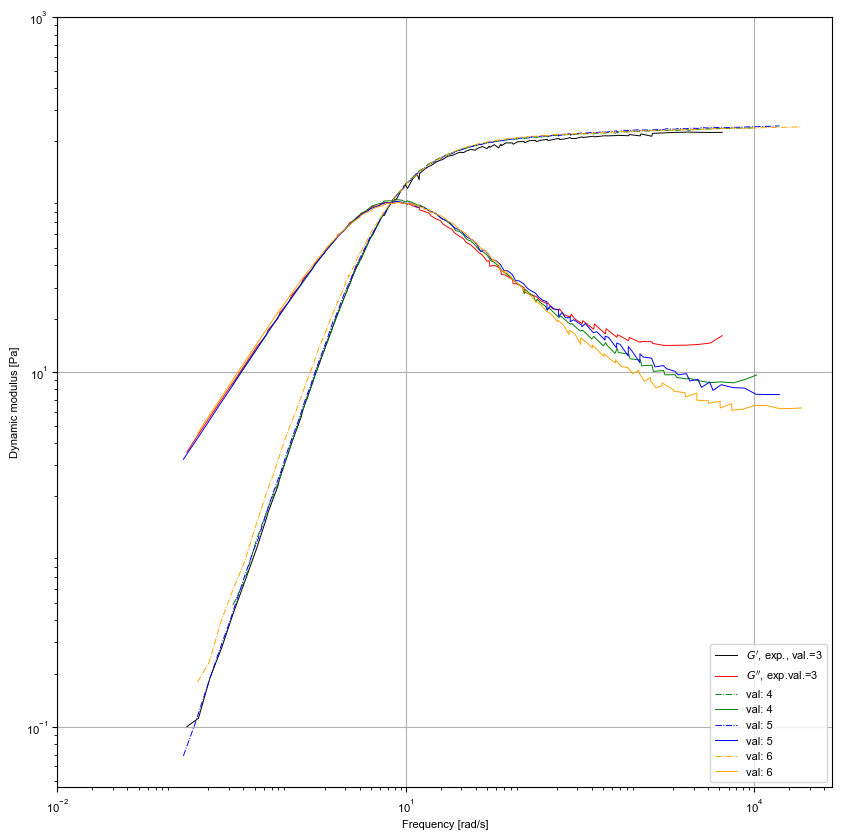

In [21]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))
fig=plt.figure(figsize=(10,10))

ax1 = fig.add_subplot(111)



freq_list_exp=[freq_v3,freq_v4,freq_v5,freq_v6]
G_storage_list_exp=[G_storage_exp_v3,G_storage_exp_v4,G_storage_exp_v5,G_storage_exp_v6]
G_loss_list_exp=[G_loss_exp_v3,G_loss_exp_v4,G_loss_exp_v5,G_loss_exp_v6]
colors_exp_list=["black","green","blue","orange"]
colors_exp_list2=["black","green","blue","orange"]
label_exp_list=["val:3","val: 4", "val: 5", "val: 6"]

ax1.errorbar(freq_v3[::],G_storage_exp_v3[::],fmt="-",label=r"$G'$, exp., val.=3",color="black",linewidth=0.7)
ax1.errorbar(freq_v3[::],G_loss_exp_v3[::],fmt="-",label=r"$G''$, exp.val.=3",color="red",linewidth=0.7)


for i in range(len(freq_list_exp[1:])):
    i=i+1

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=freq_list_exp[0], y1=G_storage_list_exp[0], x2=freq_list_exp[0], y2=G_loss_list_exp[0])[0]
    print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=freq_list_exp[i], y1=G_storage_list_exp[i], x2=freq_list_exp[i], y2=G_loss_list_exp[i])[0]
    print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    freq_list_exp_shift=np.array(freq_list_exp[i])*omega_inters_target_1/omega_inters_1
    G_storage_list_exp_shift=np.array(G_storage_list_exp[i])*dyn_mod_inters_target_1/dyn_mod_inters_1
    G_loss_list_exp_shift=np.array(G_loss_list_exp[i])*dyn_mod_inters_target_1/dyn_mod_inters_1

    ax1.errorbar(freq_list_exp_shift[::],G_storage_list_exp_shift[::],fmt="-.",label=label_exp_list[i],color=colors_exp_list[i],linewidth=0.7)
    ax1.errorbar(freq_list_exp_shift[::],G_loss_list_exp_shift[::],fmt="-",label=label_exp_list[i],color=colors_exp_list2[i],linewidth=0.7)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**0,1500)
#plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

1200.0
1600.0
2000.0
2400.0
CPU times: user 32.7 s, sys: 38.4 s, total: 1min 11s
Wall time: 8.51 s


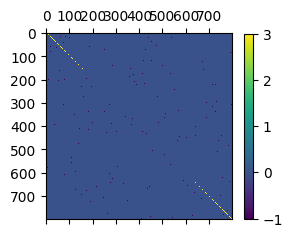

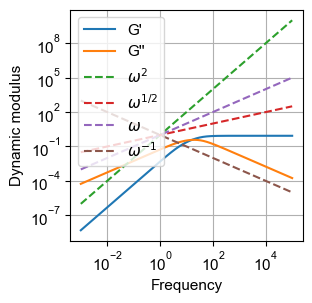

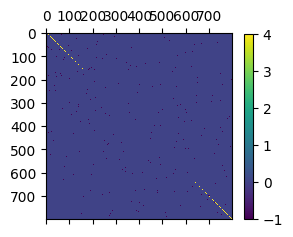

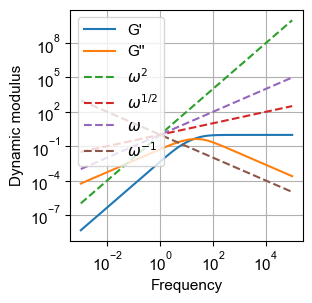

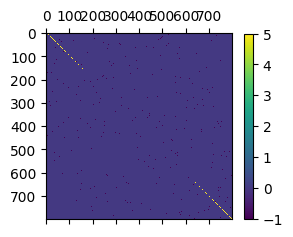

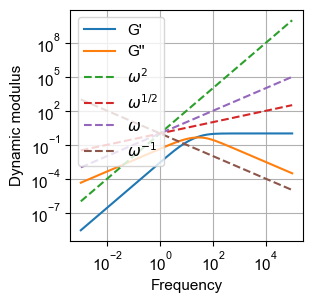

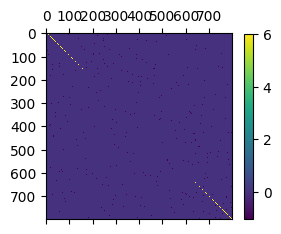

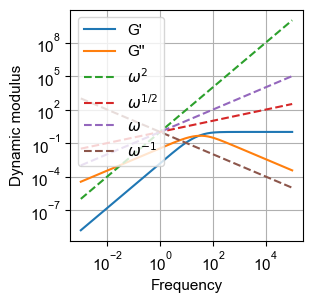

In [60]:
%%time
#generate theoretical graphs with matching valency and option to define max and min relax time
omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)
#number of nodes
num_nodes_list=[800,800,800,800]  #[800,800,800,800] #[100,100,100,100] #
#degree of each node
m_list=[3,4,5,6] #[3,4,5,6] 
#number of edges to add
p_list=[1200,1600,2000,2400] #[1200,1600,2000,2400]  #[150,200,250,300]   #
#random seed
rs_list=[1,1,1,1]

storage_mod_list_rd, loss_mod_list_rd, relaxation_mod_list_rd,relax_times_list_rd=theo_graph_gen(num_nodes_list,m_list,p_list,rs_list,omega_t_sim1,t_sim1,lim_to_one_relax_time=None,lower_t_lim=0,upper_t_lim=0.2)#0.2
#pre_mod_list1=[1,1,1,1]
#pre_tau_list1=[1,1,1,1]
#storage_mod_list_rd, loss_mod_list_rd, relaxation_mod_list_rd,relax_times_list_rd=theo_graph_gen2(num_nodes_list,m_list,p_list,rs_list,omega_t_sim1,t_sim1,pre_tau_list=pre_tau_list1,pre_mod_list=pre_mod_list1,lim_to_one_relax_time=None,lower_t_lim=0,upper_t_lim=5000)#0.2


Intersection 1: omega: 15.856913514930753 dynamic mod. 0.37366748851405884
Intersection i: omega: 18.3773430159208 dynamic mod. 0.41292327618447927
Intersection 1: omega: 15.856913514930753 dynamic mod. 0.37366748851405884
Intersection i: omega: 23.355373970636908 dynamic mod. 0.4385267061533418
Intersection 1: omega: 15.856913514930753 dynamic mod. 0.37366748851405884
Intersection i: omega: 29.681847524734387 dynamic mod. 0.45283896817201463


<Figure size 137.795x137.795 with 0 Axes>

<Figure size 326.772x326.772 with 0 Axes>

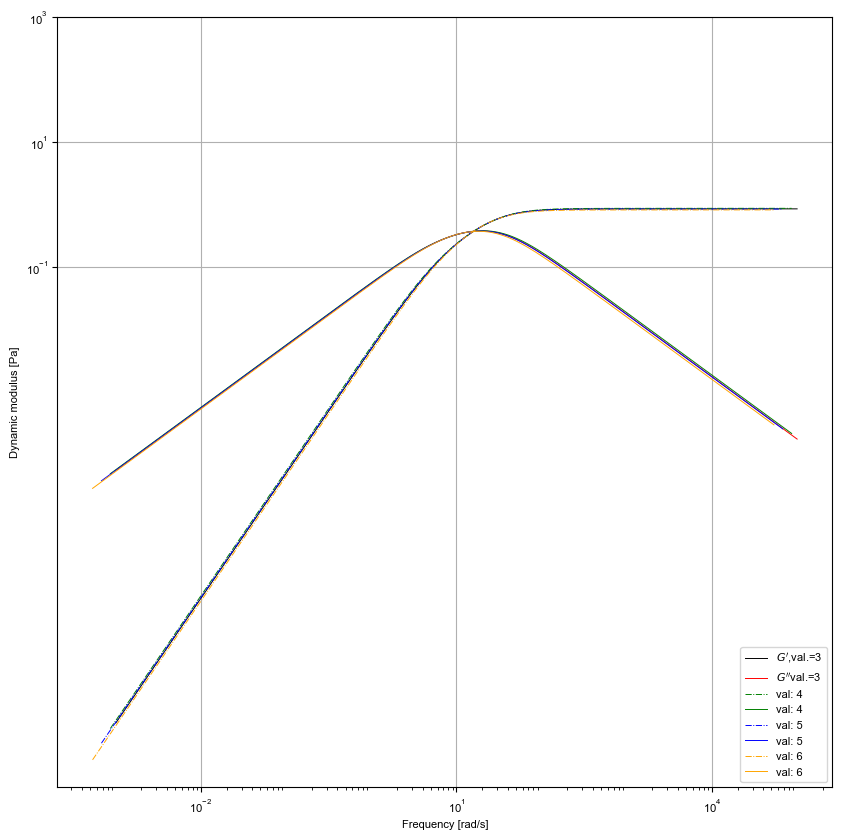

In [61]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))
fig=plt.figure(figsize=(10,10))

ax1 = fig.add_subplot(111)


colors_exp_list=["black","green","blue","orange"]
colors_exp_list2=["black","green","blue","orange"]
label_exp_list=["val:3","val: 4", "val: 5", "val: 6"]

ax1.errorbar(omega_t_sim1[::],storage_mod_list_rd[0],fmt="-",label=r"$G'$,val.=3",color="black",linewidth=0.7)
ax1.errorbar(omega_t_sim1[::],loss_mod_list_rd[0],fmt="-",label=r"$G''$val.=3",color="red",linewidth=0.7)


for i in range(len(storage_mod_list_rd[1:])):
    i=i+1

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=omega_t_sim1, y1=storage_mod_list_rd[0], x2=omega_t_sim1, y2=loss_mod_list_rd[0])[0]
    print("Intersection 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1, y1=storage_mod_list_rd[i], x2=omega_t_sim1, y2=loss_mod_list_rd[i])[0]
    print("Intersection i:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    omega_t_sim1_shift=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_1
    storage_mod_list_rd_shift=np.array(storage_mod_list_rd[i])*dyn_mod_inters_target_1/dyn_mod_inters_1
    loss_mod_list_rd_shift=np.array(loss_mod_list_rd[i])*dyn_mod_inters_target_1/dyn_mod_inters_1

    ax1.errorbar(omega_t_sim1_shift[::],storage_mod_list_rd_shift[::],fmt="-.",label=label_exp_list[i],color=colors_exp_list[i],linewidth=0.7)
    ax1.errorbar(omega_t_sim1_shift[::],loss_mod_list_rd_shift[::],fmt="-",label=label_exp_list[i],color=colors_exp_list2[i],linewidth=0.7)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**0,1500)
#plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

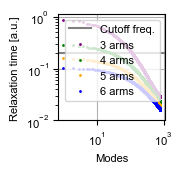

In [36]:
# relaxation times of graphs
#storage_mod_list_rd=[storage_mod_list_rd[3] for i in range(len(storage_mod_list_rd))] 
#loss_mod_list_rd=[loss_mod_list_rd[3] for i in range(len(loss_mod_list_rd))]

labels_relax_time_e=["3 arms","4 arms","5 arms","6 arms"]
colors_relax_times_e=["purple","green","orange","blue"]
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
#fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))

ax1 = fig.add_subplot(111)
for i in range(len(relax_times_list_rd)):
    ax1.errorbar(np.arange(0,len(relax_times_list_rd[i])),relax_times_list_rd[i],fmt=".",label=labels_relax_time_e[i],markersize=2,color=colors_relax_times_e[i])
     #ax1.errorbar(np.arange(0,len(relax_times_list_rd[i])),relax_times_list_rd[i]*1/mult_factor_freq_rd_shift[i],fmt=".",label=labels_relax_time_e[i])
     #print(np.mean(1/(relax_times_list_rd[i]*1/mult_factor_freq_rd_shift[i])))
fs1=8
ax1.axhline(0.2,color="grey",label="Cutoff freq.")
#ax1.axhline(0.05)

'''color_cf1=["blue","orange","green","red"]
for i in range(len(cross_over_freq_exp)):
    ax1.axhline(1/cross_over_freq_exp[i],label=labels_relax_time_e[i],color=color_cf1[i])
'''
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**-1,10**4)
#plt.xlim(10**-2,10**4)
plt.xticks([10**1,10**3],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-2,10**-1,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Relaxation time [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Modes",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="upper right")

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/relax_time_800nodes.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

R^2 for storage mod


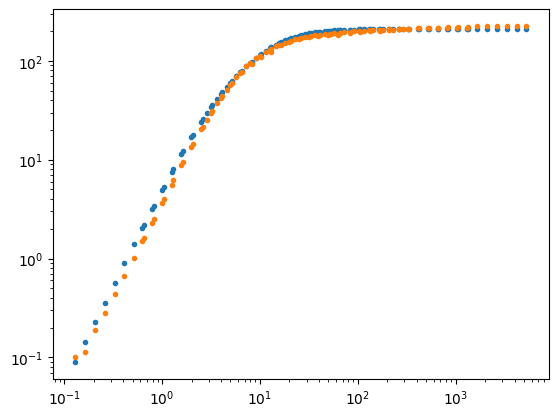

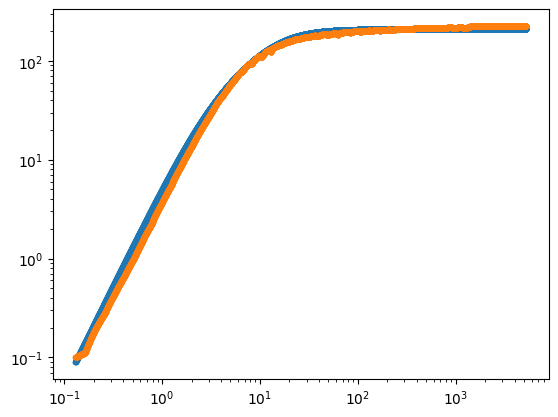

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.989532462102553
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9954264267108722
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9919485936542123
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9962404071361121
With same log spaced x range, mean absolute percentage error: 0.1167629945416845
With same log spaced x range, mean absolute log error: 0.10607953021076523
Integral mean absolute log error: 0.10755021587379995
R^2 for loss mod


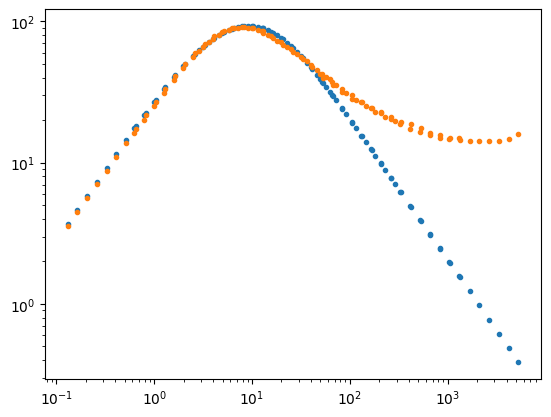

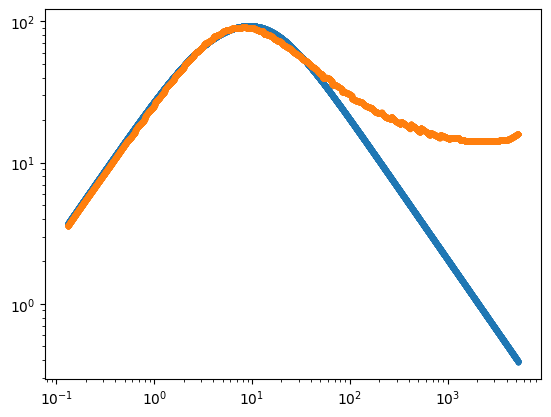

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9146915734759737
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -0.7969227249282713
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9013113265454193
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.4200887077903284
With same log spaced x range, mean absolute percentage error: 0.3218524544225184
With same log spaced x range, mean absolute log error: 0.720172356197331
Integral mean absolute log error: 0.7196906552180438
R^2 for storage mod


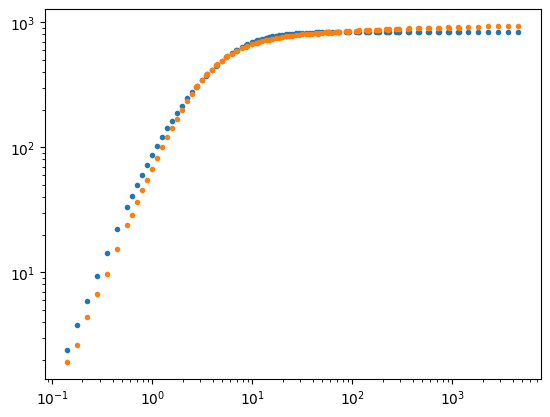

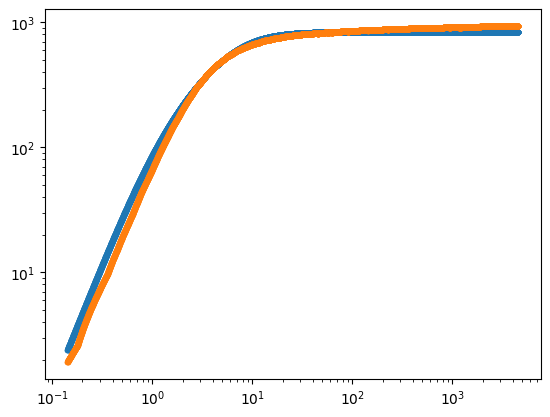

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9863259882136789
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.992066373033842
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9859910243598595
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.991949543358432
With same log spaced x range, mean absolute percentage error: 0.11735838363652487
With same log spaced x range, mean absolute log error: 0.10610322430041624
Integral mean absolute log error: 0.1071944884109254
R^2 for loss mod


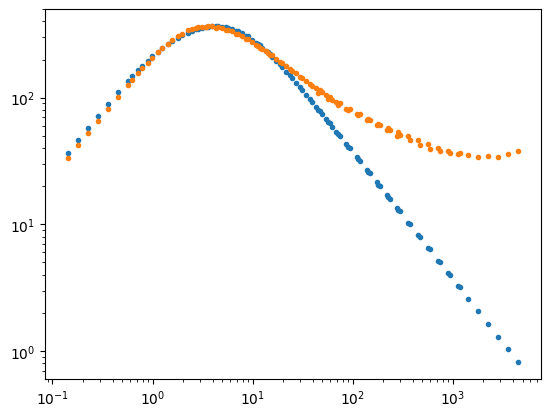

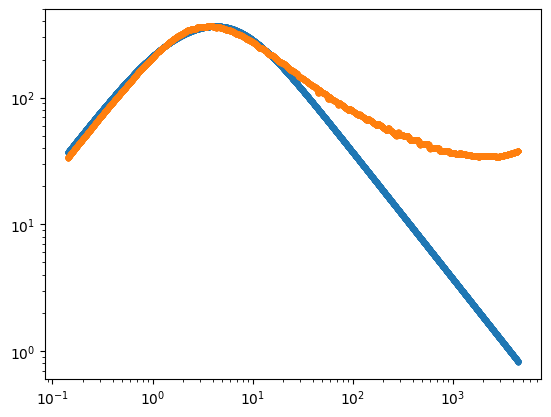

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9426932683546735
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -0.9969790283582067
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9441763472038096
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.7768418045366996
With same log spaced x range, mean absolute percentage error: 0.3735849680252518
With same log spaced x range, mean absolute log error: 0.8445155725775371
Integral mean absolute log error: 0.8441675198880368
R^2 for storage mod


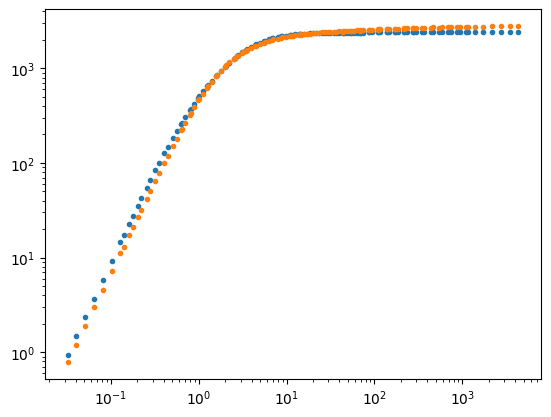

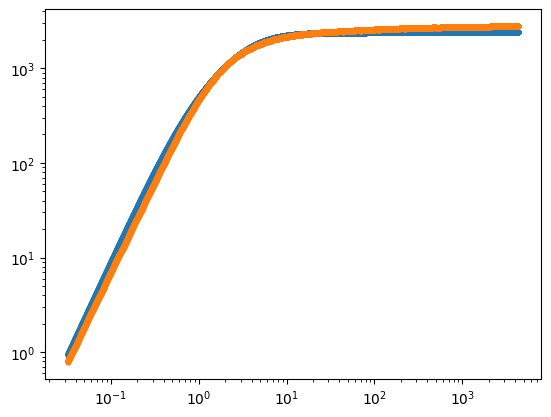

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9749547196235122
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9959190003351374
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9727497762182413
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9964399486879292
With same log spaced x range, mean absolute percentage error: 0.11829956016736629
With same log spaced x range, mean absolute log error: 0.11285325377480199
Integral mean absolute log error: 0.11405889045222531
R^2 for loss mod


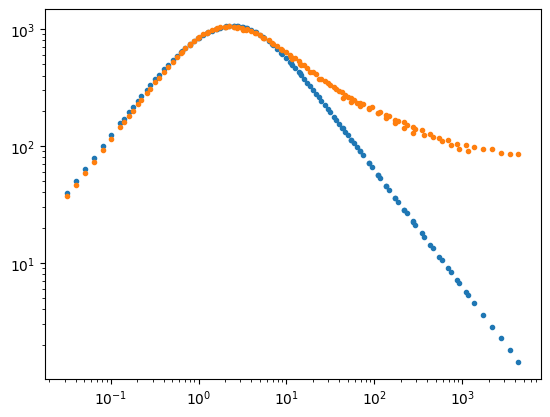

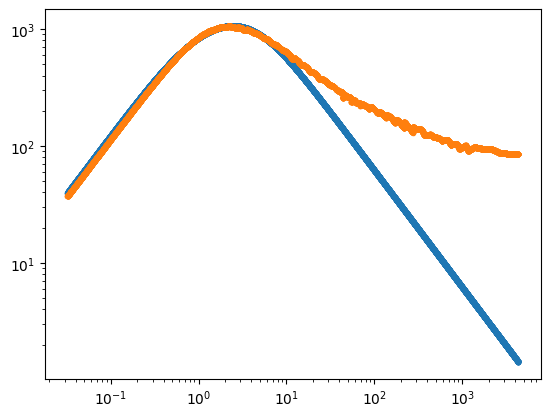

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9267454363706894
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.157944613445546
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9312065533131836
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.7873051757607081
With same log spaced x range, mean absolute percentage error: 0.38605055294540586
With same log spaced x range, mean absolute log error: 0.9392846499938629
Integral mean absolute log error: 0.9387854309148329
R^2 for storage mod


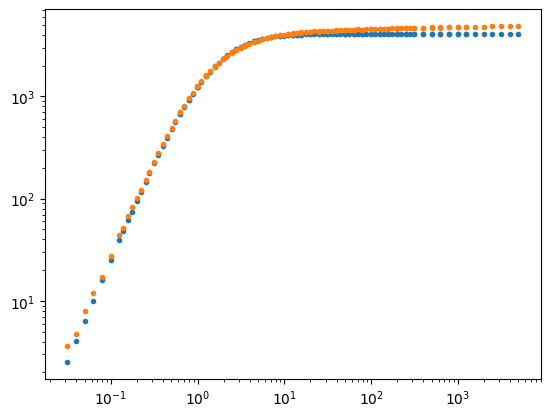

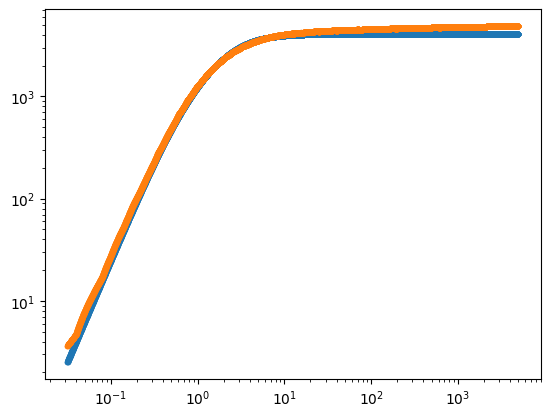

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9548847616188533
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.996334655754158
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9562291849099158
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9969428674276808
With same log spaced x range, mean absolute percentage error: 0.08659854755485596
With same log spaced x range, mean absolute log error: 0.09260949926265288
Integral mean absolute log error: 0.0915762260343426
R^2 for loss mod


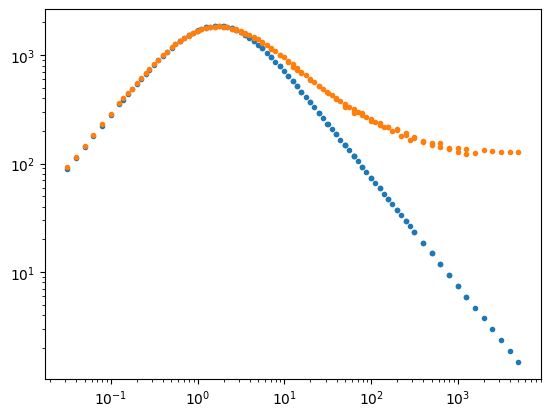

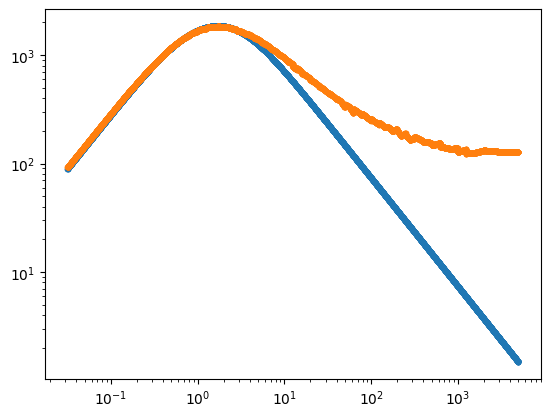

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.939718422786641
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.166899297031832
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9445293943797209
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.0096468932643528
With same log spaced x range, mean absolute percentage error: 0.40550857984051797
With same log spaced x range, mean absolute log error: 1.0323609004991217
Integral mean absolute log error: 1.0319084471869957


In [62]:
# evaluate similarity of prediction to exp data
storage_mod_exp_list=[G_storage_exp_v3,G_storage_exp_v4,G_storage_exp_v5,G_storage_exp_v6]
loss_mod_exp_list=[G_loss_exp_v3,G_loss_exp_v4,G_loss_exp_v5,G_loss_exp_v6]
freq_list=[freq_v3,freq_v4,freq_v5,freq_v6]

omega_t_list_rd=[omega_t_sim1 for e in range(len(storage_mod_list_rd))]

storage_mod_list_rd_shift, loss_mod_list_rd_shift, omega_t_list_rd_shift,cross_over_freq_exp,cross_over_mod_exp,mult_factor_freq_rd_shift=shift_mod(storage_mod_list=storage_mod_list_rd,loss_mod_list=loss_mod_list_rd,omega_t_list=omega_t_list_rd,  storage_mod_exp_list=storage_mod_exp_list,loss_mod_exp_list=loss_mod_exp_list,freq_list=freq_list,X_low=5* 10**-10,X_high=5* 10**10)

R^2 for storage mod


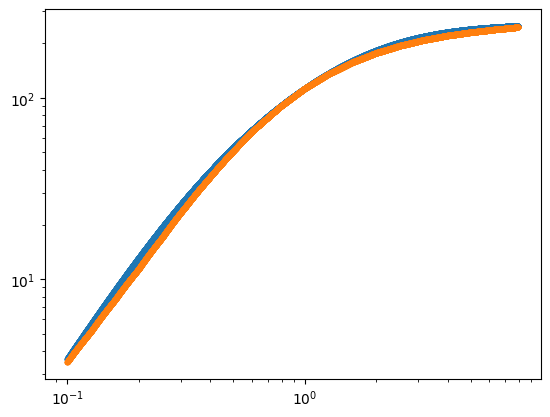

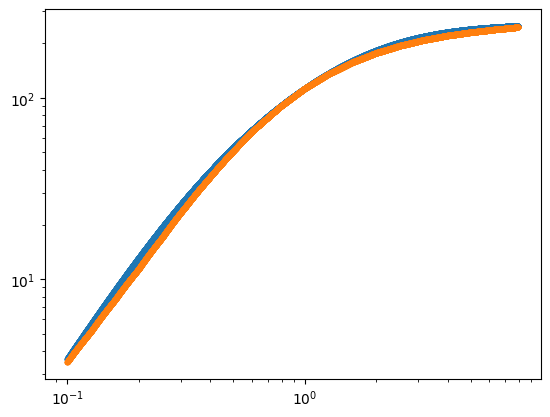

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9965303911559241
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.997445122012949
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9965303911559241
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.997445122012949
With same log spaced x range, mean absolute percentage error: 0.05478601831941426
With same log spaced x range, mean absolute log error: 0.05256201617792531
Integral mean absolute log error: 0.0525544192264234
R^2 for loss mod


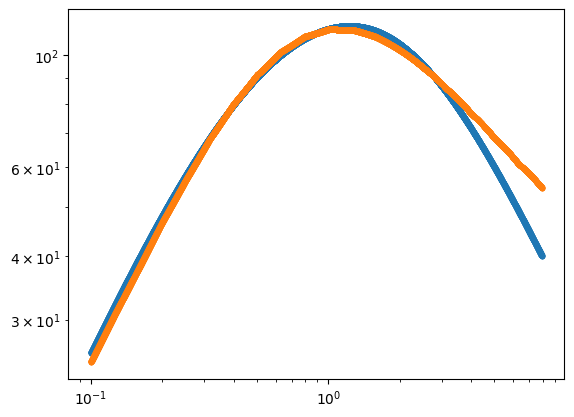

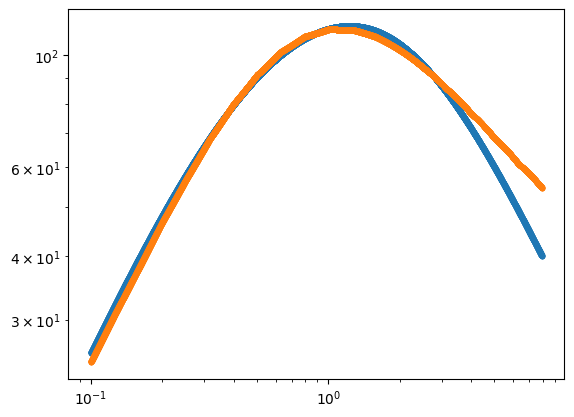

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9706611162620672
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9607585301616532
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9706611162620672
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9607585301616532
With same log spaced x range, mean absolute percentage error: 0.04366025455197142
With same log spaced x range, mean absolute log error: 0.046236378287285815
Integral mean absolute log error: 0.046231004815948794


In [38]:
storage_mod_list_rd_shift_mr, loss_mod_list_rd_shift_mr, omega_t_list_rd_shift_mr,cross_over_freq_exp_mr,cross_over_mod_exp_mr,mult_factor_freq_rd_shift_mr=shift_mod(storage_mod_list=[storage_mod_list_rd[0]],loss_mod_list=[loss_mod_list_rd[0]],omega_t_list=[omega_t_list_rd[0]],  storage_mod_exp_list=[G_storage_exp_v3b_os],loss_mod_exp_list=[G_loss_exp_v3b_os],freq_list=[freq_v3b_os])

R^2 for storage mod


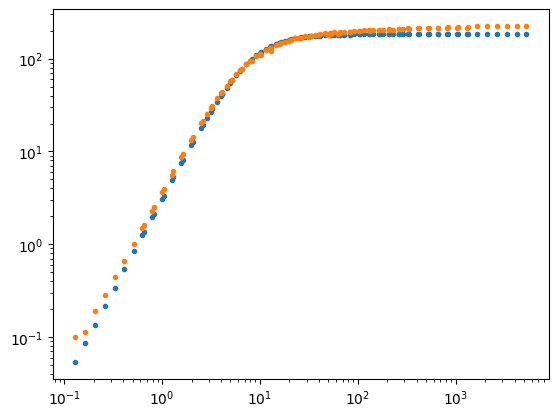

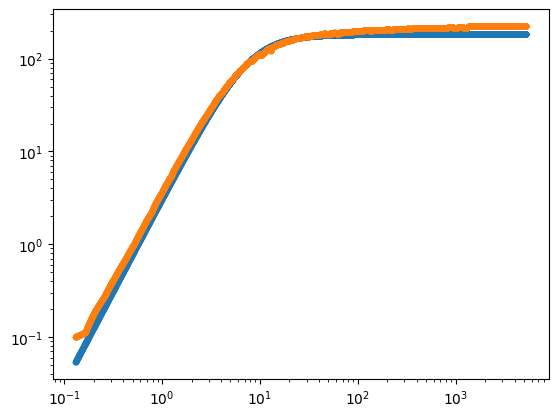

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9530667784162289
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9947011202498591
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9496854632326125
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9950769084444018
With same log spaced x range, mean absolute percentage error: 0.12410780420992829
With same log spaced x range, mean absolute log error: 0.1365937582072981
Integral mean absolute log error: 0.13510824988627698
R^2 for loss mod


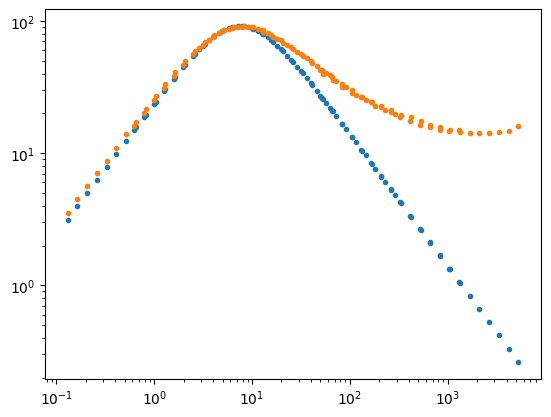

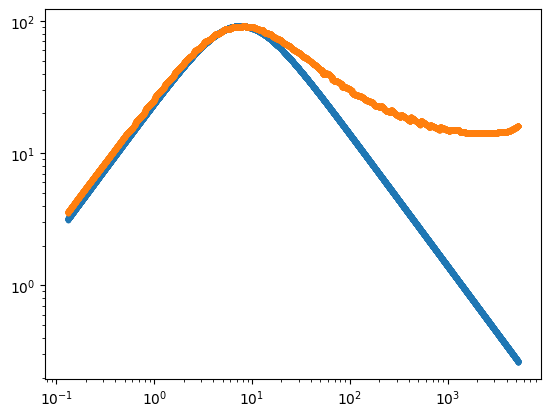

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8329302993289732
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.6422851766036493
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8371212382636899
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.3615176346753466
With same log spaced x range, mean absolute percentage error: 0.3954298906282392
With same log spaced x range, mean absolute log error: 0.9240748482296556
Integral mean absolute log error: 0.9236764541323016
R^2 for storage mod


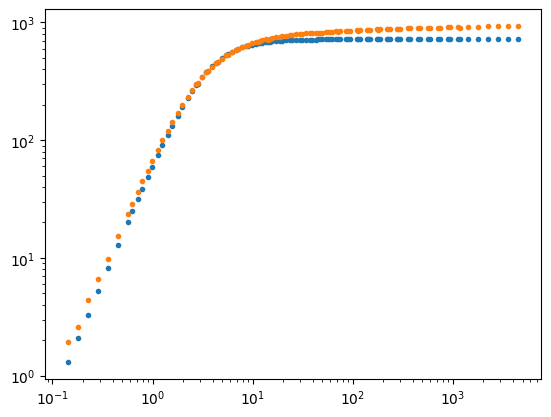

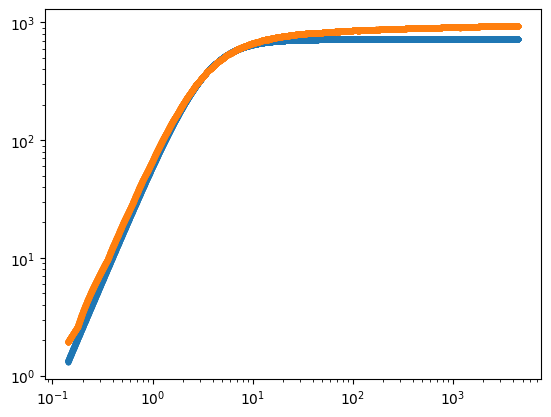

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8730940270435883
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9868940201619844
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8900508247015733
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9895740721408339
With same log spaced x range, mean absolute percentage error: 0.13860495566063727
With same log spaced x range, mean absolute log error: 0.1531138727086299
Integral mean absolute log error: 0.15204188269840976
R^2 for loss mod


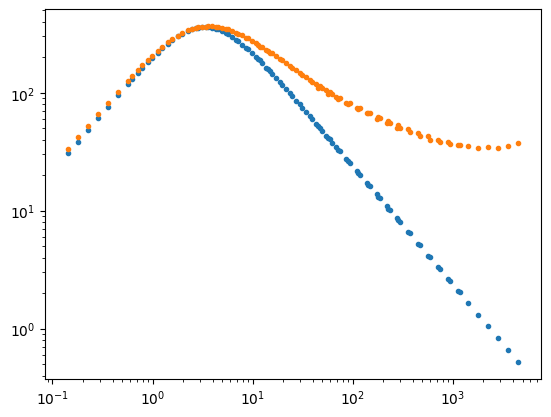

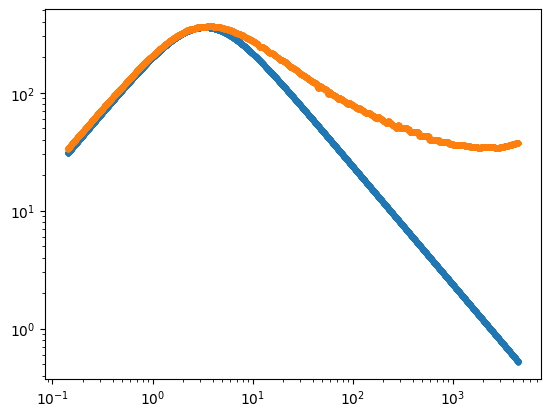

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8359570582696105
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.102501317457711
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8656702820791219
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -3.0163514718591786
With same log spaced x range, mean absolute percentage error: 0.45525857474456005
With same log spaced x range, mean absolute log error: 1.10227165170577
Integral mean absolute log error: 1.1019080148188378
R^2 for storage mod


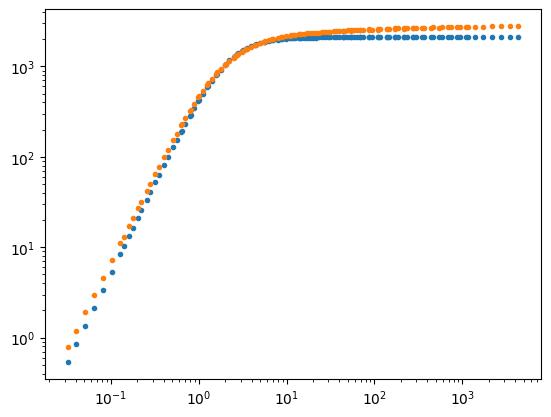

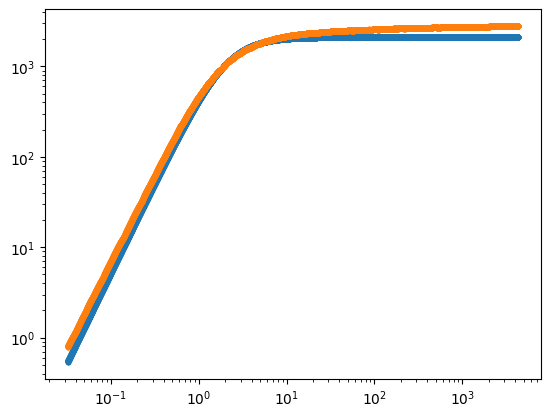

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8847400399074957
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9906124809278112
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8908905990964009
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.992070173889056
With same log spaced x range, mean absolute percentage error: 0.16486693536732427
With same log spaced x range, mean absolute log error: 0.18506655105034253
Integral mean absolute log error: 0.18386176890387793
R^2 for loss mod


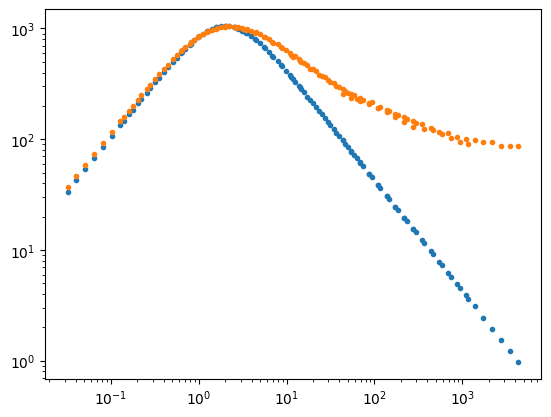

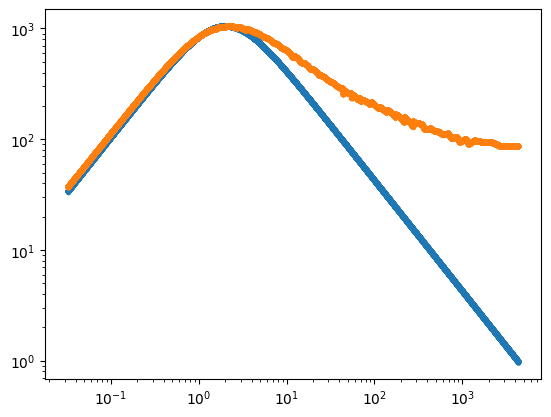

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8367378767050497
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.0213737906461358
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8588201091898461
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.700111130856254
With same log spaced x range, mean absolute percentage error: 0.44946290928481003
With same log spaced x range, mean absolute log error: 1.1521999870087538
Integral mean absolute log error: 1.1516913628223262
R^2 for storage mod


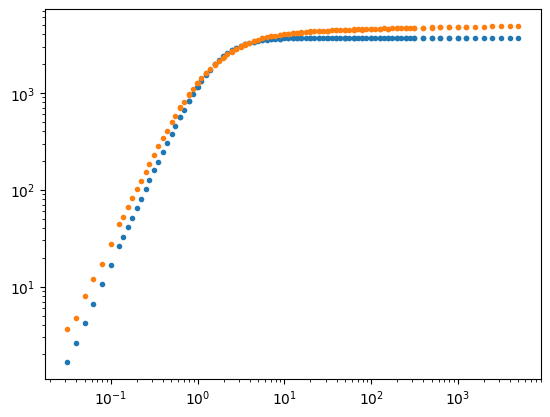

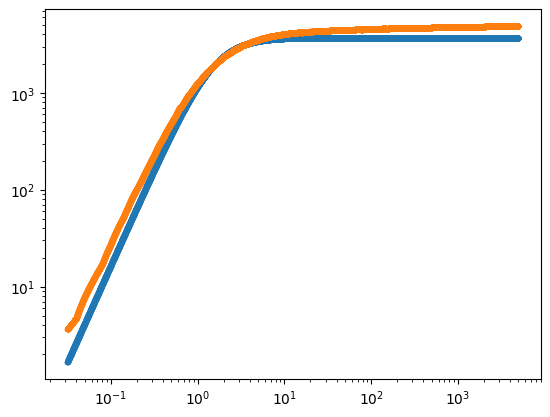

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8665174856139397
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9771979358157836
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8816661644290312
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9795716749403185
With same log spaced x range, mean absolute percentage error: 0.20409169045204514
With same log spaced x range, mean absolute log error: 0.24116166939565628
Integral mean absolute log error: 0.24013828244712346
R^2 for loss mod


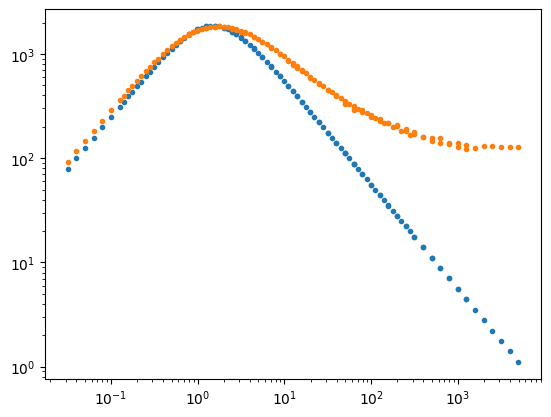

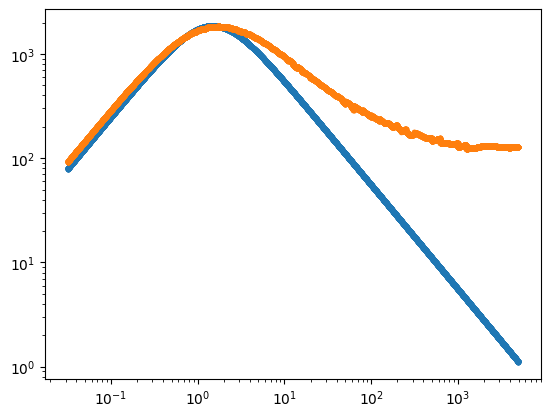

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8693957922609893
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.7799182092816999
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8858531307292102
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.7050002175033727
With same log spaced x range, mean absolute percentage error: 0.47960389029344935
With same log spaced x range, mean absolute log error: 1.2285739306731507
Integral mean absolute log error: 1.2281069960742035


In [39]:
storage_mod_exp_list=[G_storage_exp_v3,G_storage_exp_v4,G_storage_exp_v5,G_storage_exp_v6]
loss_mod_exp_list=[G_loss_exp_v3,G_loss_exp_v4,G_loss_exp_v5,G_loss_exp_v6]
freq_list=[freq_v3,freq_v4,freq_v5,freq_v6]

storage_mod_1relt_list=[storage_mod_r1 for e in range(len(storage_mod_exp_list))]
loss_mod_1relt_list=[loss_mod_r1 for e in range(len(storage_mod_exp_list))]

omega_t_list_rd=[omega_t_sim1 for e in range(len(storage_mod_exp_list))]

storage_mod_list_1relt_shift, loss_mod_list_1relt_shift, omega_t_list_1relt_shift,cross_over_freq_exp,cross_over_mod_exp,mult_factor_freq_1relt_shift=shift_mod(storage_mod_list=storage_mod_1relt_list,loss_mod_list=loss_mod_1relt_list,omega_t_list=omega_t_list_rd,  storage_mod_exp_list=storage_mod_exp_list,loss_mod_exp_list=loss_mod_exp_list,freq_list=freq_list)

R^2 for storage mod


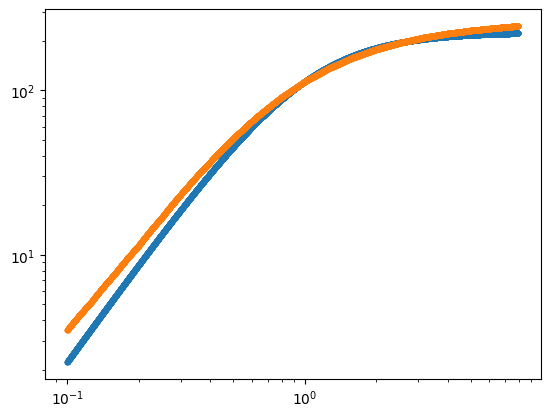

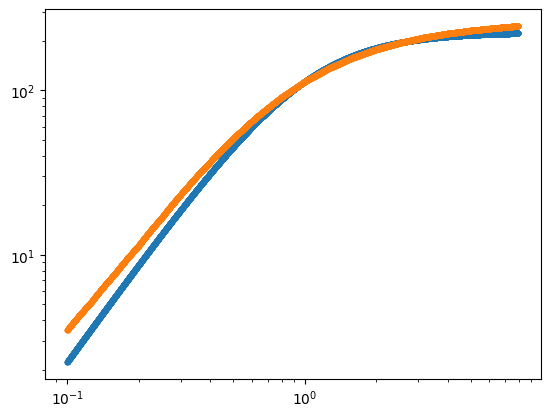

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9923061544859288
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9811471005145166
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9923061544859288
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9811471005145166
With same log spaced x range, mean absolute percentage error: 0.11119907162301693
With same log spaced x range, mean absolute log error: 0.1254332192603965
Integral mean absolute log error: 0.12543784701757496
R^2 for loss mod


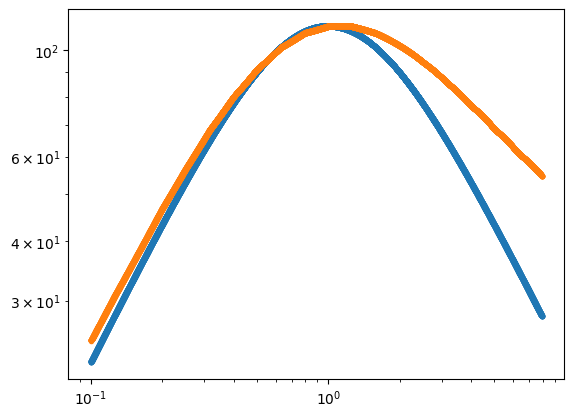

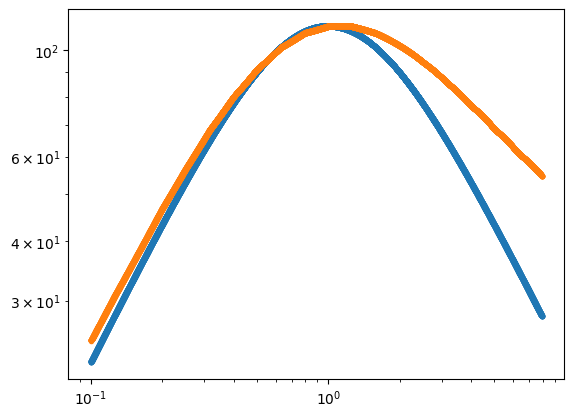

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.7486693891434434
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.6572046666810505
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.7486693891434434
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.6572046666810505
With same log spaced x range, mean absolute percentage error: 0.12864897460117586
With same log spaced x range, mean absolute log error: 0.1528542106877175
Integral mean absolute log error: 0.15284621359183193


In [40]:
storage_mod_list_1relt_shift_mr, loss_mod_list_1relt_shift_mr, omega_t_list_1relt_shift_mr,cross_over_freq_exp_mr,cross_over_mod_exp_mr,mult_factor_freq_1relt_shift_mr=shift_mod(storage_mod_list=[storage_mod_1relt_list[0]],loss_mod_list=[loss_mod_1relt_list[0]],omega_t_list=[omega_t_list_rd[0]],  storage_mod_exp_list=[G_storage_exp_v3b_os],loss_mod_exp_list=[G_loss_exp_v3b_os],freq_list=[freq_v3b_os])

R^2 for storage mod


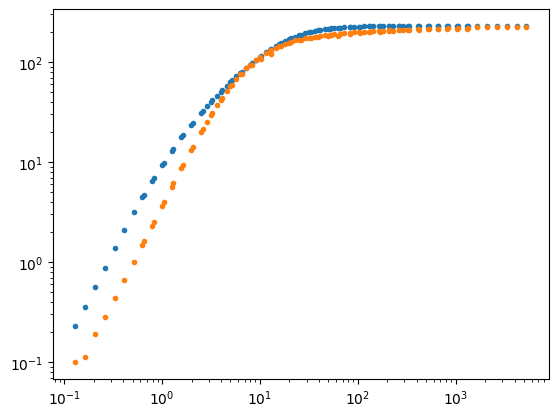

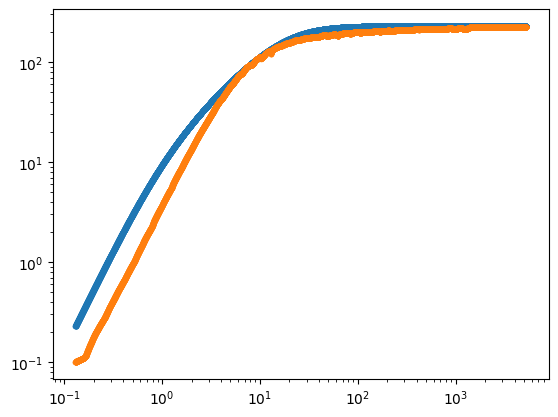

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.955269375866949
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9502186715330375
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9724659652271872
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.949637294372896
With same log spaced x range, mean absolute percentage error: 0.5389997335099208
With same log spaced x range, mean absolute log error: 0.33548571608726546
Integral mean absolute log error: 0.33694421804702157
R^2 for loss mod


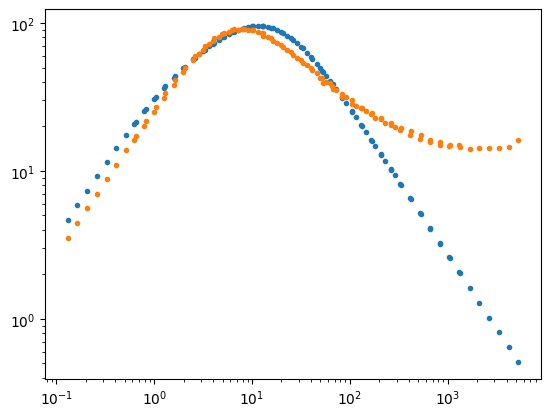

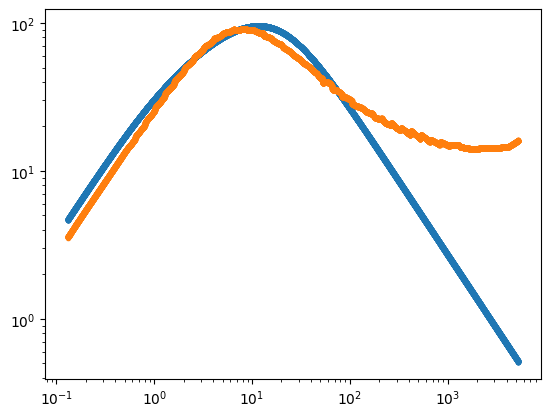

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8930159248452708
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -0.3740872261741415
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8856282983843261
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -0.912280872009362
With same log spaced x range, mean absolute percentage error: 0.35801339827372575
With same log spaced x range, mean absolute log error: 0.6707777704878951
Integral mean absolute log error: 0.67034590320929


In [41]:
# evaluate similarity of prediction to exp data
#use 3-armed simulations
storage_mod_exp_list=[G_storage_exp_v3,G_storage_exp_v4,G_storage_exp_v5,G_storage_exp_v6]
loss_mod_exp_list=[G_loss_exp_v3,G_loss_exp_v4,G_loss_exp_v5,G_loss_exp_v6]
freq_list=[freq_v3,freq_v4,freq_v5,freq_v6]

mean_storage_mod_3_arm_hydr=[np.mean(storage_mod_all_sims_all_hydr_3arm[0],axis=0)]
std_e_storage_mod_3_arm_hydr=[np.std(storage_mod_all_sims_all_hydr_3arm[0],axis=0)/(np.sqrt(len(storage_mod_all_sims_all_hydr_3arm[0])))]
    
    
mean_loss_mod_3_arm_hydr=[np.mean(loss_mod_all_sims_all_hydr_3arm[0],axis=0)]
std_e_loss_mod_3_arm_hydr=[np.std(loss_mod_all_sims_all_hydr_3arm[0],axis=0)/(np.sqrt(len(loss_mod_all_sims_all_hydr_3arm[0])))]

omega_t_list_3arm_hydr=[omega_t_sim1_hydr for e in range(len(mean_loss_mod_3_arm_hydr))]

storage_mod_list_3arm_hydr_shift, loss_mod_list_3arm_hydr_shift, omega_t_list_3arm_hydr_shift,cross_over_freq_exp,cross_over_mod_exp,mult_factor_freq_3arm_hydr_shift=shift_mod(storage_mod_list=mean_storage_mod_3_arm_hydr,loss_mod_list=mean_loss_mod_3_arm_hydr,omega_t_list=omega_t_list_3arm_hydr,  storage_mod_exp_list=storage_mod_exp_list,loss_mod_exp_list=loss_mod_exp_list,freq_list=freq_list,X_low=5* 10**-10,X_high=5* 10**10)

<Figure size 137.795x137.795 with 0 Axes>

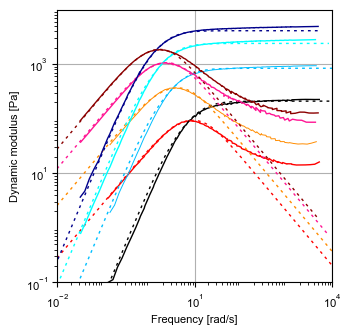

In [42]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(9/2.54,9/2.54))
#fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))

ax1 = fig.add_subplot(111)

ax1.errorbar(freq_v3[::],G_storage_exp_v3[::],fmt="-",label=r"$G'$, degree=3",color="black",linewidth=1)
ax1.errorbar(freq_v3[::],G_loss_exp_v3[::],fmt="-",label=r"$G''$, degree=3",color="red",linewidth=1)

line1=ax1.errorbar(omega_t_list_rd_shift[0][::],storage_mod_list_rd_shift[0][::],fmt=":",label=r"$G'$ sim.",color="black",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift[0][::],loss_mod_list_rd_shift[0][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="red",linewidth=1)
line2[0].set_dashes([2,3]) 


ax1.errorbar(freq_v4[::],G_storage_exp_v4[::],fmt="-",label=r"$G'$, degree=4",color="deepskyblue",linewidth=0.7)
ax1.errorbar(freq_v4[::],G_loss_exp_v4[::],fmt="-",label=r"$G''$, degree=4",color="darkorange",linewidth=0.7)

line1=ax1.errorbar(omega_t_list_rd_shift[1][::],storage_mod_list_rd_shift[1][::],fmt=":",label=r"$G'$ sim.",color="deepskyblue",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift[1][::],loss_mod_list_rd_shift[1][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="darkorange",linewidth=1)
line2[0].set_dashes([2,3]) 



ax1.errorbar(freq_v5[::],G_storage_exp_v5[::],fmt="-",label=r"$G'$, exp., val.=5",color="cyan",linewidth=1)
ax1.errorbar(freq_v5[::],G_loss_exp_v5[::],fmt="-",label=r"$G''$, exp., val.=5",color="deeppink",linewidth=1)

line1=ax1.errorbar(omega_t_list_rd_shift[2][::],storage_mod_list_rd_shift[2][::],fmt=":",label=r"$G'$ sim.",color="cyan",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift[2][::],loss_mod_list_rd_shift[2][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="deeppink",linewidth=1)
line2[0].set_dashes([2,3]) 


ax1.errorbar(freq_v6[::],G_storage_exp_v6[::],fmt="-",label=r"$G'$, degree=6",color="darkblue",linewidth=1)
ax1.errorbar(freq_v6[::],G_loss_exp_v6[::],fmt="-",label=r"$G''$, degree=6",color="darkred",linewidth=1)

line1=ax1.errorbar(omega_t_list_rd_shift[3][::],storage_mod_list_rd_shift[3][::],fmt=":",label=r"$G'$ sim.",color="darkblue",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift[3][::],loss_mod_list_rd_shift[3][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="darkred",linewidth=1)
line2[0].set_dashes([2, 3]) 

#plt.axvline(0.28)
#plt.axhline(21.15)

#plt.axvline(10.56)
#plt.axhline(0.38)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(10**-1,10**4)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_theo_valency_lim_freq_1.pdf"
#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_theo_all_valency6_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

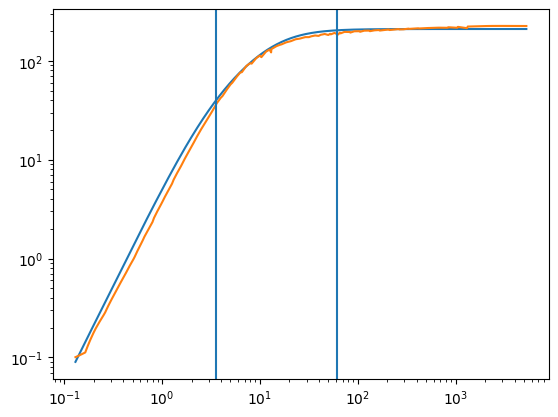

Longest contiguous x-range where deviation is less than 10% and includes 7.58082: (3.5899641478090873, 61.961610636484295)


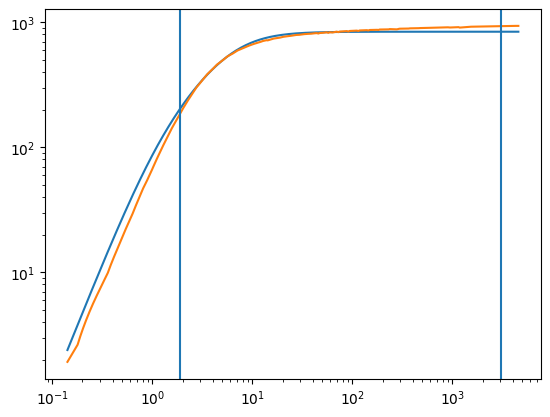

Longest contiguous x-range where deviation is less than 10% and includes 3.30506: (1.8662992217275014, 3085.7687531472448)


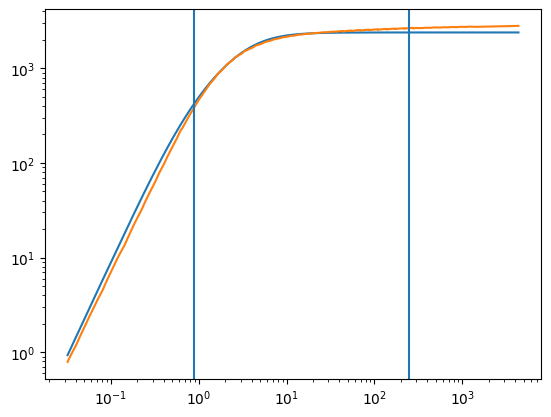

Longest contiguous x-range where deviation is less than 10% and includes 2.01155: (0.8859037757981066, 244.58354605482282)


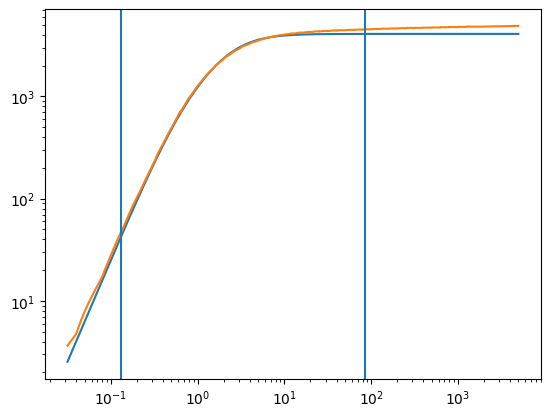

Longest contiguous x-range where deviation is less than 10% and includes 1.48807: (0.12999287644264917, 85.98339031278203)


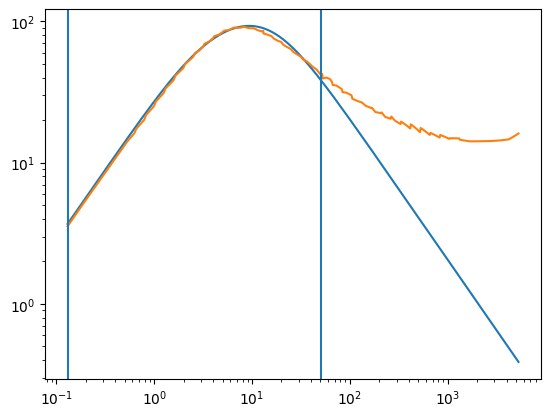

Longest contiguous x-range where deviation is less than 10% and includes 7.58082: (0.130258, 50.91641112587363)


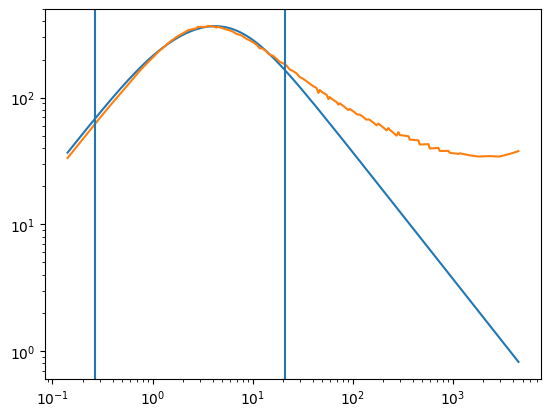

Longest contiguous x-range where deviation is less than 10% and includes 3.30506: (0.26347568041294533, 21.26650740315708)


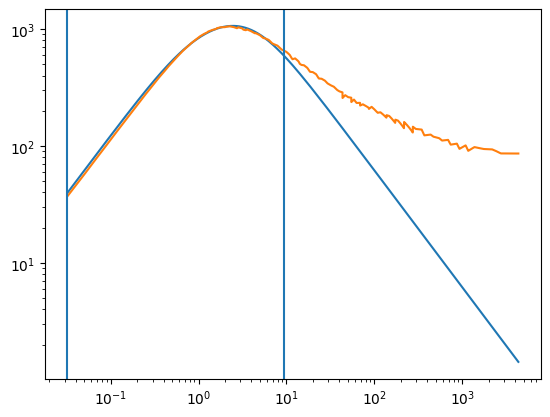

Longest contiguous x-range where deviation is less than 10% and includes 2.01155: (0.0322719, 9.507851230071555)


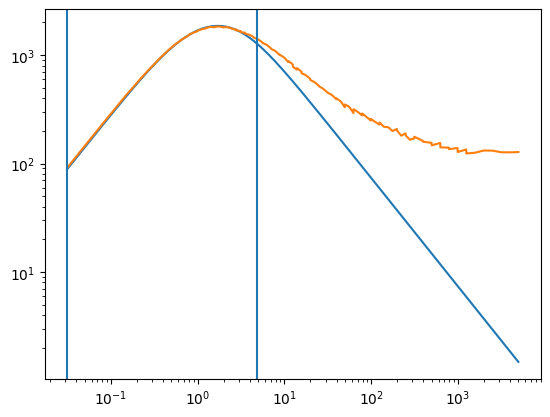

Longest contiguous x-range where deviation is less than 10% and includes 1.48807: (0.0316623, 4.903504865141543)


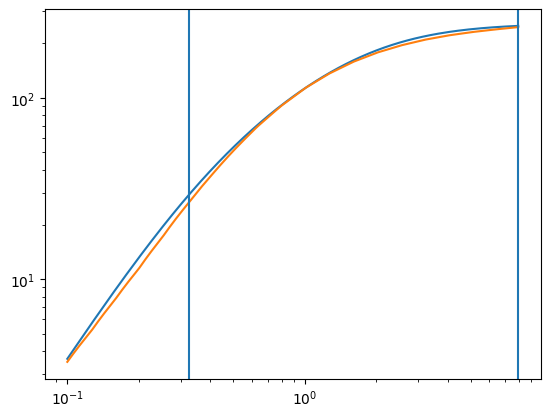

Longest contiguous x-range where deviation is less than 10% and includes 0.995558325449778: (0.3255870341727476, 7.943)


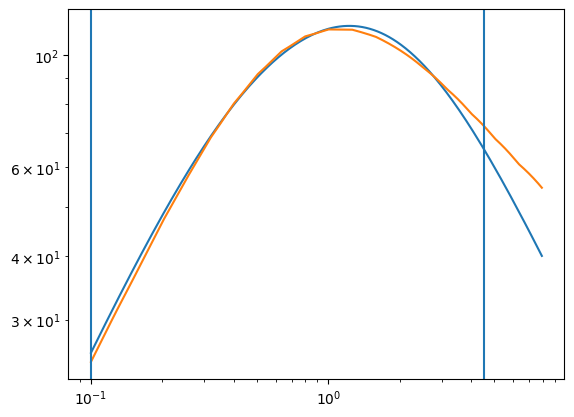

Longest contiguous x-range where deviation is less than 10% and includes 0.995558325449778: (0.1, 4.525036759278488)


In [43]:
# generate cofidence regions around cross over freq.
conf_region_storage_theo=[region_of_conf(x_ref=freq_list[e],y_ref=storage_mod_exp_list[e], x2=omega_t_list_rd_shift[e],y2=storage_mod_list_rd_shift[e],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_list[e], y1=storage_mod_exp_list[e], x2=freq_list[e], y2=loss_mod_exp_list[e])[0][0],n_false_allowed=10 ) for e in [0,1,2,3]]
conf_region_loss_theo=[region_of_conf(x_ref=freq_list[e],y_ref=loss_mod_exp_list[e], x2=omega_t_list_rd_shift[e],y2=loss_mod_list_rd_shift[e],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_list[e], y1=storage_mod_exp_list[e], x2=freq_list[e], y2=loss_mod_exp_list[e])[0][0] ,n_false_allowed=10) for e in [0,1,2,3]]

conf_region_storage_theo_mr=[region_of_conf(x_ref=freq_v3b_os,y_ref=G_storage_exp_v3b_os, x2=omega_t_list_rd_shift_mr[0],y2=storage_mod_list_rd_shift_mr[0],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_v3b_os, y1=G_storage_exp_v3b_os, x2=freq_v3b_os, y2=G_loss_exp_v3b_os)[0][0],n_false_allowed=10 )]
conf_region_loss_theo_mr=[region_of_conf(x_ref=freq_v3b_os,y_ref=G_loss_exp_v3b_os, x2=omega_t_list_rd_shift_mr[0],y2=loss_mod_list_rd_shift_mr[0],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_v3b_os, y1=G_storage_exp_v3b_os, x2=freq_v3b_os, y2=G_loss_exp_v3b_os)[0][0] ,n_false_allowed=10)]


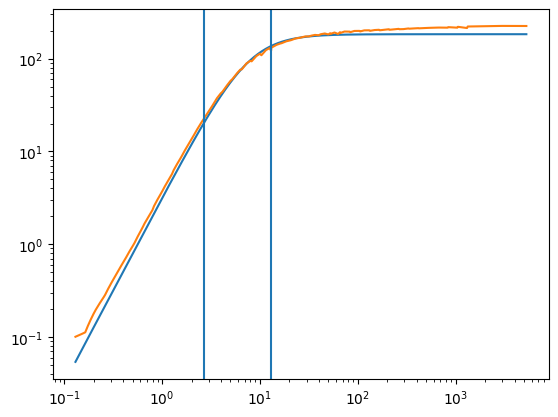

Longest contiguous x-range where deviation is less than 10% and includes 7.58082: (2.69842478908463, 12.88259601860398)


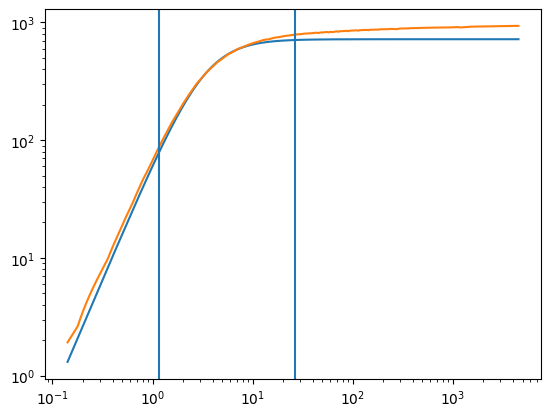

Longest contiguous x-range where deviation is less than 10% and includes 3.30506: (1.1698054867583845, 26.61170065973444)


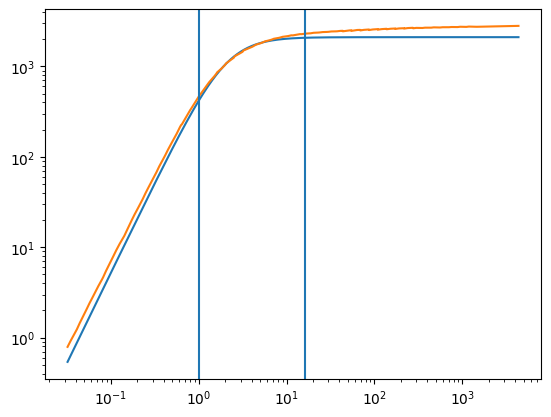

Longest contiguous x-range where deviation is less than 10% and includes 2.01155: (1.0076456384452623, 16.409921543470226)


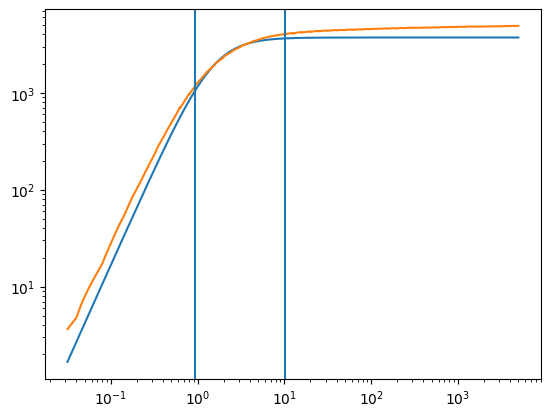

Longest contiguous x-range where deviation is less than 10% and includes 1.48807: (0.9457282287861851, 10.261953851665512)


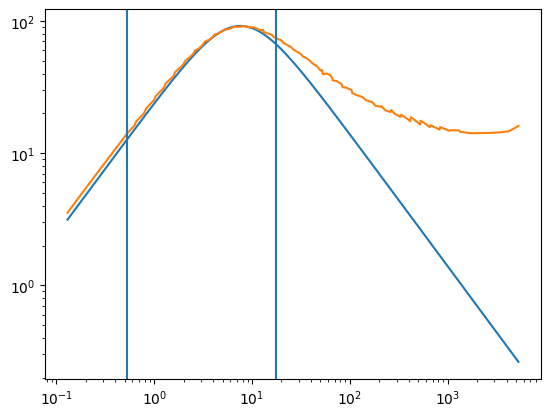

Longest contiguous x-range where deviation is less than 10% and includes 7.58082: (0.5241963062461624, 17.581040560160314)


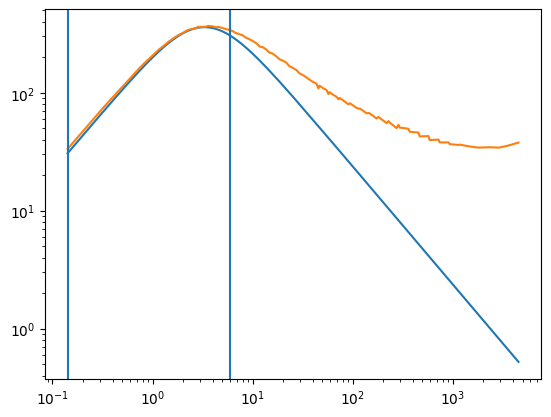

Longest contiguous x-range where deviation is less than 10% and includes 3.30506: (0.141482, 5.987543663059072)


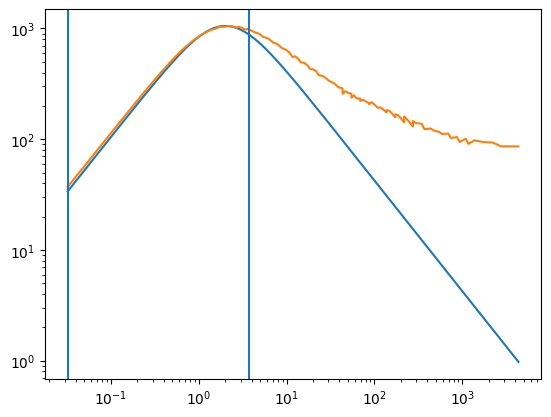

Longest contiguous x-range where deviation is less than 10% and includes 2.01155: (0.0322719, 3.7613745130740117)


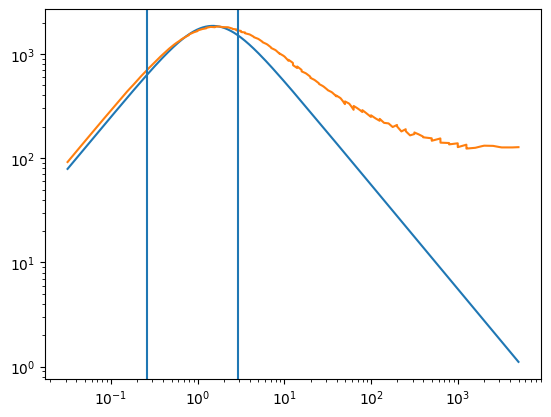

Longest contiguous x-range where deviation is less than 10% and includes 1.48807: (0.26213732090951286, 2.899409376254754)


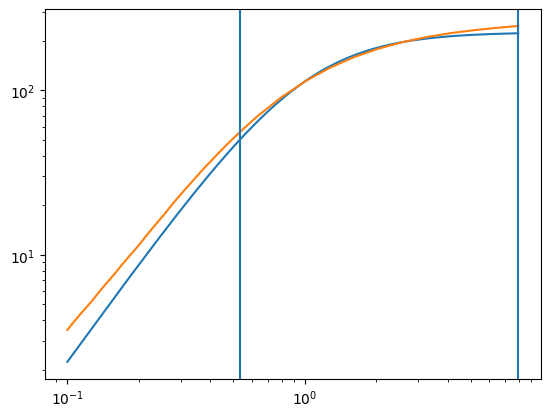

Longest contiguous x-range where deviation is less than 10% and includes 0.995558325449778: (0.5352133454796361, 7.943)


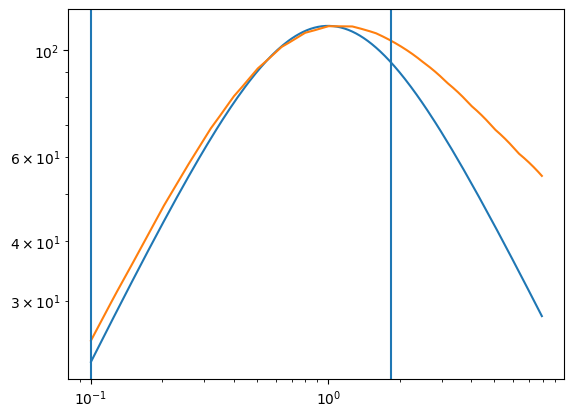

Longest contiguous x-range where deviation is less than 10% and includes 0.995558325449778: (0.1, 1.8429615318637929)


In [44]:
conf_region_storage_1relt=[region_of_conf(x_ref=freq_list[e],y_ref=storage_mod_exp_list[e], x2=omega_t_list_1relt_shift[e],y2=storage_mod_list_1relt_shift[e],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_list[e], y1=storage_mod_exp_list[e], x2=freq_list[e], y2=loss_mod_exp_list[e])[0][0],n_false_allowed=10 ) for e in [0,1,2,3]]
conf_region_loss_1relt=[region_of_conf(x_ref=freq_list[e],y_ref=loss_mod_exp_list[e], x2=omega_t_list_1relt_shift[e],y2=loss_mod_list_1relt_shift[e],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_list[e], y1=storage_mod_exp_list[e], x2=freq_list[e], y2=loss_mod_exp_list[e])[0][0],n_false_allowed=10 ) for e in [0,1,2,3]]


conf_region_storage_1relt_mr=[region_of_conf(x_ref=freq_v3b_os,y_ref=G_storage_exp_v3b_os, x2=omega_t_list_1relt_shift_mr[0],y2=storage_mod_list_1relt_shift_mr[0],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_v3b_os, y1=G_storage_exp_v3b_os, x2=freq_v3b_os, y2=G_loss_exp_v3b_os)[0][0],n_false_allowed=10 )]
conf_region_loss_1relt_mr=[region_of_conf(x_ref=freq_v3b_os,y_ref=G_loss_exp_v3b_os, x2=omega_t_list_1relt_shift_mr[0],y2=loss_mod_list_1relt_shift_mr[0],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_v3b_os, y1=G_storage_exp_v3b_os, x2=freq_v3b_os, y2=G_loss_exp_v3b_os)[0][0],n_false_allowed=10 )]


<Figure size 137.795x137.795 with 0 Axes>

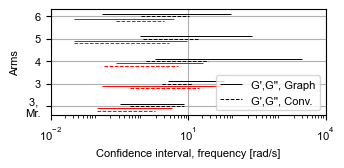

In [64]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(9/2.54,3.5/2.54))
#fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))

ax1 = fig.add_subplot(111)

for i in range(len(conf_region_storage_theo)):
    r1,r2=conf_region_storage_theo[i][0]
    k1,k2=conf_region_storage_1relt[i][0]
    ax1.hlines(i+0.1,r1,r2,color="black",linewidth=0.7)
    ax1.hlines(i-0.1+0.1,k1,k2,color="black",linestyles="--",linewidth=0.7)

    r1,r2=conf_region_loss_theo[i][0]
    k1,k2=conf_region_loss_1relt[i][0]
    ax1.hlines(i-0.1,r1,r2,color="red",linewidth=0.7)
    ax1.hlines(i-0.1-0.1,k1,k2,color="red",linestyles="--",linewidth=0.7)

r1,r2=conf_region_storage_theo_mr[0][0]
k1,k2=conf_region_storage_1relt_mr[0][0]
ax1.hlines(-1+0.1,r1,r2,color="black",linewidth=0.7,label="G',G'', Graph")
ax1.hlines(-1-0.1+0.1,k1,k2,color="black",linestyles="--",linewidth=0.7,label="G',G'', Conv.")

r1,r2=conf_region_loss_theo_mr[0][0]
k1,k2=conf_region_loss_1relt_mr[0][0]
ax1.hlines(-1-0.1,r1,r2,color="red",linewidth=0.7)
ax1.hlines(-1-0.1-0.1,k1,k2,color="red",linestyles="--",linewidth=0.7)
    
fs1=8
plt.xscale("log")
#plt.yscale("log")
plt.grid()
#plt.ylim(10**-1,10**4)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([-1,0,1,2,3],["3, \nMr.","3","4","5","6"],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Arms",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Confidence interval, frequency [rad/s]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/confidence_interval_lim_freq_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

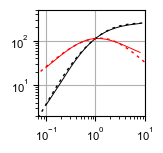

In [65]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
#fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))

ax1 = fig.add_subplot(111)

ax1.errorbar(freq_v3b[::],G_storage_exp_v3b[::],fmt="-",label=r"$G'$, degree=3",color="black",linewidth=0.7)
ax1.errorbar(freq_v3b[::],G_loss_exp_v3b[::],fmt="-",label=r"$G''$, degree=3",color="red",linewidth=0.7)

line1=ax1.errorbar(omega_t_list_rd_shift_mr[0][::],storage_mod_list_rd_shift_mr[0][::],fmt="-",label=r"$G'$ sim.",color="black",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift_mr[0][::],loss_mod_list_rd_shift_mr[0][::],fmt="-",label=r"$G''-\omega \eta$ sim.",color="red",linewidth=1)
line2[0].set_dashes([2,3]) 


#plt.axvline(0.28)
#plt.axhline(21.15)

#plt.axvline(10.56)
#plt.axhline(0.38)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(2,500)
plt.xlim(7*10**-2,10**1)
plt.xticks([10**-1,10**0,10**1],fontname = "Arial",fontsize=fs1)
plt.yticks([10**1,10**2],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
#ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_theo_MR_lim_freq_1.pdf"
#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_theo_valency6_MR_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

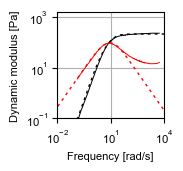

In [45]:

#for i in range(len(storage_mod_exp_list)):

fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq_v3[::],G_storage_exp_v3[::],fmt="-",label=r"$G'$, degree=3",color="black",linewidth=0.7)
ax1.errorbar(freq_v3[::],G_loss_exp_v3[::],fmt="-",label=r"$G''$, degree=3",color="red",linewidth=0.7)

line1=ax1.errorbar(omega_t_list_rd_shift[0][::],storage_mod_list_rd_shift[0][::],fmt=":",label=r"$G'$ sim.",color="black",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift[0][::],loss_mod_list_rd_shift[0][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="red",linewidth=1)
line2[0].set_dashes([2,3]) 

    
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(10**0,1500)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_sim_3_armed_full_freq.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

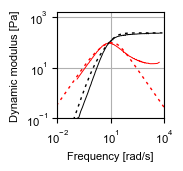

In [46]:

#for i in range(len(storage_mod_exp_list)):

fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq_v3[::],G_storage_exp_v3[::],fmt="-",label=r"$G'$, degree=3",color="black",linewidth=0.7)
ax1.errorbar(freq_v3[::],G_loss_exp_v3[::],fmt="-",label=r"$G''$, degree=3",color="red",linewidth=0.7)

line1=ax1.errorbar(omega_t_list_3arm_hydr_shift[0][::],storage_mod_list_3arm_hydr_shift[0][::],fmt=":",label=r"$G'$ sim.",color="black",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_3arm_hydr_shift[0][::],loss_mod_list_3arm_hydr_shift[0][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="red",linewidth=1)
line2[0].set_dashes([2,3]) 

    
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(10**0,1500)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_sim_3_armed_sim_hydr_2.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [21]:
bf_frac_theo_L=[backbone_fraction(theo_L_list[i]) for i in range(len(theo_L_list))   ]
cyclo_frac_theo_L=[cyclomatic_number(theo_L_list[i]) for i in range(len(theo_L_list))   ]


bf_frac_theo_L2=[backbone_fraction(theo_L_list2[i]) for i in range(len(theo_L_list2))   ]
cyclo_frac_theo_L2=[cyclomatic_number(theo_L_list2[i],normalize=False) for i in range(len(theo_L_list2))   ]




In [20]:
# evaluate rescaling by stress bearing quantities-> get graphs of degree n networks and calculate backbone fraction and cyclomatic number


#number of nodes
num_nodes_list=[800,800,800,800]  #[800,800,800,800] #[100,100,100,100] #
#degree of each node
m_list=[3,4,5,6] #[3,4,5,6] 
#number of edges to add
p_list=[1200,1600,2000,2400] #[1200,1600,2000,2400]  #[150,200,250,300]   #
#random seed
rs_list=[1,1,1,1]


theo_L_list=[generate_rd_graph_laplacian3(N=num_nodes_list[i], m=m_list[i], p=p_list[i], rs=rs_list[i]) for i in range(len(num_nodes_list))]



#number of nodes
num_nodes_list2=[500,490,490,450]  #[800,800,800,800] #[100,100,100,100] #
#degree of each node
m_list2=[3,4,5,6] #[3,4,5,6] 
#number of edges to add
p_list2=[int(500*3/2),int(490*4/2),int(490*5/2),int(450*6/2)] #[1200,1600,2000,2400]  #[150,200,250,300]   #
#random seed
rs_list2=[1,1,1,1]


theo_L_list2=[generate_rd_graph_laplacian3(N=num_nodes_list2[i], m=m_list2[i], p=p_list2[i], rs=rs_list2[i]) for i in range(len(num_nodes_list2))]

In [22]:
cyclo_frac_theo_L2

[251, 491, 736, 901]

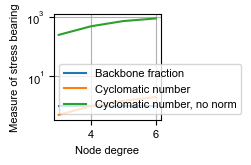

In [24]:

fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)
plt.errorbar(m_list,bf_frac_theo_L,label="Backbone fraction")
plt.errorbar(m_list,cyclo_frac_theo_L,label="Cyclomatic number")
plt.errorbar(m_list,cyclo_frac_theo_L2,label="Cyclomatic number, no norm")


fs1=8
#plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#ax1.set_ylabel(r"$G'/G_{cf},\ G''/G_{cf}$ [-]",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel(r"$\omega/\omega_{cf}$ [-]",fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Measure of stress bearing",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Node degree",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower left")


In [147]:
len(loss_mod_list_rd[0])

1000

<Figure size 1000x1000 with 0 Axes>

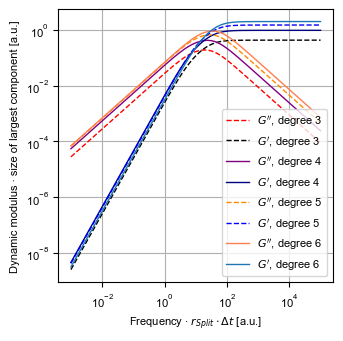

In [154]:
#Plot the curves with rescaling of overall moduli by fraction of SEs/size of largest component
fig=plt.figure(figsize=(10,10))
fig=plt.figure(figsize=(9/2.54,9/2.54))
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)



labels_storage1=[r"$G'$, degree 3",
                r"$G'$, degree 4",
                r"$G'$, degree 5",
                r"$G'$, degree 6",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'/G_{cf},~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G''$, degree 3",
                r"$G''$, degree 4",
                r"$G''$, degree 5",
                r"$G''$, degree 6",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G''/G_{cf},~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"]

fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]

# --- NEW: cutoff option ---
omega_min =None# 0.5*10**-3   # e.g. 0.1  -- set to None to disable lower cutoff
omega_max =None# 3*10**3   # e.g. 100 -- set to None to disable upper cutoff

def apply_cutoff(x, *arrays):
    """Return x and each array in `arrays` masked to [omega_min, omega_max]."""
    mask = np.ones_like(x, dtype=bool)
    if omega_min is not None:
        mask &= (x >= omega_min)
    if omega_max is not None:
        mask &= (x <= omega_max)
    return (x[mask],) + tuple(a[mask] for a in arrays)

omega_cf_list=[]
G_cf_list=[]
omega_cf_rs_theo_list=[]
G_cf_theo_list=[]

lii=0
for i in range(len(loss_mod_list_rd)):
    alpha1=1 -lii/5   

    mean_loss_mod_all_sims_ex1=np.array(loss_mod_list_rd[i])

    mean_storage_mod_all_sims_ex1=np.array(storage_mod_list_rd[i])

    #select factor for rescaling:
    G_rs=cyclo_frac_theo_L[i]#bf_frac_sims[i] #bound_se_list[lii]
    omega_rs=1 #r_sp_list[lii]

    # --- find crossover point for this curve pair ---
    omega_cf, G_cf = find_intersection(x1=omega_t_sim1, y1=mean_storage_mod_all_sims_ex1,
                                        x2=omega_t_sim1, y2=mean_loss_mod_all_sims_ex1)[0]
    omega_cf_list.append(omega_cf)
    G_cf_list.append(G_cf)

    # --- rescale ---
    omega_scaled = omega_t_sim1 * omega_rs

    mean_loss_scaled = mean_loss_mod_all_sims_ex1 * G_rs

    mean_storage_scaled = mean_storage_mod_all_sims_ex1 * G_rs

    # --- NEW: apply cutoff, separately for loss and storage (they share omega_scaled) ---
    omega_loss_cut, mean_loss_cut, std_e_loss_cut = apply_cutoff(
        omega_scaled, mean_loss_scaled, std_e_loss_scaled)
    omega_storage_cut, mean_storage_cut, std_e_storage_cut = apply_cutoff(
        omega_scaled, mean_storage_scaled, std_e_storage_scaled)

    # --- find crossover point for this curve pair ---
    omega_cf_rs_theo, G_cf_theo, = find_intersection(x1=omega_scaled, y1=mean_storage_scaled,
                                        x2=omega_scaled, y2=mean_loss_scaled)[0]
    omega_cf_rs_theo_list.append(omega_cf_rs_theo)
    G_cf_theo_list.append(G_cf_theo)
    

    # --- plot loss (G'') ---
    line_loss=ax1.errorbar(omega_loss_cut[::], mean_loss_cut[::], label=labels_loss1[lii],
                            color=color_loss_list1[lii], fmt=fmt_loss_list1[lii], linewidth=1)

    # --- plot storage (G') ---
    line_storage=ax1.errorbar(omega_storage_cut[::], mean_storage_cut[::], label=labels_storage1[lii],
                               color=color_storage_list1[lii], fmt=fmt_storage_list1[lii], linewidth=1)


    lii=lii+1

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#ax1.set_ylabel(r"$G'/G_{cf},\ G''/G_{cf}$ [-]",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel(r"$\omega/\omega_{cf}$ [-]",fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Dynamic modulus · fraction of bound sticky ends [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel(r"Frequency · $r_{Split} \cdot \Delta t$ [a.u.]",fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Dynamic modulus · size of largest component [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel(r"Frequency · $r_{Split} \cdot \Delta t$ [a.u.]",fontname = "Arial",fontsize=fs1)

ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_shifted_r_split_size_comp1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [28]:
freq_list_exp=[freq_v3,freq_v4,freq_v5,freq_v6]
G_storage_list_exp=[G_storage_exp_v3,G_storage_exp_v4,G_storage_exp_v5,G_storage_exp_v6]

omega_cf_exp_list=[]
G_cf_exp_list=[]
for i in range(len(freq_list_exp[:])):
   
    omega_inters_1,dyn_mod_inters_1=find_intersection(x1=freq_list_exp[i], y1=G_storage_list_exp[i], x2=freq_list_exp[i], y2=G_loss_list_exp[i])[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)
    omega_cf_exp_list.append(omega_inters_1)
    G_cf_exp_list.append(dyn_mod_inters_1)
    

In [29]:
c_conc_exp=np.array([500,490,490,450]) #nanostar concentrations in Conrad et al for 3,4,5,6
scaling_exp=np.array([1.8,1.3,1.5,1])
scaling_c_conc_exp=np.array([500**1.8,490**1.3,490**1.5,450**1]) # scaling of plateau measured G_p~conc^t in Conrad et al for 3.4.5.6

In [192]:
cyclo_frac_theo_L

[0.50125, 1.00125, 1.50125, 2.00125]

In [190]:
G_cf_theo_list

[0.18730082861767197,
 0.41343943027970986,
 0.6583382176127044,
 0.9062439850542444]

In [189]:
m_list

[3, 4, 5, 6]

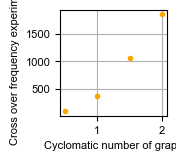

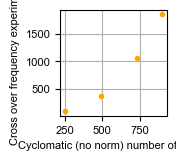

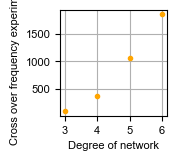

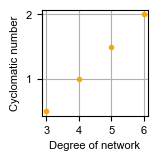

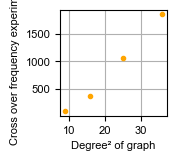

In [31]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(np.array(cyclo_frac_theo_L),G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")

#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency experiment",fontname = "Arial",fontsize=fs1)
plt.xlabel("Cyclomatic number of graph",fontname = "Arial",fontsize=fs1)
plt.grid()

##################################################
#####################################################
################################################

fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(np.array(cyclo_frac_theo_L2),G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")

#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency experiment",fontname = "Arial",fontsize=fs1)
plt.xlabel("Cyclomatic (no norm) number of graph",fontname = "Arial",fontsize=fs1)
plt.grid()

##################################################
#####################################################
################################################

fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(m_list,G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")

#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks([3,4,5,6],[3,4,5,6],fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency experiment",fontname = "Arial",fontsize=fs1)
plt.xlabel("Degree of network",fontname = "Arial",fontsize=fs1)
plt.grid()

##################################################
#####################################################
################################################


fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(m_list,cyclo_frac_theo_L,color="orange",linewidth=0.7,fmt=".")

#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks([3,4,5,6],[3,4,5,6],fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cyclomatic number",fontname = "Arial",fontsize=fs1)
plt.xlabel("Degree of network",fontname = "Arial",fontsize=fs1)
plt.grid()

##################################################
#####################################################
################################################


fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(np.array(m_list)**2,G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")

#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency experiment",fontname = "Arial",fontsize=fs1)
plt.xlabel("Degree² of graph",fontname = "Arial",fontsize=fs1)
plt.grid()


Fitted parameters: a=445.2899219759164,n=2.0941309979864924, b=-34.92850010129738
R-squared: 0.9971718900761349
RMSE: 36.34676161953361


/tmp/ipykernel_99/2991849642.py:10: RuntimeWarning: overflow encountered in power
  return a*x**n +b


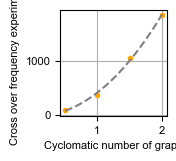

In [33]:



fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(cyclo_frac_theo_L,G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")




def model_s(x, a,n, b):
    return a*x**n +b
x1=cyclo_frac_theo_L
y1=G_cf_exp_list
params, _ = curve_fit(model_s, x1,y1,p0=[1,-0.5,75],maxfev = 20000)

# Extract fitted parameters
a,n, b = params
print(f"Fitted parameters: a={a},n={n}, b={b}")


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
#print("prediction:",model_s(2*10**-4, *params))

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")


#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency experiment",fontname = "Arial",fontsize=fs1)
plt.xlabel("Cyclomatic number of graph",fontname = "Arial",fontsize=fs1)
plt.grid()


Fitted parameters: a=4.7065908275096655e-06,n=2.905317484091321, b=48.001839366753316
R-squared: 0.9999984215442
RMSE: 0.8586848338187897


/tmp/ipykernel_99/3755604875.py:10: RuntimeWarning: overflow encountered in power
  return a*x**n +b


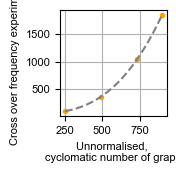

In [35]:



fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(cyclo_frac_theo_L2,G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")




def model_s(x, a,n, b):
    return a*x**n +b
x1=cyclo_frac_theo_L2
y1=G_cf_exp_list
params, _ = curve_fit(model_s, x1,y1,p0=[1,-0.5,75],maxfev = 20000)

# Extract fitted parameters
a,n, b = params
print(f"Fitted parameters: a={a},n={n}, b={b}")


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
#print("prediction:",model_s(2*10**-4, *params))

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")


#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency experiment",fontname = "Arial",fontsize=fs1)
plt.xlabel("Unnormalised, \ncyclomatic number of graph",fontname = "Arial",fontsize=fs1)
plt.grid()


Fitted parameters: a=9.825205816599203,n=2.9845756713681673, b=-195.18748529574046
R-squared: 0.9962799924905499
RMSE: 41.68592934414522


/tmp/ipykernel_158/1759581294.py:11: RuntimeWarning: overflow encountered in power
  return a*x**n +b


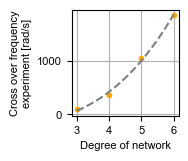

In [198]:



fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)


ax1.errorbar(m_list,G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")




def model_s(x, a,n, b):
    return a*x**n +b
x1=m_list
y1=G_cf_exp_list
params, _ = curve_fit(model_s, x1,y1,p0=[1,-0.5,75],maxfev = 20000)

# Extract fitted parameters
a,n, b = params
print(f"Fitted parameters: a={a},n={n}, b={b}")


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
#print("prediction:",model_s(2*10**-4, *params))

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")


#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks([3,4,5,6],[3,4,5,6],fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency\nexperiment [rad/s]",fontname = "Arial",fontsize=fs1)
plt.xlabel("Degree of network",fontname = "Arial",fontsize=fs1)
plt.grid()


Fitted parameters: a=67.17213473636227, b=-604.6966591244883
R-squared: 0.9876577104309108
RMSE: 75.93035764772726


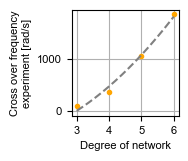

In [211]:



fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)


ax1.errorbar(m_list,G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")




def model_s(x, a, b):
    return a*np.array(x)**2 +b
x1=m_list
y1=G_cf_exp_list
params, _ = curve_fit(model_s, x1,y1,p0=[1,1],maxfev = 20000)

# Extract fitted parameters
a, b = params
print(f"Fitted parameters: a={a}, b={b}")


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
#print("prediction:",model_s(2*10**-4, *params))

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")


#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks([3,4,5,6],[3,4,5,6],fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency\nexperiment [rad/s]",fontname = "Arial",fontsize=fs1)
plt.xlabel("Degree of network",fontname = "Arial",fontsize=fs1)
plt.grid()


Fitted parameters: a=480.2053224633591, b=-62.38213465070147
R-squared: 0.9969417321761711
RMSE: 37.7968265390799


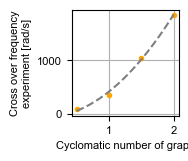

In [219]:



fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)


ax1.errorbar(cyclo_frac_theo_L,G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")




def model_s(x, a, b):
    return a*np.array(x)**2 +b
x1=cyclo_frac_theo_L
y1=G_cf_exp_list
params, _ = curve_fit(model_s, x1,y1,p0=[1,1],maxfev = 20000)

# Extract fitted parameters
a, b = params
print(f"Fitted parameters: a={a}, b={b}")


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
#print("prediction:",model_s(2*10**-4, *params))

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")


#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency\nexperiment [rad/s]",fontname = "Arial",fontsize=fs1)
plt.xlabel("Cyclomatic number of graph",fontname = "Arial",fontsize=fs1)
plt.grid()


Fitted parameters: a=172.52953618074918, b=-239.7758420471749
R-squared: 0.9923760839053294
RMSE: 59.6769520488018


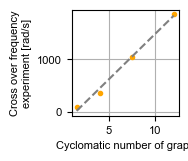

In [220]:



fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)


ax1.errorbar(np.array(cyclo_frac_theo_L)*np.array(m_list),G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")




def model_s(x, a, b):
    return a*np.array(x) +b
x1=np.array(cyclo_frac_theo_L)*np.array(m_list)
y1=G_cf_exp_list
params, _ = curve_fit(model_s, x1,y1,p0=[1,1],maxfev = 20000)

# Extract fitted parameters
a, b = params
print(f"Fitted parameters: a={a}, b={b}")


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
#print("prediction:",model_s(2*10**-4, *params))

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")


#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency\nexperiment [rad/s]",fontname = "Arial",fontsize=fs1)
plt.xlabel("Cyclomatic number of graph",fontname = "Arial",fontsize=fs1)
plt.grid()


Fitted parameters: a=1496.9349984737737, b=-1158.4369997920874
R-squared: 0.9981276811971265
RMSE: 26.468185331114366


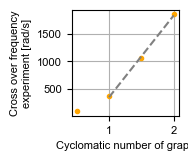

In [221]:



fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)


ax1.errorbar(np.array(cyclo_frac_theo_L),G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")




def model_s(x, a, b):
    return a*np.array(x) +b
x1=np.array(cyclo_frac_theo_L)[1:]
y1=G_cf_exp_list[1:]
params, _ = curve_fit(model_s, x1,y1,p0=[1,1],maxfev = 20000)

# Extract fitted parameters
a, b = params
print(f"Fitted parameters: a={a}, b={b}")


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
#print("prediction:",model_s(2*10**-4, *params))

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")


#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency\nexperiment [rad/s]",fontname = "Arial",fontsize=fs1)
plt.xlabel("Cyclomatic number of graph",fontname = "Arial",fontsize=fs1)
plt.grid()


Fitted parameters: a=0.0023734148622253926, b=-142.88307744080524
R-squared: 0.9862628280321479
RMSE: 80.10622152371171


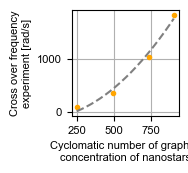

In [229]:



fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)


ax1.errorbar(np.array(cyclo_frac_theo_L)*c_conc_exp,G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")




def model_s(x, a, b):
    return a*np.array(x)**2 +b
x1=np.array(cyclo_frac_theo_L)*c_conc_exp
y1=G_cf_exp_list
params, _ = curve_fit(model_s, x1,y1,p0=[1,1],maxfev = 20000)

# Extract fitted parameters
a, b = params
print(f"Fitted parameters: a={a}, b={b}")


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
#print("prediction:",model_s(2*10**-4, *params))

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")


#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Cross over frequency\nexperiment [rad/s]",fontname = "Arial",fontsize=fs1)
plt.xlabel("Cyclomatic number of graph * \nconcentration of nanostars",fontname = "Arial",fontsize=fs1)
plt.grid()


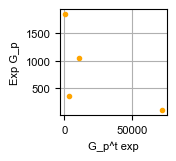

In [238]:



fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)


ax1.errorbar(scaling_c_conc_exp,G_cf_exp_list,color="orange",linewidth=0.7,fmt=".")



'''
def model_s(x, a, b):
    return a*np.array(x)**2 +b
x1=scaling_c_conc_exp
y1=G_cf_exp_list
params, _ = curve_fit(model_s, x1,y1,p0=[1,1],maxfev = 20000)

# Extract fitted parameters
a, b = params
print(f"Fitted parameters: a={a}, b={b}")


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
#print("prediction:",model_s(2*10**-4, *params))

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")

'''
#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Exp G_p",fontname = "Arial",fontsize=fs1)
plt.xlabel("G_p^t exp",fontname = "Arial",fontsize=fs1)
plt.grid()


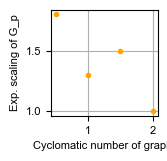

In [236]:





fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)


ax1.errorbar(cyclo_frac_theo_L,scaling_exp,color="orange",linewidth=0.7,fmt=".")



'''
def model_s(x, a, b):
    return a*np.array(x)**2 +b
x1=scaling_c_conc_exp
y1=G_cf_exp_list
params, _ = curve_fit(model_s, x1,y1,p0=[1,1],maxfev = 20000)

# Extract fitted parameters
a, b = params
print(f"Fitted parameters: a={a}, b={b}")


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
#print("prediction:",model_s(2*10**-4, *params))

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")

'''
#plt.xscale("log")
#plt.yscale("log")


fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
plt.ylabel("Exp. scaling of G_p",fontname = "Arial",fontsize=fs1)
plt.xlabel("Cyclomatic number of graph ",fontname = "Arial",fontsize=fs1)
plt.grid()


In [62]:


df_conrad_suppl_cf = pd.DataFrame([
    # f = 3
    [3, 195, 0.009, 0.30, 39.5],
    [3, 305, 0.015, 0.47, 85.6],
    [3, 390, 0.019, 0.61, 127],
    [3, 500, 0.024, 0.77, 215],
    [3, 590, 0.029, 0.92, 301],
    [3, 705, 0.034, 1.09, 388],
    [3, 810, 0.039, 1.25, 492],

    # f = 4
    [4, 295, 0.019, 0.46, 590],
    [4, 400, 0.026, 0.62, 915],
    [4, 495, 0.032, 0.77, 1240],
    [4, 630, 0.041, 0.98, 1460],
    [4, 740, 0.048, 1.14, 1980],

    # f = 5
    [5, 290, 0.023, 0.45, 996],
    [5, 330, 0.027, 0.51, 1370],
    [5, 355, 0.029, 0.55, 1380],
    [5, 355, 0.029, 0.55, 1400],
    [5, 445, 0.036, 0.69, 1940],
    [5, 450, 0.036, 0.70, 2140],
    [5, 465, 0.037, 0.72, 2185],
    [5, 485, 0.039, 0.75, 2140],
    [5, 550, 0.044, 0.85, 2630],
    [5, 550, 0.044, 0.85, 2800],
    [5, 590, 0.048, 0.91, 2820],
    [5, 600, 0.048, 0.92, 2870],

    # f = 6
    [6, 350, 0.034, 0.55, 4620],
    [6, 450, 0.044, 0.70, 5810],
    [6, 560, 0.054, 0.87, 7450],
], columns=[
    "f",
    "DNAns_uM",
    "phi_rods",
    "phi_sphere",
    "Gp0_Pa"
])

power_map = {
    3: 1.8,
    4: 1.3,
    5: 1.5,
    6: 1
}

df_conrad_suppl_cf["f_power_n"] = df_conrad_suppl_cf.apply(
    lambda row: row["f"] ** power_map[row["f"]],
    axis=1
)

df_conrad_suppl_cf["c_power_n"] = df_conrad_suppl_cf.apply(
    lambda row: row["DNAns_uM"] ** power_map[row["f"]],
    axis=1
)
'''N = df_conrad_suppl_cf["DNAns_uM"].to_numpy()
for k in range(len(N)):
    if df_conrad_suppl_cf["f"].to_numpy()[i] % 2:  # odd
        N[i] += N[i] % 2

p = N * df_conrad_suppl_cf["f"].to_numpy() / 2

cycl_nn=cyclomatic_number(generate_rd_graph_laplacian3(N=N,m=df_conrad_suppl_cf["f"].to_numpy(),p=p),normalize=False)

df_conrad_suppl_cf["cycl_nn"]=cycl_nn'''

'''df_conrad_suppl_cf["cycl_nn"] = df_conrad_suppl_cf.apply(
    lambda row:  cyclomatic_number(generate_rd_graph_laplacian3(N=row["DNAns_uM"], m=row["f"], p=int(row["DNAns_uM"]*row["f"]/2), rs=1),normalize=False),
    axis=1
)'''

def corrected_N(row): #for fully connected graph of odd m, N needs to be even, thus the concentration ~node count has to be slightly adjusted for th cyclomatic number calculation
    N = int(row["DNAns_uM"])
    m = int(row["f"])

    if m % 2 == 1 and N % 2 == 1:
        N += 1  # move to next even number

    return N

df_conrad_suppl_cf["cycl_nn"] = df_conrad_suppl_cf.apply(
    lambda row: cyclomatic_number(
        generate_rd_graph_laplacian3(
            N := int(corrected_N(row)),
            m=int(row["f"]),
            p=int(N * row["f"] / 2),
            rs=1,
        ),
        normalize=False,
    ),
    axis=1,
)


print(df_conrad_suppl_cf)

    f  DNAns_uM  phi_rods  phi_sphere  Gp0_Pa  f_power_n      c_power_n  \
0   3       195     0.009        0.30    39.5   7.224674   13245.315284   
1   3       305     0.015        0.47    85.6   7.224674   29630.549859   
2   3       390     0.019        0.61   127.0   7.224674   46122.866726   
3   3       500     0.024        0.77   215.0   7.224674   72134.995295   
4   3       590     0.029        0.92   301.0   7.224674   97170.317318   
5   3       705     0.034        1.09   388.0   7.224674  133887.616615   
6   3       810     0.039        1.25   492.0   7.224674  171898.874820   
7   4       295     0.019        0.46   590.0   6.062866    1624.682942   
8   4       400     0.026        0.62   915.0   6.062866    2413.670535   
9   4       495     0.032        0.77  1240.0   6.062866    3184.100439   
10  4       630     0.041        0.98  1460.0   6.062866    4356.550115   
11  4       740     0.048        1.14  1980.0   6.062866    5370.333243   
12  5       290     0.023

In [268]:
print(cyclomatic_number(
        generate_rd_graph_laplacian3(
            N := int(560),
            m=int(6),
            p=int(560*6 / 2),
            rs=1,),normalize=False))

1121


In [64]:
f_conrad_suppl = df_conrad_suppl_cf["f"].to_numpy()
conc_conrad_suppl = df_conrad_suppl_cf["DNAns_uM"].to_numpy()
Gp_conrad_suppl=df_conrad_suppl_cf["Gp0_Pa"].to_numpy()


f_power_n_conrad_suppl=df_conrad_suppl_cf["f_power_n"].to_numpy()

c_power_n_conrad_suppl=df_conrad_suppl_cf["c_power_n"].to_numpy()

cycl_nn_conrad_suppl=df_conrad_suppl_cf["cycl_nn"].to_numpy()



n = 1.585 +/- 0.042
a = 5.757e-03
R^2 = 0.9825
n = 1.483 +/- 0.007
a = 1.328e-02
b = -2.397e+01
R^2 = 0.9698
AIC (pure power law): -137.77
AIC (with offset):    -139.54


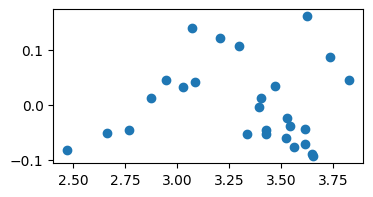

<Figure size 600x600 with 0 Axes>

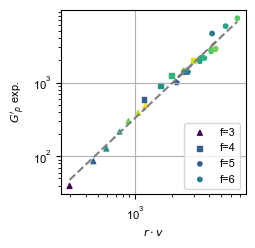

In [238]:

x = df_conrad_suppl_cf["cycl_nn"].to_numpy()*df_conrad_suppl_cf["f"]   # your combined variable
y = df_conrad_suppl_cf["Gp0_Pa"].to_numpy()                           # plateau modulus

log_x = np.log10(x)
log_y = np.log10(y)

slope, intercept, rvalue, pvalue, stderr_slope = scipy.stats.linregress(log_x, log_y)

n_fit = slope
a_fit = 10**intercept

print(f"n = {n_fit:.3f} +/- {stderr_slope:.3f}")
print(f"a = {a_fit:.3e}")
print(f"R^2 = {rvalue**2:.4f}")

residuals = log_y - (slope*log_x + intercept)
# plot residuals vs log_x — should look like flat, structureless scatter
fig = plt.figure(figsize=(4,2))
plt.scatter(log_x,residuals)
# any bowl/hump shape means the pure power law is missing something (e.g. real offset, or wrong functional form)


def log_model_s(x, a, n, b):
    return np.log10(a * x**n + b)

popt, pcov = curve_fit(
    log_model_s, x, log_y,
    p0=[a_fit, n_fit, 0],   # seed with the pure power-law fit
    maxfev=10000
)
a_opt, n_opt, b_opt = popt
perr = np.sqrt(np.diag(pcov))   # 1-sigma parameter uncertainties

y_pred_log = log_model_s(x, *popt)
ss_res = np.sum((log_y - y_pred_log)**2)
ss_tot = np.sum((log_y - np.mean(log_y))**2)
r2_offset = 1 - ss_res/ss_tot

print(f"n = {n_opt:.3f} +/- {perr[0]:.3f}")
print(f"a = {a_opt:.3e}")
print(f"b = {b_opt:.3e}")
print(f"R^2 = {r2_offset**2:.4f}")

def aic(residuals_log, k):
    n = len(residuals_log)
    rss = np.sum(residuals_log**2)
    return n*np.log(rss/n) + 2*k

aic_power  = aic(residuals, 2)             # a, n
aic_offset = aic(log_y - y_pred_log, 3)    # a, n, b

print(f"AIC (pure power law): {aic_power:.2f}")
print(f"AIC (with offset):    {aic_offset:.2f}")


#fig = plt.figure(figsize=(3.5/2.54, 3.5/2.54))
fig = plt.figure(figsize=(6,6))
fig=plt.figure(figsize=(9*0.75/2.54  ,9*0.75/2.54 ))


ax1 = fig.add_subplot(111)

# marker for each valence
marker_dict = {
    3: "^",   # triangle
    4: "s",   # square
    5: "p",   # pentagon
    6: "h"    # hexagon
}

# color normalization based on concentration
norm = colors.LogNorm(
    vmin=df_conrad_suppl_cf["DNAns_uM"].min(),
    vmax=df_conrad_suppl_cf["DNAns_uM"].max()
)

cmap = cm.viridis

for f, group in df_conrad_suppl_cf.groupby("f"):
    sc = ax1.scatter(
        group["cycl_nn"] *group["f"],
        group["Gp0_Pa"],  # replace with actual column name
        c=group["DNAns_uM"],
        cmap=cmap,
        norm=norm,
        marker=marker_dict.get(f, "o"),
        s=12,
        label=f"f={f}"
    )

plt.errorbar(x,a_fit*x**n_fit,color="grey",fmt="--")

ax1.set_xscale("log")
ax1.set_yscale("log")

fs1 = 8

#fig.colorbar(sc,location='right',shrink=0.5).set_label(label="DNAns concentration (µM)",size=fs1,family="Arial")

# Create colorbar
#cbar = fig.colorbar(sc, location="right", shrink=1)
#cbar.set_label(label="DNAns concentration (µM)", size=fs1, family="Arial")


ax1.set_xlabel(r"$r \cdot v$", fontsize=fs1, fontname="Arial")
ax1.set_ylabel(r"$G'_p$ exp.", fontsize=fs1, fontname="Arial")

plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)

ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
ax1.grid(True)


plt.tight_layout()
ax1.set_aspect(1./ax1.get_data_ratio())
#plt.show()


save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/fit_G_p_scaling1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

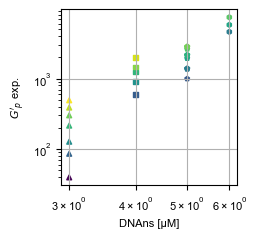

In [259]:
fig=plt.figure(figsize=(9*0.75/2.54  ,9*0.75/2.54 ))


ax1 = fig.add_subplot(111)

# marker for each valence
marker_dict = {
    3: "^",   # triangle
    4: "s",   # square
    5: "p",   # pentagon
    6: "h"    # hexagon
}

# color normalization based on concentration
norm = colors.LogNorm(
    vmin=df_conrad_suppl_cf["DNAns_uM"].min(),
    vmax=df_conrad_suppl_cf["DNAns_uM"].max()
)

cmap = cm.viridis


for f, group in df_conrad_suppl_cf.groupby("f"):
    sc = ax1.scatter(
        group["f"], #group["f"] #group["DNAns_uM"] #group["DNAns_uM"]*group["f"]
        group["Gp0_Pa"],  # replace with actual column name
        c=group["DNAns_uM"],
        cmap=cmap,
        norm=norm,
        marker=marker_dict.get(f, "o"),
        s=12,
        label=f"f={f}"
    )


ax1.set_xscale("log")
ax1.set_yscale("log")

fs1 = 8

#fig.colorbar(sc,location='right',shrink=0.5).set_label(label="DNAns concentration (µM)",size=fs1,family="Arial")

# Create colorbar
#cbar = fig.colorbar(sc, location="right", shrink=1)
#cbar.set_label(label="DNAns concentration (µM)", size=fs1, family="Arial")


ax1.set_xlabel(r"$v$", fontsize=fs1, fontname="Arial")
ax1.set_xlabel("DNAns [μM]", fontsize=fs1, fontname="Arial")

ax1.set_ylabel(r"$G'_p$ exp.", fontsize=fs1, fontname="Arial")

#plt.xticks([200,400,600,800],[200,400,600,800],fontname = "Arial",fontsize=fs1)
plt.xticks([3,4,5,6],fontname = "Arial",fontsize=fs1)

plt.yticks(fontname = "Arial",fontsize=fs1)

#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
ax1.grid(True)


plt.tight_layout()
ax1.set_aspect(1./ax1.get_data_ratio())
#plt.show()


save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/v_G_p_scaling1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

# Compare graph based precitions to YLS nanostar system used in Can et al


This system uses trivalent nanostars connected by bivalent linkers. This suggest that the graph structure is essentially connected nodes of degree 3.
The number corresponds to the lenght of the sticky end on the bivalent linker. YLS12: full 12 bp hybridisation, YLS6,: 6bp hybridise and 6 nt are not hybridised on the Y-motif sticky end.

https://onlinelibrary.wiley.com/doi/full/10.1002/marc.202500149

Also studied with CG simulations and stress autocorrelation in this preprint:

https://arxiv.org/abs/2605.29967

https://zenodo.org/records/20552843



In [3]:
# load in the data from the record

import pandas as pd
import re

# File path
file_path ="/mnt/d/D_phd/shojib_et_al_preprint_data/CG_paper_figures/CG_paper_figures/Figure_5/FIG8.txt"

# Dictionary to store all dataframes
datasets = {}

current_header = None
current_data = []

# Column names
cols = ["angular_frequency", "G_prime", "G_double_prime"]

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        # Skip empty lines
        if not line:
            continue

        # Detect headline like YLS12:
        if re.match(r"^[A-Za-z0-9]+:$", line):

            # Save previous block
            if current_header and current_data:
                df = pd.DataFrame(current_data, columns=cols)
                datasets[current_header] = df

            # Start new block
            current_header = line[:-1]  # remove ":"
            current_data = []

        # Skip repeated column name row
        elif line.startswith("angular frequency"):
            continue

        else:
            # Split by tab
            values = line.split("\t")

            # Replace comma decimal separators
            values = [v.replace(",", ".") for v in values]

            # Convert to float
            values = list(map(float, values))

            current_data.append(values)

# Save last dataset
if current_header and current_data:
    df = pd.DataFrame(current_data, columns=cols)
    datasets[current_header] = df

# Example 
print(datasets["YLS12"].head())
print()
print(datasets["YLS11"].head())
print()
print(datasets["YLS10"].head())

   angular_frequency  G_prime  G_double_prime
0              100.0    356.0            16.2
1               79.4    356.0            14.1
2               63.1    355.0            13.4
3               50.1    352.0            13.8
4               39.8    352.0            13.4

   angular_frequency  G_prime  G_double_prime
0              100.0    169.0            17.9
1               79.4    163.0            15.9
2               63.1    160.0            15.5
3               50.1    156.0            15.3
4               39.8    152.0            15.8

   angular_frequency  G_prime  G_double_prime
0              100.0    197.0            21.5
1               79.4    191.0            20.3
2               63.1    187.0            19.9
3               50.1    183.0            20.2
4               39.8    178.0            21.3


In [4]:
#for interpolation and cross over, new python functions that are more reliable were needed

from scipy.interpolate import interp1d
from scipy.optimize import brentq

def find_intersection2(x1, y1, x2, y2):
    """
    Find intersection points of two curves.

    Returns
    -------
    intersections : list of tuples
        [(x_intersection, y_intersection), ...]
    """

    # Convert to numpy arrays
    x1 = np.asarray(x1)
    y1 = np.asarray(y1)
    x2 = np.asarray(x2)
    y2 = np.asarray(y2)

    # Create interpolation functions
    f1 = interp1d(x1, y1, kind='linear', fill_value="extrapolate")
    f2 = interp1d(x2, y2, kind='linear', fill_value="extrapolate")

    # Common x-range
    xmin = max(x1.min(), x2.min())
    xmax = min(x1.max(), x2.max())

    # Dense grid for detecting crossings
    x_dense = np.linspace(xmin, xmax, 10000)

    y_diff = f1(x_dense) - f2(x_dense)

    # Find sign changes
    sign_changes = np.where(np.diff(np.sign(y_diff)) != 0)[0]

    intersections = []

    for idx in sign_changes:

        xa = x_dense[idx]
        xb = x_dense[idx + 1]

        # Root finder
        root = brentq(lambda x: f1(x) - f2(x), xa, xb)

        y_intersection = f1(root)

        intersections.append((root, y_intersection))

    return intersections


#use lo(G(log(omega))) for interpolation, in log space curves are better approximated with linear interpolation
def find_intersection2_loglog(x1, y1, x2, y2):

    x1 = np.asarray(x1)
    y1 = np.asarray(y1)
    x2 = np.asarray(x2)
    y2 = np.asarray(y2)

    # Convert to log space
    lx1 = np.log10(x1)
    ly1 = np.log10(y1)

    lx2 = np.log10(x2)
    ly2 = np.log10(y2)

    # Interpolation in log-log space
    f1 = interp1d(lx1, ly1, kind='linear', fill_value="extrapolate")
    f2 = interp1d(lx2, ly2, kind='linear', fill_value="extrapolate")

    # Common domain
    xmin = max(lx1.min(), lx2.min())
    xmax = min(lx1.max(), lx2.max())

    x_dense = np.linspace(xmin, xmax, 10000)

    diff = f1(x_dense) - f2(x_dense)

    sign_changes = np.where(np.diff(np.sign(diff)) != 0)[0]

    intersections = []

    for idx in sign_changes:

        xa = x_dense[idx]
        xb = x_dense[idx + 1]

        root = brentq(lambda x: f1(x) - f2(x), xa, xb)

        # Convert back from log space
        omega = 10**root
        G = 10**f1(root)

        intersections.append((omega, G))

    return intersections


Intersection exp dataset 1: omega: 0.1792478195602109 dynamic mod. 45.71203618019958
Intersection sim dataset 1: omega: 0.44964142718283573 dynamic mod. 36.64967629951236
Intersection exp dataset 1: omega: 0.1792478195602109 dynamic mod. 45.71203618019958
Intersection sim dataset 1: omega: 1.0596864042103837 dynamic mod. 60.09313805824566
Intersection exp dataset 1: omega: 0.1792478195602109 dynamic mod. 45.71203618019958
Intersection sim dataset 1: omega: 1.2748947952630767 dynamic mod. 129.10309990378454
Intersection exp dataset 1: omega: 0.1792478195602109 dynamic mod. 45.71203618019958
Intersection sim dataset 1: omega: 1.4197426972200244 dynamic mod. 146.0960515127463


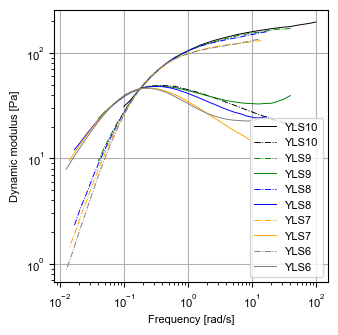

In [6]:
fig=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig.add_subplot(111)

freq_list_exp=[]
G_storage_list_exp=[]
G_loss_list_exp=[]

selected_keys = ["YLS10","YLS9","YLS8","YLS7","YLS6"]

for key in datasets:
    df = datasets[key]

    frequency = df["angular_frequency"]
    storage_mod = df["G_prime"]
    loss_mod = df["G_double_prime"]

    if key in selected_keys:
        freq_list_exp.append(frequency)
        G_storage_list_exp.append(storage_mod)
        G_loss_list_exp.append(loss_mod)


colors_exp_list=["black","green","blue","orange","grey"]
colors_exp_list2=["black","green","blue","orange","grey"]
label_exp_list=["YLS10","YLS9","YLS8","YLS7","YLS6"]

ax1.errorbar(freq_list_exp[0][::],G_storage_list_exp[0][::],fmt="-",label="YLS10",color="black",linewidth=0.7)
ax1.errorbar(freq_list_exp[0][::],G_loss_list_exp[0][::],fmt="-.",label="YLS10",color="black",linewidth=0.7)


for i in range(len(freq_list_exp[1:])):
    i=i+1

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection2_loglog(x1=freq_list_exp[0], y1=G_storage_list_exp[0], x2=freq_list_exp[0], y2=G_loss_list_exp[0])[0]
    print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection2_loglog(x1=freq_list_exp[i], y1=G_storage_list_exp[i], x2=freq_list_exp[i], y2=G_loss_list_exp[i])[0]
    print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    freq_list_exp_shift=np.array(freq_list_exp[i])*omega_inters_target_1/omega_inters_1
    G_storage_list_exp_shift=np.array(G_storage_list_exp[i])*dyn_mod_inters_target_1/dyn_mod_inters_1
    G_loss_list_exp_shift=np.array(G_loss_list_exp[i])*dyn_mod_inters_target_1/dyn_mod_inters_1

    ax1.errorbar(freq_list_exp_shift[::],G_storage_list_exp_shift[::],fmt="-.",label=label_exp_list[i],color=colors_exp_list[i],linewidth=0.7)
    ax1.errorbar(freq_list_exp_shift[::],G_loss_list_exp_shift[::],fmt="-",label=label_exp_list[i],color=colors_exp_list2[i],linewidth=0.7)


fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**0,1500)
#plt.xlim(10**-2,10**4)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

1200.0
960.0
1600.0
1280.0
[1.  0.8 1.  0.8]
CPU times: user 22.3 s, sys: 23.4 s, total: 45.7 s
Wall time: 5.68 s


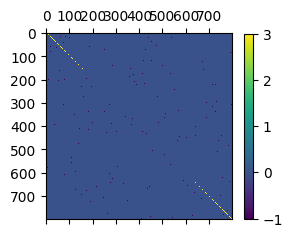

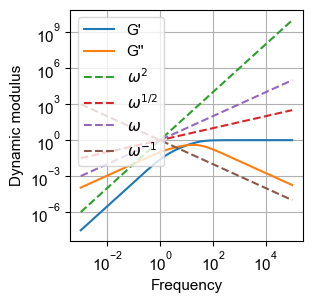

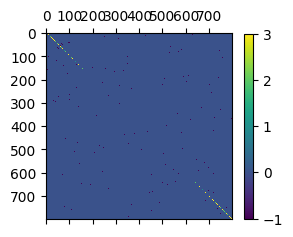

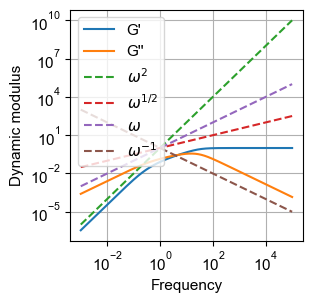

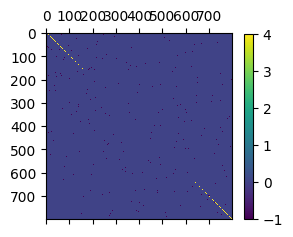

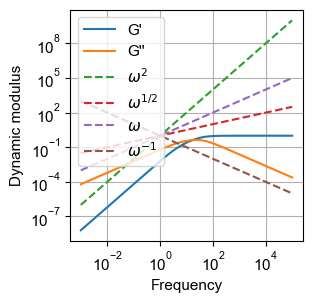

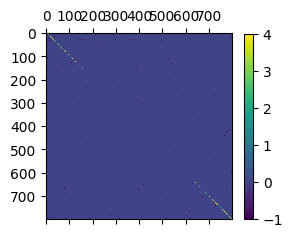

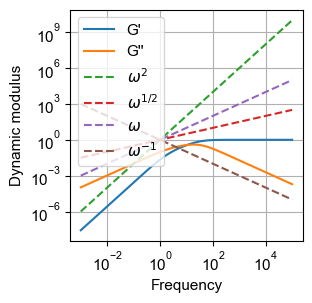

In [7]:
%%time
#generate theoretical graphs with matching valency and option to define max and min relax time
omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)
#number of nodes
num_nodes_list=[800,800,800,800]  #[800,800,800,800] #[100,100,100,100] #
#degree of each node
m_list=[3,3,4,4] #[3,4,5,6] 
#number of edges to add

p_list=[1200,960,1600,1280] #[1200,1600,2000,2400]  #[150,200,250,300]   #
#random seed
rs_list=[1,1,1,1]

storage_mod_list_rd, loss_mod_list_rd, relaxation_mod_list_rd,relax_times_list_rd=theo_graph_gen(num_nodes_list,m_list,p_list,rs_list,omega_t_sim1,t_sim1,lim_to_one_relax_time=None,lower_t_lim=0,upper_t_lim=9999)#0.2

fraction_bonded_theo=np.array(p_list /(np.array(num_nodes_list)*np.array(m_list) *0.5) )
print(fraction_bonded_theo)

In [10]:
#single relaxation time

storage_mod_r1=storage_mod(phi=1,k=1,T=1,N=1,b=1,tau=np.array([1]),omega=omega_t_sim1)
loss_mod_r1=loss_mod_deref(phi=1,k=1,T=1,N=1,b=1,tau=np.array([1]),omega=omega_t_sim1)

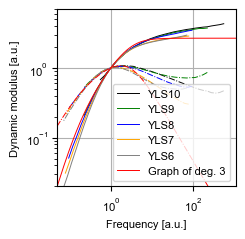

In [54]:
fig=plt.figure(figsize=(9/2.54 *0.65,9/2.54 *0.65))

ax1 = fig.add_subplot(111)

freq_list_exp=[]
G_storage_list_exp=[]
G_loss_list_exp=[]

selected_keys = ["YLS10","YLS9","YLS8","YLS7","YLS6"]

for key in datasets:
    df = datasets[key]

    frequency = df["angular_frequency"]
    storage_mod = df["G_prime"]
    loss_mod = df["G_double_prime"]

    if key in selected_keys:
        freq_list_exp.append(frequency)
        G_storage_list_exp.append(storage_mod)
        G_loss_list_exp.append(loss_mod)


colors_exp_list=["black","green","blue","orange","grey"]
colors_exp_list2=["black","green","blue","orange","grey"]
label_exp_list=["YLS10","YLS9","YLS8","YLS7","YLS6"]

#ax1.errorbar(freq_list_exp[0][::],G_storage_list_exp[0][::],fmt="-",label="YLS10",color="black",linewidth=0.7)
#ax1.errorbar(freq_list_exp[0][::],G_loss_list_exp[0][::],fmt="-.",color="black",linewidth=0.7)


for i in range(len(freq_list_exp[:])):
    #i=i+1

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection2_loglog(x1=freq_list_exp[0], y1=G_storage_list_exp[0], x2=freq_list_exp[0], y2=G_loss_list_exp[0])[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection2_loglog(x1=freq_list_exp[i], y1=G_storage_list_exp[i], x2=freq_list_exp[i], y2=G_loss_list_exp[i])[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    freq_list_exp_shift=np.array(freq_list_exp[i])/omega_inters_1
    G_storage_list_exp_shift=np.array(G_storage_list_exp[i])/dyn_mod_inters_1
    G_loss_list_exp_shift=np.array(G_loss_list_exp[i])/dyn_mod_inters_1

    ax1.errorbar(freq_list_exp_shift[::],G_storage_list_exp_shift[::],fmt="-",label=label_exp_list[i],color=colors_exp_list[i],linewidth=0.7)
    ax1.errorbar(freq_list_exp_shift[::],G_loss_list_exp_shift[::],fmt="-.",color=colors_exp_list2[i],linewidth=0.7)

#add graph prediction curve
storage_mod_list_rd_sel=storage_mod_list_rd[0]
loss_mod_list_rd_sel=loss_mod_list_rd[0]
omega_inters_1,dyn_mod_inters_1=find_intersection2_loglog(x1=omega_t_sim1, y1=storage_mod_list_rd_sel, x2=omega_t_sim1, y2=loss_mod_list_rd_sel)[0]
#print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)
freq_list_exp_shift=np.array(omega_t_sim1)/omega_inters_1
G_storage_list_exp_shift=np.array(storage_mod_list_rd_sel)/dyn_mod_inters_1
G_loss_list_exp_shift=np.array(loss_mod_list_rd_sel)/dyn_mod_inters_1

ax1.errorbar(freq_list_exp_shift[::],G_storage_list_exp_shift[::],fmt="-",label="Graph of deg. 3",color="red",linewidth=0.7)
ax1.errorbar(freq_list_exp_shift[::],G_loss_list_exp_shift[::],fmt="-.",color="red",linewidth=0.7)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(2*10**-2,7)
plt.xlim(0.5*10**-1,1.1*10**3)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/YLS_system_full_comp_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

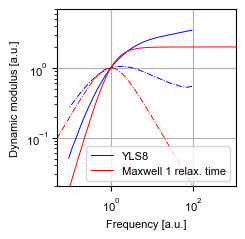

In [51]:
fig=plt.figure(figsize=(9/2.54*0.65,9/2.54*0.65))
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))

ax1 = fig.add_subplot(111)

freq_list_exp=[]
G_storage_list_exp=[]
G_loss_list_exp=[]

selected_keys = ["YLS10","YLS9","YLS8","YLS7","YLS6"]

for key in datasets:
    df = datasets[key]

    frequency = df["angular_frequency"]
    storage_mod = df["G_prime"]
    loss_mod = df["G_double_prime"]

    if key in selected_keys:
        freq_list_exp.append(frequency)
        G_storage_list_exp.append(storage_mod)
        G_loss_list_exp.append(loss_mod)


colors_exp_list=["black","green","blue","orange","grey"]
colors_exp_list2=["black","green","blue","orange","grey"]
label_exp_list=["YLS10","YLS9","YLS8","YLS7","YLS6"]

#ax1.errorbar(freq_list_exp[0][::],G_storage_list_exp[0][::],fmt="-",label="YLS10",color="black",linewidth=0.7)
#ax1.errorbar(freq_list_exp[0][::],G_loss_list_exp[0][::],fmt="-.",color="black",linewidth=0.7)


for i in [2]:
    #i=i+1

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection2_loglog(x1=freq_list_exp[0], y1=G_storage_list_exp[0], x2=freq_list_exp[0], y2=G_loss_list_exp[0])[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection2_loglog(x1=freq_list_exp[i], y1=G_storage_list_exp[i], x2=freq_list_exp[i], y2=G_loss_list_exp[i])[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    freq_list_exp_shift=np.array(freq_list_exp[i])/omega_inters_1
    G_storage_list_exp_shift=np.array(G_storage_list_exp[i])/dyn_mod_inters_1
    G_loss_list_exp_shift=np.array(G_loss_list_exp[i])/dyn_mod_inters_1

    ax1.errorbar(freq_list_exp_shift[::],G_storage_list_exp_shift[::],fmt="-",label=label_exp_list[i],color=colors_exp_list[i],linewidth=0.7)
    ax1.errorbar(freq_list_exp_shift[::],G_loss_list_exp_shift[::],fmt="-.",color=colors_exp_list2[i],linewidth=0.7)

#add graph prediction curve
storage_mod_list_rd_sel=storage_mod_r1#[0]
loss_mod_list_rd_sel=loss_mod_r1#[0]
omega_inters_1,dyn_mod_inters_1=find_intersection2_loglog(x1=omega_t_sim1, y1=storage_mod_list_rd_sel, x2=omega_t_sim1, y2=loss_mod_list_rd_sel)[0]
#print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)
freq_list_exp_shift=np.array(omega_t_sim1)/omega_inters_1
G_storage_list_exp_shift=np.array(storage_mod_list_rd_sel)/dyn_mod_inters_1
G_loss_list_exp_shift=np.array(loss_mod_list_rd_sel)/dyn_mod_inters_1

ax1.errorbar(freq_list_exp_shift[::],G_storage_list_exp_shift[::],fmt="-",label="Maxwell 1 relax. time",color="red",linewidth=0.7)
ax1.errorbar(freq_list_exp_shift[::],G_loss_list_exp_shift[::],fmt="-.",color="red",linewidth=0.7)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(2*10**-2,7)
plt.xlim(0.5*10**-1,1.1*10**3)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/YLS_system_8_1rt_comp_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

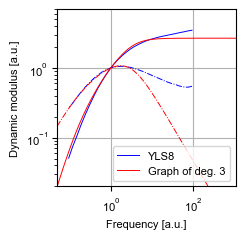

In [52]:
fig=plt.figure(figsize=(9/2.54*0.65,9/2.54*0.65))
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))

ax1 = fig.add_subplot(111)

freq_list_exp=[]
G_storage_list_exp=[]
G_loss_list_exp=[]

selected_keys = ["YLS10","YLS9","YLS8","YLS7","YLS6"]

for key in datasets:
    df = datasets[key]

    frequency = df["angular_frequency"]
    storage_mod = df["G_prime"]
    loss_mod = df["G_double_prime"]

    if key in selected_keys:
        freq_list_exp.append(frequency)
        G_storage_list_exp.append(storage_mod)
        G_loss_list_exp.append(loss_mod)


colors_exp_list=["black","green","blue","orange","grey"]
colors_exp_list2=["black","green","blue","orange","grey"]
label_exp_list=["YLS10","YLS9","YLS8","YLS7","YLS6"]

#ax1.errorbar(freq_list_exp[0][::],G_storage_list_exp[0][::],fmt="-",label="YLS10",color="black",linewidth=0.7)
#ax1.errorbar(freq_list_exp[0][::],G_loss_list_exp[0][::],fmt="-.",color="black",linewidth=0.7)


for i in [2]:
    #i=i+1

    #intersection for rescaling for matching cross over point
    omega_inters_target_1,dyn_mod_inters_target_1=find_intersection2_loglog(x1=freq_list_exp[0], y1=G_storage_list_exp[0], x2=freq_list_exp[0], y2=G_loss_list_exp[0])[0]
    #print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)
        
    omega_inters_1,dyn_mod_inters_1=find_intersection2_loglog(x1=freq_list_exp[i], y1=G_storage_list_exp[i], x2=freq_list_exp[i], y2=G_loss_list_exp[i])[0]
    #print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

    
    
    freq_list_exp_shift=np.array(freq_list_exp[i])/omega_inters_1
    G_storage_list_exp_shift=np.array(G_storage_list_exp[i])/dyn_mod_inters_1
    G_loss_list_exp_shift=np.array(G_loss_list_exp[i])/dyn_mod_inters_1

    ax1.errorbar(freq_list_exp_shift[::],G_storage_list_exp_shift[::],fmt="-",label=label_exp_list[i],color=colors_exp_list[i],linewidth=0.7)
    ax1.errorbar(freq_list_exp_shift[::],G_loss_list_exp_shift[::],fmt="-.",color=colors_exp_list2[i],linewidth=0.7)

#add graph prediction curve
storage_mod_list_rd_sel=storage_mod_list_rd[0]
loss_mod_list_rd_sel=loss_mod_list_rd[0]
omega_inters_1,dyn_mod_inters_1=find_intersection2_loglog(x1=omega_t_sim1, y1=storage_mod_list_rd_sel, x2=omega_t_sim1, y2=loss_mod_list_rd_sel)[0]
#print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)
freq_list_exp_shift=np.array(omega_t_sim1)/omega_inters_1
G_storage_list_exp_shift=np.array(storage_mod_list_rd_sel)/dyn_mod_inters_1
G_loss_list_exp_shift=np.array(loss_mod_list_rd_sel)/dyn_mod_inters_1

ax1.errorbar(freq_list_exp_shift[::],G_storage_list_exp_shift[::],fmt="-",label="Graph of deg. 3",color="red",linewidth=0.7)
ax1.errorbar(freq_list_exp_shift[::],G_loss_list_exp_shift[::],fmt="-.",color="red",linewidth=0.7)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(2*10**-2,7)
plt.xlim(0.5*10**-1,1.1*10**3)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/YLS_system_8_g3_comp_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

# Generate theoretical graphs of networked materials with increasing connectivtiy

In [74]:
#graphs with max node degree 99 and increasing number of edges
omega_t_len_s=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_len_s=np.geomspace(10**-2,10**3,10**3)

f_intersection_list,f_max_loss_mod_list,len_f_range_list, storage_mod_list,loss_mod_list,rd_elem,relax_times_list=rd_inters_max4(num_samples=1000,nodes=100,n_elem_max=200,n_elem_min=25,max_edges_per_node=99,omega_test=omega_t_len_s,t_test=t_len_s)

In [75]:
#graphs with max node degree 4 and increasing number of edges
f_intersection_list2,f_max_loss_mod_list2,len_f_range_list2, storage_mod_list2,loss_mod_list2,rd_elem2,relax_times_list2=rd_inters_max4(num_samples=1000,nodes=100,n_elem_max=200,n_elem_min=25,max_edges_per_node=4,omega_test=omega_t_len_s,t_test=t_len_s)

In [76]:
#mean moduli from simulations for comparison
mean_storage_mod_all_sims_all=[np.mean(e,axis=0) for e in storage_mod_all_sims_all]
mean_loss_mod_all_sims_all=[np.mean(e,axis=0) for e in loss_mod_all_sims_all]
mean_cross_links_all_sims_all=[np.mean(e,axis=0) for e in cross_links_all_sims_all]
stde_cross_links_all_sims_all=[np.std(e,axis=0)/np.sqrt(len(cross_links_all_sims_all)) for e in cross_links_all_sims_all]

In [80]:
# intersection G' and G'' and other quantifiers from simulations
f_intersection_ex_all=[]
f_max_loss_mod_ex_all=[]
len_f_range_ex_all=[]
for i in range(len(mean_storage_mod_all_sims_all)):
    
    f_intersection_ex1,f_max_loss_mod_ex1,len_f_range_ex1=rd_inters_max_examples2(storage_mod=mean_storage_mod_all_sims_all[i],loss_mod=mean_loss_mod_all_sims_all[i],omega_test=omega_t_len_s,t_test=t_len_s)
    f_intersection_ex_all.append(f_intersection_ex1)
    f_max_loss_mod_ex_all.append(f_max_loss_mod_ex1)
    len_f_range_ex_all.append(len_f_range_ex1)

#get parameters for each sim repeat
f_intersection_ex_indv=[]
f_max_loss_mod_ex_indv=[]
len_f_range_ex_indv=[]
for i in range(len(storage_mod_all_sims_all)):
    f_intersection_ex_indv_e=[]
    f_max_loss_mod_ex_indv_e=[]
    len_f_range_ex_indv_e=[]
    for j in range(len(storage_mod_all_sims_all[i])):
    
        f_intersection_ex1,f_max_loss_mod_ex1,len_f_range_ex1=rd_inters_max_examples2(storage_mod=storage_mod_all_sims_all[i][j],loss_mod=loss_mod_all_sims_all[i][j],omega_test=omega_t_len_s,t_test=t_len_s)
        f_intersection_ex_indv_e.append(f_intersection_ex1)
        f_max_loss_mod_ex_indv_e.append(f_max_loss_mod_ex1)
        len_f_range_ex_indv_e.append(len_f_range_ex1)
    f_intersection_ex_indv.append(f_intersection_ex_indv_e)
    f_max_loss_mod_ex_indv.append(f_max_loss_mod_ex_indv_e)
    len_f_range_ex_indv.append(len_f_range_ex_indv_e)

In [81]:
f_intersection_2_exp,f_max_loss_mod_2_exp,len_char_region_2_exp=rd_inters_max_examples2(storage_mod=G_storage_exp,loss_mod=G_loss_exp,omega_test=freq,t_test=t_len_s)
print(f_intersection_2_exp,f_max_loss_mod_2_exp)

f_intersection_2_exp_rs=f_intersection_2_exp*omega_inters_1/omega_inters_target_1
f_max_loss_mod_2_exp_rs=f_max_loss_mod_2_exp*omega_inters_1/omega_inters_target_1
print(f_intersection_2_exp_rs,f_max_loss_mod_2_exp_rs)

3.30506 3.5539
15.856913514930753 17.050790285414607


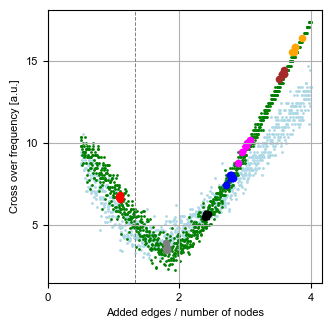

In [82]:
fig1=plt.figure(figsize=(9/2.54,9/2.54))
#fig1=plt.figure(figsize=(9/2.54 *0.4,3.5/2.54 *0.4))
#fig1=plt.figure(figsize=(3.5/2.54 ,3.5/2.54 ))
#fig1=plt.figure(figsize=(9/2.54 ,3.5/2.54 ))

ax1 = fig1.add_subplot(111)
#for i in range(len(loss_factors_list)):

#ax1.errorbar(rd_elem,len_f_range_list/(f_intersection_list),fmt=".")
#ax1.errorbar(rd_elem,f_intersection_list/f_max_loss_mod_list,fmt=".")

#ax1.errorbar(rd_elem,f_max_loss_mod_list,fmt=".",label="max loss mod")
x_scale_1=100/2
ax1.scatter(rd_elem/x_scale_1,f_intersection_list,label="Max. degree=99",alpha=1, color="lightblue",s=1)

ax1.scatter(rd_elem2/x_scale_1,f_intersection_list2,label="Max. degree=4",alpha=1, color="green",s=1)


colors_l=["red","grey","black","blue","magenta","brown","orange","pink","purple","yellow"]
marker_types=["+", "o", "s", "^", "v", "D", "*","x","p","+"]

for i in range(len(cross_links_all_sims_all)):
    ax1.scatter(np.array(cross_links_all_sims_all[i])/x_scale_1,f_intersection_ex_indv[i],label="Indv. sims",alpha=1,s=20,color=colors_l[i])

#ax1.hlines(f_intersection_2_exp_rs,25/x_scale_1,250/x_scale_1 ,linewidth=0.7,linestyle=":")
#ax1.errorbar(rd_elem_t1,f_intersection_t1,fmt="x", color="blue")

for i in range(len(mean_cross_links_all_sims_all)):
    ax1.scatter(mean_cross_links_all_sims_all[i]/x_scale_1,f_intersection_ex_all[i],s=20,marker=marker_types[i],color=colors_l[i],label="Simulation "+str(i+1) )
    
#ax1.errorbar(mean_cross_links_all_sims_ex1,f_intersection_ex1,fmt=".")
#ax1.errorbar(mean_cross_links_all_sims_ex2,f_intersection_ex2,fmt=".")
#ax1.errorbar(mean_cross_links_all_sims_ex3,f_intersection_ex3,fmt=".")
#ax1.errorbar(mean_cross_links_all_sims_ex4,f_intersection_ex4,fmt=".")


plt.axvline(1/3 *200 /x_scale_1,color="grey",linestyle="--",linewidth=0.7)
#plt.xlim(0,200)
#plt.ylim(0,20)

fs1=8
#plt.xscale("log")
#plt.yscale("log")
plt.grid()
'''plt.xlim(0,4)
plt.ylim(0,20)
plt.xticks([0,2,4],fontname = "Arial",fontsize=fs1)
plt.yticks([0,10,20],fontname = "Arial",fontsize=fs1)'''
plt.xticks([0,2,4],fontname = "Arial",fontsize=fs1)
plt.yticks([5,10,15],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Cross over frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Added edges / number of nodes",fontname = "Arial",fontsize=fs1)
#ax1.legend(loc="upper left",prop={'family': 'Arial','size': fs1})


save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/cross_over_freq_added_edges_2.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

Fitted parameters: a=0.9000194569917905,b=1.3810472145076644
R-squared: 0.960999324965409
RMSE: 0.533086329946258
R-squared, y=x+1: 0.9489530831390195
RMSE, y=x+1: 0.9537011695321469
R-squared, y=x+1, max. nodes=4: 0.9865001946514798
RMSE, y=x+1, max. nodes=4: 1.2163879303976683


/home/aaron/miniconda3/envs/bayesian_opt_1/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/aaron/miniconda3/envs/bayesian_opt_1/lib/python3.9/site-packages/matplotlib/collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Text(0, 0.5, 'Crossover frequency [a.u.]')

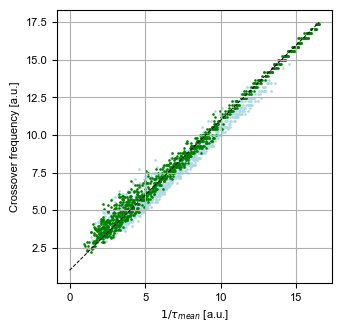

In [84]:
fig1=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig1.add_subplot(111)

#colors_l=["red","black","darkblue","blue","magenta","brown","orange"]
#for i in range(len(relax_times_list[::20])):
#    num_modes_1=np.arange(0,len(relax_times_list[::20][i]))
#    ax1.scatter(num_modes_1,relax_times_list[::20][i],s=10,marker="^",label=i)


'''for i in range(len(relax_times_list[::])):
    #num_modes_1=np.arange(0,len(relax_times_list[::][i]))
    ax1.scatter(rd_elem[i]/x_scale_1,1/np.mean(relax_times_list[::][i]),s=1,marker="p",label=i,color="lightblue")

for i in range(len(relax_times_list[::])):
    #num_modes_1=np.arange(0,len(relax_times_list[::][i]))
    ax1.scatter(rd_elem2[i]/x_scale_1,1/np.mean(relax_times_list2[::][i]),s=1,marker="p",label=i,color="green")
'''
relax_times_list2_mean=np.array([np.mean(relax_times_list2[e]) for e in range(len(relax_times_list2))])
relax_times_list_mean=np.array([np.mean(relax_times_list[e]) for e in range(len(relax_times_list))])

inv_relax_times_list2_mean=np.array([np.mean(1/relax_times_list2[e]) for e in range(len(relax_times_list2))])
inv_relax_times_list_mean=np.array([np.mean(1/relax_times_list[e]) for e in range(len(relax_times_list))])

#ax1.scatter(rd_elem/x_scale_1,1/relax_times_list_mean,s=1,marker="p",label=i,color="lightblue")
#ax1.scatter(rd_elem2/x_scale_1,1/relax_times_list2_mean,s=1,marker="p",label=i,color="green")


def model3(x, a, b):
    return a * x +b



# Fit the curve

x1_t=1/relax_times_list_mean
x1=np.array([x.real if isinstance(x, complex) else x for x in x1_t])

y1_t=f_intersection_list
y1=np.array([x.real if isinstance(x, complex) else x for x in y1_t])

#max nodes =4

x2_t=1/relax_times_list2_mean
x2=np.array([x.real if isinstance(x, complex) else x for x in x2_t])

y2_t=f_intersection_list2
y2=np.array([x.real if isinstance(x, complex) else x for x in y2_t])
#y1=y1_t[np.isreal(y1_t)]

params, _ = curve_fit(model3, x1,y1,p0=[1,0])

# Extract fitted parameters
a, b = params
print(f"Fitted parameters: a={a},b={b}")

#plt.errorbar(x1,model3(x1,*params),color="grey",fmt="--")

#plt.errorbar(rd_elem,19000*rd_elem**-0.66 )

# Predict y values using the fitted model
y_pred = model3(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")


# Calculate goodness-of-fit quantifiers
r_squared2 = r2_score(x1, y1-1)
rmse2 = np.sqrt(mean_squared_error(x1,y1))

print(f"R-squared, y=x+1: {r_squared2}")
print(f"RMSE, y=x+1: {rmse2}")


# Calculate goodness-of-fit quantifiers
r_squared3 = r2_score(x2, y2-1)
rmse3 = np.sqrt(mean_squared_error(x2,y2))

print(f"R-squared, y=x+1, max. nodes=4: {r_squared3}")
print(f"RMSE, y=x+1, max. nodes=4: {rmse3}")

lin_1=np.linspace(0,np.max([np.max(x1),np.max(x2)]))

plt.errorbar(lin_1,lin_1+1,color="black",fmt="--",linewidth=0.7)


ax1.scatter(1/relax_times_list_mean,f_intersection_list,s=1,marker="p",label=i,color="lightblue")
ax1.scatter(1/relax_times_list2_mean,f_intersection_list2,s=1,marker="p",label=i,color="green")


#ax1.scatter(inv_relax_times_list_mean,f_intersection_list,s=1,marker="p",label=i,color="lightblue")
#ax1.scatter(inv_relax_times_list2_mean,f_intersection_list2,s=1,marker="p",label=i,color="green")



fs1=8
#plt.xscale("log")
#plt.yscale("log")
plt.grid()
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
ax1.set_xlabel(r"$1/\tau_{mean}$ [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Crossover frequency [a.u.]",fontname = "Arial",fontsize=fs1)
#ax1.legend(loc="upper left",prop={'family': 'Arial','size': fs1})

0 25.0


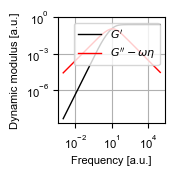

1 42.51751751751752


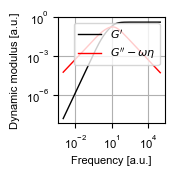

2 60.03503503503504


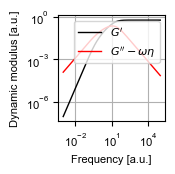

3 77.55255255255256


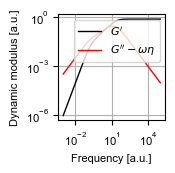

4 95.07007007007007


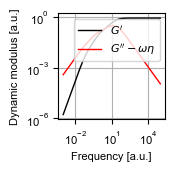

5 112.58758758758758


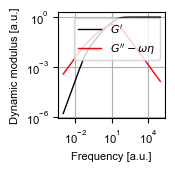

6 130.1051051051051


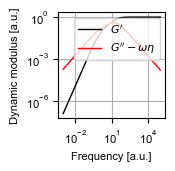

7 147.6226226226226


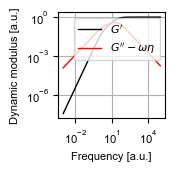

8 165.14014014014015


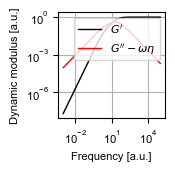

9 182.65765765765767


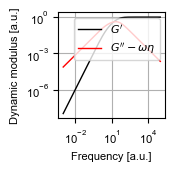

In [88]:

#for i in range(len(loss_factors_list)):
start1=0
step1=100
stop1=-1
for i in range(len(storage_mod_list2[start1:stop1:step1])):
    print(i,rd_elem2[start1:stop1:step1][i])
    fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig1.add_subplot(111)
    
    ax1.errorbar(omega_t_len_s,storage_mod_list2[start1:stop1:step1][i],fmt="-",label=r"$G'$",color="black",linewidth=1)
    ax1.errorbar(omega_t_len_s,loss_mod_list2[start1:stop1:step1][i],fmt="-",label=r"$G''-\omega \eta$",color="red",linewidth=1)
    
    #ax1.errorbar(omega_t_len_s2,storage_mod_list2[1],fmt="-",color="black",linewidth=1)
    #ax1.errorbar(omega_t_len_s2,loss_mod_list2[1],fmt="-",color="red",linewidth=1)
    
    
    fs1=8
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
    plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
    ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
    if i ==59:
        save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/moduli_from_rd_graphs_120_edges_1.pdf"

        #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
     
    plt.show()